In [1]:
import json
import os
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import requests
from shapely.geometry import shape

import pandas as pd



In [2]:
target_crs = 'EPSG:4326'

In [3]:
# AOI
gpd_aoi_file = '/Users/ryanmc/Documents/Complex_Risk_Science/dev/Complex-Risk-Collective/.github/Projects/NASA-disasters-grid-resilience/data/selected_states_MarchApril2023_event.geojson'
gdf_aoi = gpd.read_file(gpd_aoi_file)
gdf_aoi = gdf_aoi.to_crs(target_crs)

In [4]:
# Load the US County GeoJSON file
geojson_url = "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
geojson = json.loads(pd.read_json(geojson_url).to_json())
counties_gdf = gpd.read_file(geojson_url)


In [26]:
counties_gdf

,id,GEO_ID,STATE,COUNTY,NAME,LSAD,CENSUSAREA,geometry
0,01001,0500000US01001,01,001,Autauga,County,594.436,"POLYGON ((-86.49677 32.34444, -86.7179 32.4028..."
1,01009,0500000US01009,01,009,Blount,County,644.776,"POLYGON ((-86.5778 33.76532, -86.75914 33.8406..."
2,01017,0500000US01017,01,017,Chambers,County,596.531,"POLYGON ((-85.18413 32.87052, -85.12342 32.772..."
3,01021,0500000US01021,01,021,Chilton,County,692.854,"POLYGON ((-86.51734 33.02057, -86.51596 32.929..."
4,01033,0500000US01033,01,033,Colbert,County,592.619,"POLYGON ((-88.13999 34.5817, -88.13925 34.5878..."
...,...,...,...,...,...,...,...,...
3216,51001,0500000US51001,51,001,Accomack,County,449.496,"MULTIPOLYGON (((-75.24227 38.02721, -75.29687 ..."
3217,51021,0500000US51021,51,021,Bland,County,357.725,"POLYGON ((-81.2251 37.23487, -81.20477 37.2430..."
3218,51027,0500000US51027,51,027,Buchanan,County,502.763,"POLYGON ((-81.9683 37.5378, -81.92787 37.51212..."
3219,51037,0500000US51037,51,037,Charlotte,County,475.271,"POLYGON ((-78.44332 37.0794, -78.49303 36.8912..."


# Get power grid as our background network

In [5]:
file_path_powergrid = "/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/physical_grid_data/U.S._Electric_Power_Transmission_Lines.geojson"
gdf_powergrid = gpd.read_file(file_path_powergrid)
gdf_powergrid = gdf_powergrid.to_crs(target_crs)


# Convert timeframes to folium-friendly types
gdf_powergrid['SOURCEDATE'] = pd.to_datetime(gdf_powergrid['SOURCEDATE']).dt.strftime('%Y-%m-%dT%H:%M:%S')
gdf_powergrid['VAL_DATE'] = pd.to_datetime(gdf_powergrid['VAL_DATE']).dt.strftime('%Y-%m-%dT%H:%M:%S')


# Drop columns with 'NOT AVAILABLE' as substation value
# gdf[ (gdf['SUB_1']=='NOT AVAILABLE') | (gdf['SUB_2']=='NOT AVAILABLE')]
condition = ( (gdf_powergrid['SUB_1']=='NOT AVAILABLE') | (gdf_powergrid['SUB_2']=='NOT AVAILABLE') )
gdf_powergrid = gdf_powergrid[~condition]
# gdf

# Drop columns with 'NONE' as substation value
condition = ( (gdf_powergrid['SUB_1']=='NONE') | (gdf_powergrid['SUB_2']=='NONE') )
gdf_powergrid = gdf_powergrid[~condition]
gdf_powergrid



,FID,OBJECTID,ID,TYPE,STATUS,NAICS_CODE,NAICS_DESC,SOURCE,SOURCEDATE,VAL_METHOD,...,OWNER,VOLTAGE,VOLT_CLASS,INFERRED,SUB_1,SUB_2,SHAPE__Len,GlobalID,SHAPE_Length,geometry
0,1,501,135919,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, EIA 860",2014-08-04T00:00:00,IMAGERY,...,NOT AVAILABLE,69.0,UNDER 100,Y,UNKNOWN115865,TAP142941,29.188701,{73B386A9-AE19-4673-AE34-A87E1E490FE1},0.000227,"MULTILINESTRING ((-92.27198 30.22732, -92.2720..."
1,2,502,141425,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, EIA 861",2014-04-07T00:00:00,IMAGERY,...,ALABAMA POWER CO,115.0,100-161,Y,UNKNOWN109093,TAP142857,74.705018,{9EA82903-87B1-4BB6-84B5-9B372F739699},0.000583,"MULTILINESTRING ((-87.82312 30.60263, -87.8232..."
2,3,503,141426,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,IMAGERY,2014-07-15T00:00:00,IMAGERY,...,"DUKE ENERGY CAROLINAS, LLC",100.0,100-161,Y,UNKNOWN115051,TAP154872,70.223774,{6008C7EC-8421-487A-9CB1-22801412BEB7},0.000591,"MULTILINESTRING ((-81.85754 35.03416, -81.8580..."
3,4,504,141429,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, OpenStreetMap, http://www.oatioasis.c...",2014-07-08T00:00:00,IMAGERY,...,TENNESSEE VALLEY AUTHORITY,161.0,100-161,N,FORT PAYNE PRIMARY,TAP152965,12929.295887,{1678DB1B-7C05-4927-A0FA-7E9011CABC1A},0.109258,"MULTILINESTRING ((-85.68872 34.47813, -85.6893..."
4,5,505,141422,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, EIA 861, EIA 860",2015-05-28T00:00:00,IMAGERY,...,COMMONWEALTH EDISON CO,138.0,100-161,Y,UNKNOWN121903,TAP137923,1737.440378,{DE001834-13ED-4FE4-96CC-789BDF3B01F9},0.012158,"MULTILINESTRING ((-87.96213 42.03757, -87.9625..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93042,93043,93043,315082,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,Western Electricity Coordinating Council https...,2017-01-01T00:00:00,IMAGERY/OTHER,...,NOT AVAILABLE,230.0,220-287,N,TAP317033,LONE BUTTE,3437.236752,{99755F96-1FD1-403B-9A00-7351EF073AA3},0.025857,"MULTILINESTRING ((-111.99586 33.22352, -111.99..."
93043,93044,93044,315083,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, OpenStreetMap",2019-11-23T00:00:00,IMAGERY,...,"ENTERGY TEXAS, INC.",138.0,100-161,Y,TAP316626,TAP316629,3287.127256,{4DD4F2D4-470F-4C1F-9948-C28B485F733D},0.028136,"MULTILINESTRING ((-94.06849 30.05597, -94.0669..."
93044,93045,93045,315084,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, OpenStreetMap",2019-11-23T00:00:00,IMAGERY,...,"ENTERGY TEXAS, INC.",138.0,100-161,Y,TAP316627,TAP316630,103.168311,{1FFEACEF-46E0-49EA-9367-CBD918C10A35},0.000803,"MULTILINESTRING ((-94.0684 30.0545, -94.06846 ..."
93045,93046,93046,315085,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, OpenStreetMap",2019-11-23T00:00:00,IMAGERY,...,"ENTERGY TEXAS, INC.",138.0,100-161,Y,TAP316630,TAP316629,90.248211,{CDB30F46-7C14-47A6-A16F-E8ED2DC404F1},0.000707,"MULTILINESTRING ((-94.06846 30.0553, -94.06852..."


In [6]:
# Clip to ensure only grid elements in the AOI are kept
gdf_powergrid_aoi = gpd.sjoin(gdf_powergrid, gdf_aoi, how="inner", predicate='within').drop(columns=['index_right'])

# Whisker read and diagnostics

In [7]:
whisker_outages_file = '/Users/ryanmc/Documents/NASA_JPL/Projects/NaturalHazards/NASA ROSES Disasters 2025-2027/data/Whisker_Labs_Data_March2026/2023-03-26 to 2023-04-09 Event/PowerOutages.json'

try:
    # Open the file in read mode and load its contents
    with open(whisker_outages_file, 'r', encoding='utf-8') as file:
        whisker_outages = json.load(file)

    # Pretty-print the Python object (which is usually a dictionary or list)
    # to the console in valid JSON format
    print(json.dumps(whisker_outages, indent=4, sort_keys=True))
    
except FileNotFoundError:
    print(f"Error: The file '{whisker_outages_file}' was not found.")
except json.JSONDecodeError as e:
    print(f"Error: Failed to decode JSON from the file. Details: {e}")

[
    {
        "AverageAmplitude": 0.0,
        "Location": {
            "Latitude": 41.436,
            "Longitude": -81.822
        },
        "Sensors": 4,
        "StartTime": "2023-03-26T00:15:27.094+00:00",
        "StartTimeLocal": "2023-03-25T20:15:27.094-04:00",
        "Type": "PowerOutage"
    },
    {
        "AverageAmplitude": 0.0,
        "Location": {
            "Latitude": 41.444,
            "Longitude": -81.782
        },
        "Sensors": 16,
        "StartTime": "2023-03-26T00:15:31.9+00:00",
        "StartTimeLocal": "2023-03-25T20:15:31.9-04:00",
        "Type": "PowerOutage"
    },
    {
        "AverageAmplitude": 0.0,
        "Location": {
            "Latitude": 39.996,
            "Longitude": -80.695
        },
        "Sensors": 5,
        "StartTime": "2023-03-26T00:16:53.111+00:00",
        "StartTimeLocal": "2023-03-25T20:16:53.111-04:00",
        "Type": "PowerOutage"
    },
    {
        "AverageAmplitude": 0.0,
        "Location": {
            "

In [4]:
# # ...existing code...
# import pandas as pd
# import geopandas as gpd
# import plotly.graph_objects as go
# from datetime import datetime
# import json

# # --- Load AOI ---
# gdf_aoi = gpd.read_file(gpd_aoi_file)
# gdf_aoi = gdf_aoi.to_crs("EPSG:4326")
# print(f"AOI loaded: {len(gdf_aoi)} feature(s)")
# print(f"AOI CRS: {gdf_aoi.crs}")

# # --- Load outages ---
# with open(outages_file, 'r', encoding='utf-8') as f:
#     outages_raw = json.load(f)

# # Ensure it's a list
# if isinstance(outages_raw, dict) and "features" in outages_raw:
#     outages_list = outages_raw["features"]
# elif isinstance(outages_raw, list):
#     outages_list = outages_raw
# else:
#     raise ValueError("Unexpected outages file structure")

# print(f"Loaded {len(outages_list)} outage records")

# # --- Parse outages into DataFrame ---
# records = []
# for item in outages_list:
#     try:
#         lat = item["Location"]["Latitude"]
#         lon = item["Location"]["Longitude"]
#         start_time = pd.to_datetime(item["StartTime"], errors="coerce")
#         sensors = item.get("Sensors", 0)
#         amplitude = item.get("AverageAmplitude", 0.0)
        
#         if pd.notna(start_time):
#             records.append({
#                 "latitude": lat,
#                 "longitude": lon,
#                 "datetime": start_time,
#                 "sensors": sensors,
#                 "amplitude": amplitude,
#             })
#     except (KeyError, TypeError):
#         continue

# df_outages = pd.DataFrame(records)
# print(f"Parsed {len(df_outages)} valid outage records")
# print(f"Date range: {df_outages['datetime'].min()} to {df_outages['datetime'].max()}")

# # Convert to GeoDataFrame
# gdf_outages = gpd.GeoDataFrame(
#     df_outages,
#     geometry=gpd.points_from_xy(df_outages["longitude"], df_outages["latitude"]),
#     crs="EPSG:4326"
# )

# # Clip to AOI
# gdf_outages_aoi = gpd.sjoin(
#     gdf_outages,
#     gdf_aoi[["geometry"]],
#     how="inner",
#     predicate="within"
# ).drop(columns=["index_right"], errors="ignore")

# print(f"Outages within AOI: {len(gdf_outages_aoi)}")

# # --- Aggregate by date for slider frames ---
# df_outages_aoi = pd.DataFrame(gdf_outages_aoi.drop(columns="geometry"))
# df_outages_aoi["date"] = df_outages_aoi["datetime"].dt.date

# dates = sorted(df_outages_aoi["date"].unique())
# print(f"Unique dates: {len(dates)}")

# # --- Extract AOI boundary coords (fixed) ---
# aoi_boundary_coords = []
# for geom in gdf_aoi.geometry:
#     if geom.geom_type == "Polygon":
#         coords = list(geom.exterior.coords)
#     elif geom.geom_type == "MultiPolygon":
#         coords = []
#         for poly in geom.geoms:
#             coords.extend(list(poly.exterior.coords))
#     else:
#         coords = []
#     aoi_boundary_coords.extend(coords)

# # Extract lons and lats
# aoi_lons = [c[0] for c in aoi_boundary_coords]
# aoi_lats = [c[1] for c in aoi_boundary_coords]

# # --- Build animated Plotly figure ---
# frames = []
# sliders_dict = {
#     "active": 0,
#     "yanchor": "top",
#     "y": 0,
#     "xanchor": "left",
#     "x": 0.1,
#     "len": 0.8,
#     "transition": {"duration": 300},
#     "pad": {"b": 10, "t": 50},
#     "currentvalue": {
#         "prefix": "Date: ",
#         "visible": True,
#         "xanchor": "right",
#         "font": {"size": 14}
#     },
#     "steps": []
# }

# for i, date in enumerate(dates):
#     # Filter data for this date
#     day_data = df_outages_aoi[df_outages_aoi["date"] == date].copy()
    
#     # Create frame
#     frame = go.Frame(
#         data=[
#             go.Scattergeo(
#                 lon=day_data["longitude"],
#                 lat=day_data["latitude"],
#                 mode="markers",
#                 marker=dict(
#                     size=day_data["sensors"].clip(lower=3, upper=15),
#                     color=day_data["amplitude"],
#                     colorscale="Reds",
#                     showscale=(i == 0),
#                     colorbar=dict(title="Amplitude"),
#                     opacity=0.7,
#                     line=dict(width=0.5, color="darkred")
#                 ),
#                 text=[
#                     f"<b>Sensors:</b> {s}<br><b>Amplitude:</b> {a:.3f}<br><b>Time:</b> {t}"
#                     for s, a, t in zip(day_data["sensors"], day_data["amplitude"], day_data["datetime"])
#                 ],
#                 hoverinfo="text",
#                 name="Outages"
#             )
#         ],
#         name=str(date)
#     )
#     frames.append(frame)
    
#     # Add slider step
#     sliders_dict["steps"].append({
#         "args": [
#             [str(date)],
#             {
#                 "frame": {"duration": 300, "redraw": True},
#                 "mode": "immediate",
#                 "transition": {"duration": 300}
#             }
#         ],
#         "label": str(date),
#         "method": "animate"
#     })

# # --- Build initial figure (first frame) ---
# first_date = dates[0]
# first_data = df_outages_aoi[df_outages_aoi["date"] == first_date].copy()

# fig = go.Figure(
#     data=[
#         go.Scattergeo(
#             lon=first_data["longitude"],
#             lat=first_data["latitude"],
#             mode="markers",
#             marker=dict(
#                 size=first_data["sensors"].clip(lower=3, upper=15),
#                 color=first_data["amplitude"],
#                 colorscale="Reds",
#                 showscale=True,
#                 colorbar=dict(title="Amplitude"),
#                 opacity=0.7,
#                 line=dict(width=0.5, color="darkred")
#             ),
#             text=[
#                 f"<b>Sensors:</b> {s}<br><b>Amplitude:</b> {a:.3f}<br><b>Time:</b> {t}"
#                 for s, a, t in zip(first_data["sensors"], first_data["amplitude"], first_data["datetime"])
#             ],
#             hoverinfo="text",
#             name="Outages"
#         ),
#         go.Scattergeo(
#             lon=aoi_lons,
#             lat=aoi_lats,
#             mode="lines",
#             line=dict(color="black", width=2),
#             name="AOI boundary",
#             hoverinfo="skip"
#         )
#     ],
#     frames=frames,
# )

# fig.update_geos(
#     scope="usa",
#     projection_type="albers usa",
#     visible=True,
#     showcountries=True,
#     countrywidth=1,
#     countrycolor="#ccc"
# )

# fig.update_layout(
#     sliders=[sliders_dict],
#     title="Power Outages Over Time (Whisker Labs Data)",
#     height=700,
#     width=1200,
#     template="plotly_white",
#     hovermode="closest",
#     showlegend=True
# )

# fig.show()
# # ...existing code...

In [7]:
whisker_outages

[{'Type': 'PowerOutage',
  'StartTime': '2023-03-26T00:15:27.094+00:00',
  'StartTimeLocal': '2023-03-25T20:15:27.094-04:00',
  'Sensors': 4,
  'Location': {'Latitude': 41.436, 'Longitude': -81.822},
  'AverageAmplitude': 0.0},
 {'Type': 'PowerOutage',
  'StartTime': '2023-03-26T00:15:31.9+00:00',
  'StartTimeLocal': '2023-03-25T20:15:31.9-04:00',
  'Sensors': 16,
  'Location': {'Latitude': 41.444, 'Longitude': -81.782},
  'AverageAmplitude': 0.0},
 {'Type': 'PowerOutage',
  'StartTime': '2023-03-26T00:16:53.111+00:00',
  'StartTimeLocal': '2023-03-25T20:16:53.111-04:00',
  'Sensors': 5,
  'Location': {'Latitude': 39.996, 'Longitude': -80.695},
  'AverageAmplitude': 0.0},
 {'Type': 'PowerOutage',
  'StartTime': '2023-03-26T00:39:32.033+00:00',
  'StartTimeLocal': '2023-03-25T20:39:32.033-04:00',
  'Sensors': 4,
  'Location': {'Latitude': 41.429, 'Longitude': -81.375},
  'AverageAmplitude': 0.0},
 {'Type': 'PowerOutage',
  'StartTime': '2023-03-26T00:45:15.466+00:00',
  'StartTimeLocal'

In [17]:
df

,event_index,start_time,start_time_local_raw,end_time,latitude,longitude,sensors,average_amplitude,valid_coord,duration_minutes,start_time_local,date_local,hour_local
0,0,2023-03-26 00:15:27.094000+00:00,2023-03-25T20:15:27.094-04:00,NaT,41.436,-81.822,4,0.0,True,NaN,2023-03-25 17:15:27.094000-07:00,2023-03-25,17.0
1,1,2023-03-26 00:15:31.900000+00:00,2023-03-25T20:15:31.9-04:00,NaT,41.444,-81.782,16,0.0,True,NaN,2023-03-25 17:15:31.900000-07:00,2023-03-25,17.0
2,2,2023-03-26 00:16:53.111000+00:00,2023-03-25T20:16:53.111-04:00,NaT,39.996,-80.695,5,0.0,True,NaN,2023-03-25 17:16:53.111000-07:00,2023-03-25,17.0
3,3,2023-03-26 00:39:32.033000+00:00,2023-03-25T20:39:32.033-04:00,NaT,41.429,-81.375,4,0.0,True,NaN,2023-03-25 17:39:32.033000-07:00,2023-03-25,17.0
4,4,2023-03-26 00:45:15.466000+00:00,2023-03-25T20:45:15.466-04:00,NaT,41.457,-81.308,4,0.0,True,NaN,2023-03-25 17:45:15.466000-07:00,2023-03-25,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2042,2042,2023-04-09 18:35:03.540000+00:00,2023-04-09T13:35:03.54-05:00,NaT,36.097,-97.092,8,0.0,True,NaN,2023-04-09 11:35:03.540000-07:00,2023-04-09,11.0
2043,2043,2023-04-09 20:12:51.600000+00:00,2023-04-09T15:12:51.6-05:00,NaT,30.140,-95.432,6,0.0,True,NaN,2023-04-09 13:12:51.600000-07:00,2023-04-09,13.0
2044,2044,2023-04-09 21:09:56.072000+00:00,2023-04-09T16:09:56.072-05:00,NaT,29.713,-95.800,10,0.0,True,NaN,2023-04-09 14:09:56.072000-07:00,2023-04-09,14.0
2045,2045,2023-04-09 22:56:17.976000+00:00,2023-04-09T17:56:17.976-05:00,NaT,29.883,-98.694,5,0.0,True,NaN,2023-04-09 15:56:17.976000-07:00,2023-04-09,15.0


Whisker outage diagnostics summary


,metric,value
0,Raw outage records,2047
1,Valid coordinates,2047
2,Missing start_time,2
3,Missing end_time (expected for this feed),2047
4,Records with measurable duration,0
5,Missing sensors,0
6,Missing average_amplitude,0
7,"Duplicate (lat,lon,start_time)",0
8,Start time min (UTC),2023-03-26 00:15:27.094000+00:00
9,Start time max (UTC),2023-04-09 23:02:00.509000+00:00


Missingness by key field (%)


,field,missing_percent
2,end_time,100.000000
7,duration_minutes,100.000000
0,start_time,0.097704
1,start_time_local_raw,0.000000
3,latitude,0.000000
4,longitude,0.000000
5,sensors,0.000000
6,average_amplitude,0.000000


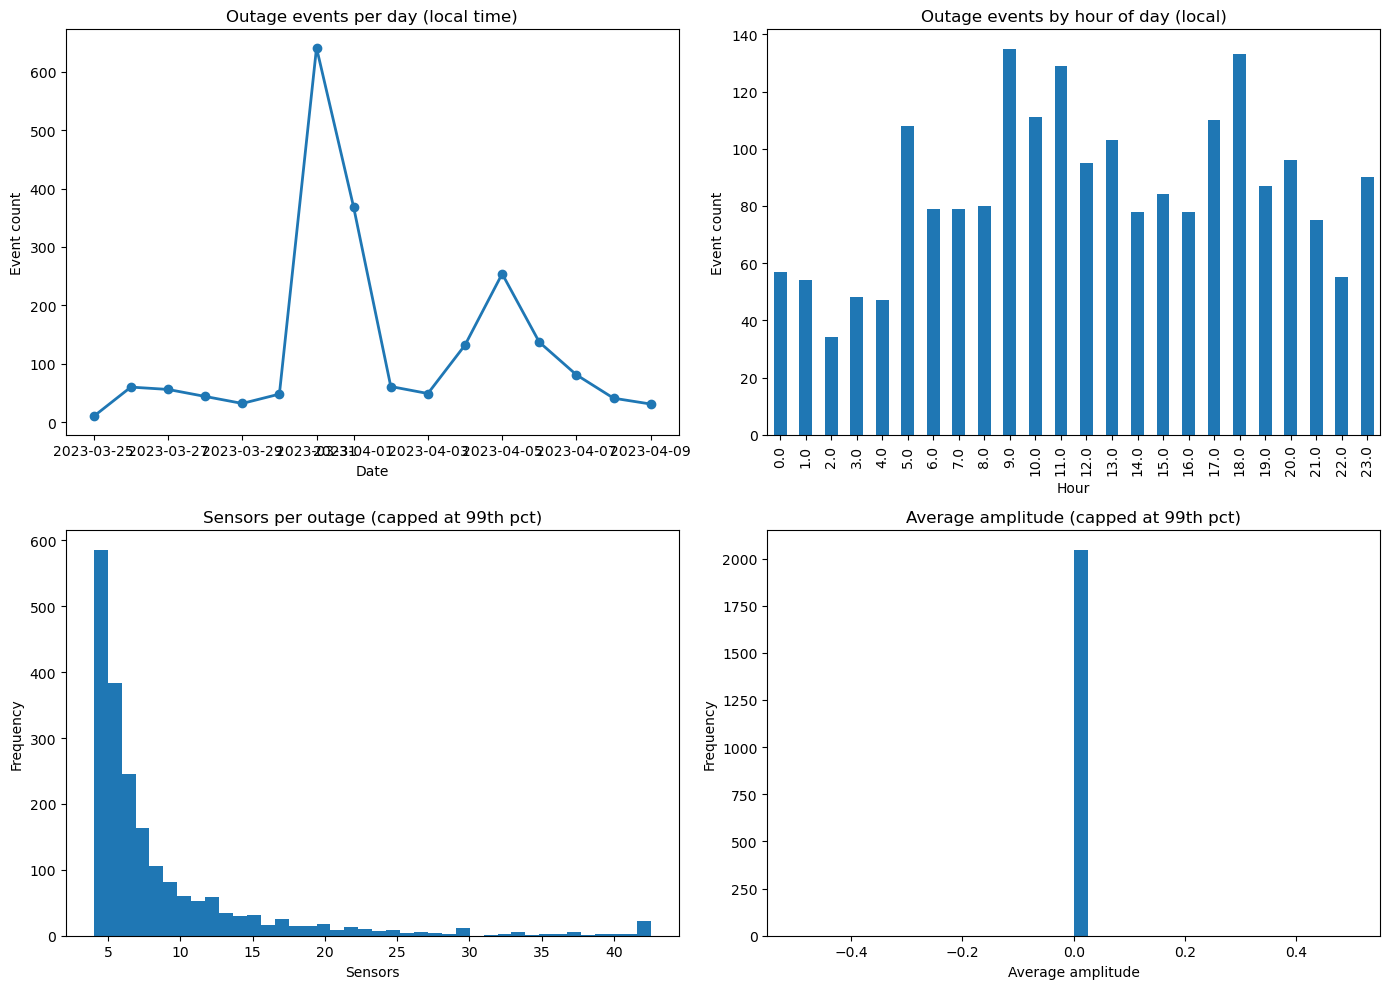

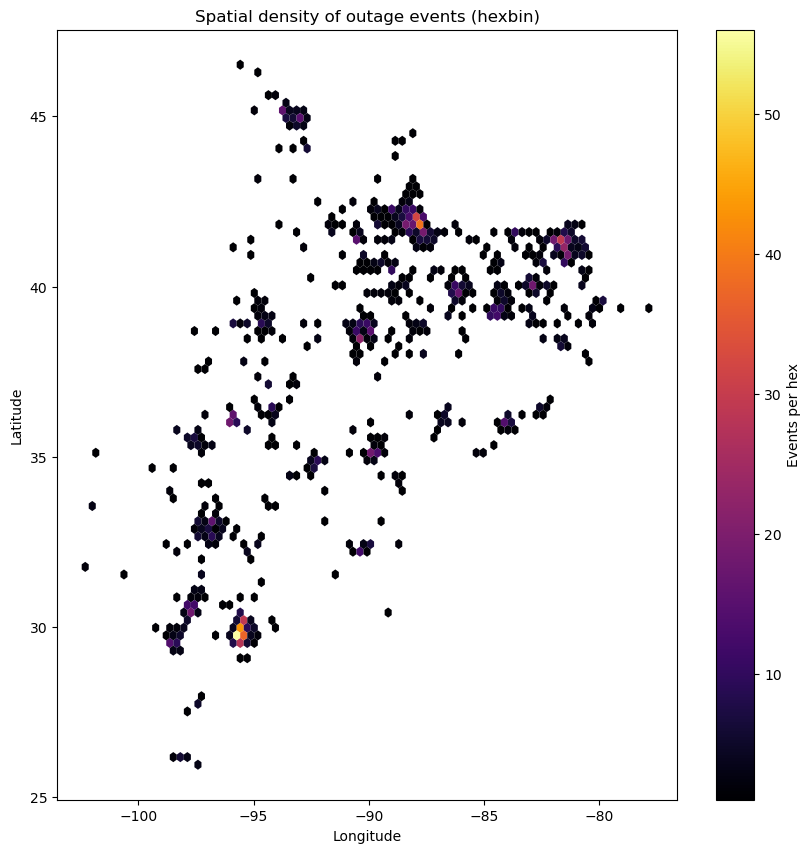

Outage events inside AOI: 2,047 / 2,047 valid-coordinate events
Top hotspot bins inside AOI (rounded to 0.1 degrees)


,lat_bin,lon_bin,event_count,outage_frequency,mean_sensors
58,29.8,-95.5,15,15,8.333333
55,29.8,-95.8,13,13,18.461538
994,45.2,-93.7,13,13,5.846154
799,41.5,-90.5,13,13,9.923077
27,29.5,-95.5,12,12,7.166667
852,41.7,-87.7,12,12,9.583333
59,29.8,-95.4,12,12,5.250000
85,30.1,-95.4,12,12,11.250000
75,30.0,-95.5,11,11,7.545455
791,41.4,-81.8,10,10,10.200000


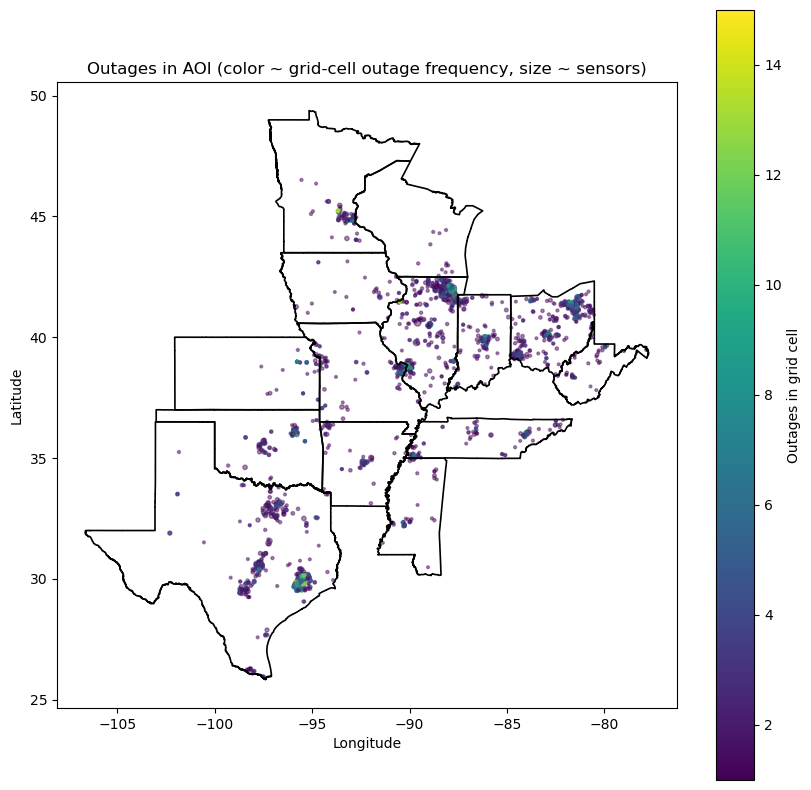

In [11]:
import numpy as np
from IPython.display import display

# Uses existing `whisker_outages` loaded earlier in the notebook.
if isinstance(whisker_outages, dict) and "features" in whisker_outages:
    outages_list = whisker_outages["features"]
elif isinstance(whisker_outages, list):
    outages_list = whisker_outages
else:
    raise ValueError("Unexpected whisker_outages structure; expected list or dict with 'features'.")


def _dig(item, path, default=np.nan):
    value = item
    for key in path:
        if isinstance(value, dict) and key in value:
            value = value[key]
        else:
            return default
    return value

records = []
for idx, item in enumerate(outages_list):
    loc = _dig(item, ["Location"], default={})
    records.append(
        {
            "event_index": idx,
            "start_time": item.get("StartTime"),
            "start_time_local_raw": item.get("StartTimeLocal"),
            "end_time": item.get("EndTime"),
            "latitude": pd.to_numeric(_dig(loc, ["Latitude"]), errors="coerce"),
            "longitude": pd.to_numeric(_dig(loc, ["Longitude"]), errors="coerce"),
            "sensors": pd.to_numeric(item.get("Sensors", item.get("SensorCount", item.get("Households", np.nan))), errors="coerce"),
            "average_amplitude": pd.to_numeric(item.get("AverageAmplitude", item.get("Amplitude", np.nan)), errors="coerce"),
        }
    )

df = pd.DataFrame(records)

# Parse time fields after DataFrame creation so dtype is consistent even when EndTime is absent.
df["start_time"] = pd.to_datetime(df["start_time"], errors="coerce", utc=True)
df["end_time"] = pd.to_datetime(df["end_time"], errors="coerce", utc=True)
start_time_local_raw_parsed = pd.to_datetime(df["start_time_local_raw"], errors="coerce", utc=True)

df["valid_coord"] = df["latitude"].between(-90, 90) & df["longitude"].between(-180, 180)

# EndTime is optional in this feed; only compute duration where both timestamps exist.
df["duration_minutes"] = np.nan
has_duration = df["start_time"].notna() & df["end_time"].notna()
df.loc[has_duration, "duration_minutes"] = (
    df.loc[has_duration, "end_time"] - df.loc[has_duration, "start_time"]
).dt.total_seconds() / 60.0

# Prefer provider local timestamp when available, normalized to a single timezone.
start_local_from_start = df["start_time"].dt.tz_convert("America/Los_Angeles")
start_local_from_raw = start_time_local_raw_parsed.dt.tz_convert("America/Los_Angeles")
df["start_time_local"] = start_local_from_start.where(start_local_from_raw.isna(), start_local_from_raw)

df["date_local"] = df["start_time_local"].dt.date
df["hour_local"] = df["start_time_local"].dt.hour

summary = pd.DataFrame(
    {
        "metric": [
            "Raw outage records",
            "Valid coordinates",
            "Missing start_time",
            "Missing end_time (expected for this feed)",
            "Records with measurable duration",
            "Missing sensors",
            "Missing average_amplitude",
            "Duplicate (lat,lon,start_time)",
            "Start time min (UTC)",
            "Start time max (UTC)",
            "Latitude range",
            "Longitude range",
        ],
        "value": [
            len(df),
            int(df["valid_coord"].sum()),
            int(df["start_time"].isna().sum()),
            int(df["end_time"].isna().sum()),
            int(has_duration.sum()),
            int(df["sensors"].isna().sum()),
            int(df["average_amplitude"].isna().sum()),
            int(df.duplicated(subset=["latitude", "longitude", "start_time"]).sum()),
            str(df["start_time"].min()),
            str(df["start_time"].max()),
            f"{df['latitude'].min():.4f} to {df['latitude'].max():.4f}",
            f"{df['longitude'].min():.4f} to {df['longitude'].max():.4f}",
        ],
    }
)

missing = (
    df[["start_time", "start_time_local_raw", "end_time", "latitude", "longitude", "sensors", "average_amplitude", "duration_minutes"]]
    .isna()
    .mean()
    .mul(100)
    .rename("missing_percent")
    .reset_index()
    .rename(columns={"index": "field"})
    .sort_values("missing_percent", ascending=False)
)

print("Whisker outage diagnostics summary")
display(summary)

print("Missingness by key field (%)")
display(missing)

valid = df[df["valid_coord"]].copy()
if len(valid) == 0:
    raise ValueError("No valid coordinates available for visualization.")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
valid["date_local"].value_counts().sort_index().plot(ax=axes[0, 0], marker="o", linewidth=2)
axes[0, 0].set_title("Outage events per day (local time)")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Event count")

valid["hour_local"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Outage events by hour of day (local)")
axes[0, 1].set_xlabel("Hour")
axes[0, 1].set_ylabel("Event count")

if valid["sensors"].notna().any():
    valid["sensors"].dropna().clip(upper=valid["sensors"].quantile(0.99)).plot(kind="hist", bins=40, ax=axes[1, 0])
axes[1, 0].set_title("Sensors per outage (capped at 99th pct)")
axes[1, 0].set_xlabel("Sensors")

if valid["average_amplitude"].notna().any():
    valid["average_amplitude"].dropna().clip(upper=valid["average_amplitude"].quantile(0.99)).plot(kind="hist", bins=40, ax=axes[1, 1])
axes[1, 1].set_title("Average amplitude (capped at 99th pct)")
axes[1, 1].set_xlabel("Average amplitude")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 10))
hb = ax.hexbin(valid["longitude"], valid["latitude"], gridsize=80, mincnt=1, cmap="inferno", linewidths=0)
fig.colorbar(hb, ax=ax, label="Events per hex")
ax.set_title("Spatial density of outage events (hexbin)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

# AOI overlays if geopandas + AOI file are available.
if "gpd" in globals() and "gpd_aoi_file" in globals():
    try:
        aoi = gpd.read_file(gpd_aoi_file).to_crs("EPSG:4326")
        gdf_points = gpd.GeoDataFrame(
            valid,
            geometry=gpd.points_from_xy(valid["longitude"], valid["latitude"]),
            crs="EPSG:4326",
        )
        points_in_aoi = gpd.sjoin(gdf_points, aoi[["geometry"]], predicate="within", how="inner")

        print(f"Outage events inside AOI: {len(points_in_aoi):,} / {len(valid):,} valid-coordinate events")

        # Grid resolution (degrees) for cell-frequency map.
        grid_res_deg = 0.1
        points_in_aoi["lat_bin"] = (points_in_aoi["latitude"] / grid_res_deg).round() * grid_res_deg
        points_in_aoi["lon_bin"] = (points_in_aoi["longitude"] / grid_res_deg).round() * grid_res_deg

        freq_by_cell = (
            points_in_aoi.groupby(["lat_bin", "lon_bin"], as_index=False)
            .size()
            .rename(columns={"size": "outage_frequency"})
        )

        points_in_aoi = points_in_aoi.merge(freq_by_cell, on=["lat_bin", "lon_bin"], how="left")

        hotspots = (
            points_in_aoi.groupby(["lat_bin", "lon_bin"], as_index=False)
            .agg(
                event_count=("event_index", "count"),
                outage_frequency=("outage_frequency", "max"),
                mean_sensors=("sensors", "mean"),
            )
            .sort_values("event_count", ascending=False)
            .head(20)
        )

        print("Top hotspot bins inside AOI (rounded to 0.1 degrees)")
        display(hotspots)

        fig, ax = plt.subplots(figsize=(10, 10))
        aoi.boundary.plot(ax=ax, linewidth=1.2, color="black")
        if len(points_in_aoi) > 0:
            marker_size = np.sqrt(points_in_aoi["sensors"].fillna(points_in_aoi["sensors"].median()).clip(lower=1)) * 2
            points_in_aoi.plot(
                ax=ax,
                markersize=marker_size,
                column="outage_frequency",
                cmap="viridis",
                alpha=0.45,
                legend=True,
                legend_kwds={"label": "Outages in grid cell"},
            )
        ax.set_title("Outages in AOI (color ~ grid-cell outage frequency, size ~ sensors)")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        plt.show()
    except Exception as e:
        print(f"AOI diagnostics skipped: {e}")
else:
    print("AOI diagnostics skipped (geopandas import or gpd_aoi_file is missing).")

# Now compare with Eagle-I to see what we can learn about the physical system impact

In [22]:
directory = '/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/outage_data/EAGLE-I/'
file = 'outage_data_2023.csv'

eaglei_data = pd.read_csv(os.path.join(directory,file))
eaglei_data.head()

eaglei_data['datetime'] = pd.to_datetime(eaglei_data['run_start_time'], errors='coerce')  # Handle any invalid dates

# Define start and end dates
start_date = '2023-03-26'
end_date = '2023-04-09'

# Filter rows that fall within the date range
eaglei_data = eaglei_data[(eaglei_data['datetime'] >= start_date) & (eaglei_data['datetime'] <= end_date)]




In [66]:
# Snapshot map helper
# Required objects expected in memory: counties_gdf, gdf_aoi, gdf_powergrid_aoi, eaglei_data, df

import numpy as np
import matplotlib.colors as mcolors


def _to_county_fips(frame, state_col="STATE", county_col="COUNTY"):
    out = frame.copy()
    out[state_col] = out[state_col].astype(str).str.zfill(2)
    out[county_col] = out[county_col].astype(str).str.zfill(3)
    out["county_fips"] = out[state_col] + out[county_col]
    return out


def plot_outage_snapshot(snapshot_datetime, whisker_tolerance="60min", figsize=(14, 10)):
    # 1) Normalize county/state geometry context
    counties = counties_gdf.to_crs("EPSG:4326").copy()
    counties = _to_county_fips(counties, state_col="STATE", county_col="COUNTY")

    # Exclude AK/HI/PR for a CONUS background.
    excluded_state_fips = {"02", "15", "72"}
    counties_conus = counties[~counties["STATE"].isin(excluded_state_fips)].copy()

    # AOI counties for county boundaries + Eagle-I shading.
    aoi_union = gdf_aoi.to_crs("EPSG:4326").union_all()
    counties_aoi = counties_conus[counties_conus.intersects(aoi_union)].copy()

    conus_states = counties_conus.dissolve(by="STATE", as_index=False)

    # 2) Parse and align snapshot time
    snapshot_utc = pd.to_datetime(snapshot_datetime, utc=True)

    # Eagle-I time selection: nearest available run_start_time
    eagle = eaglei_data.copy()
    eagle["run_start_time"] = pd.to_datetime(eagle["run_start_time"], errors="coerce", utc=True)
    eagle = eagle.dropna(subset=["run_start_time"])

    if eagle.empty:
        raise ValueError("No valid Eagle-I timestamps found in eaglei_data['run_start_time'].")

    eagle_unique = pd.Series(eagle["run_start_time"].dropna().unique()).sort_values().reset_index(drop=True)
    eagle_nearest = eagle_unique.iloc[(eagle_unique - snapshot_utc).abs().argmin()]
    eagle_at_time = eagle[eagle["run_start_time"] == eagle_nearest].copy()
    eagle_at_time["fips_code"] = eagle_at_time["fips_code"].astype(str).str.zfill(5)

    eagle_counties = counties_aoi.merge(
        eagle_at_time[["fips_code", "sum"]].rename(columns={"fips_code": "county_fips"}),
        on="county_fips",
        how="left",
    )
    eagle_counties["sum"] = eagle_counties["sum"].fillna(0)

    # Whisker selection: within tolerance around requested time
    whisker = df.copy()
    whisker["start_time"] = pd.to_datetime(whisker["start_time"], errors="coerce", utc=True)
    whisker = whisker.dropna(subset=["start_time", "latitude", "longitude"])

    tol = pd.to_timedelta(whisker_tolerance)
    whisker_at_time = whisker[(whisker["start_time"] - snapshot_utc).abs() <= tol].copy()

    # 3) Plot layers in requested order
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # Background: CONUS states in gray
    conus_states.boundary.plot(ax=ax, color="gray", linewidth=0.8, zorder=1)

    # AOI states bold
    gdf_aoi.to_crs("EPSG:4326").boundary.plot(ax=ax, color="black", linewidth=1.8, zorder=2)

    # AOI county lines
    counties_aoi.boundary.plot(ax=ax, color="dimgray", linewidth=0.3, alpha=0.9, zorder=3)

    # Physical grid in AOI
    gdf_powergrid_aoi.to_crs("EPSG:4326").plot(ax=ax, color="deepskyblue", linewidth=0.5, alpha=0.8, zorder=4)

    # Eagle-I county choropleth
    vmin = float(eagle_counties["sum"].min())
    vmax = float(eagle_counties["sum"].max())
    if vmin == vmax:
        vmax = vmin + 1.0

    eagle_counties.plot(
        ax=ax,
        column="sum",
        cmap="YlOrRd",
        linewidth=0,
        alpha=0.55,
        zorder=5,
        vmin=vmin,
        vmax=vmax,
    )

    sm = plt.cm.ScalarMappable(norm=mcolors.Normalize(vmin=vmin, vmax=vmax), cmap="YlOrRd")
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("Eagle-I outage sum")

    # Whisker points (size by sensors)
    if len(whisker_at_time) > 0:
        sensor_size = whisker_at_time["sensors"].fillna(1).clip(lower=1)
        ax.scatter(
            whisker_at_time["longitude"],
            whisker_at_time["latitude"],
            s=np.sqrt(sensor_size) * 10,
            c="black",
            alpha=0.75,
            edgecolor="white",
            linewidth=0.3,
            zorder=6,
            label="Whisker outages (size ~ sensors)",
        )

    ax.set_title(
        "Snapshot map\n"
        f"Requested UTC: {snapshot_utc} | Eagle-I nearest run_start_time: {eagle_nearest} | "
        f"Whisker +/- {tol} points: {len(whisker_at_time)}"
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(loc="lower left")
    plt.tight_layout()
    plt.show()

    return {
        "requested_snapshot_utc": snapshot_utc,
        "eaglei_nearest_time_utc": pd.Timestamp(eagle_nearest),
        "whisker_points_plotted": int(len(whisker_at_time)),
        "eaglei_rows_plotted": int(len(eagle_at_time)),
    }


# Example call:
snapshot_info = plot_outage_snapshot("2023-04-01 02:00:00+00:00", whisker_tolerance="60min")
snapshot_info

<Axes: >

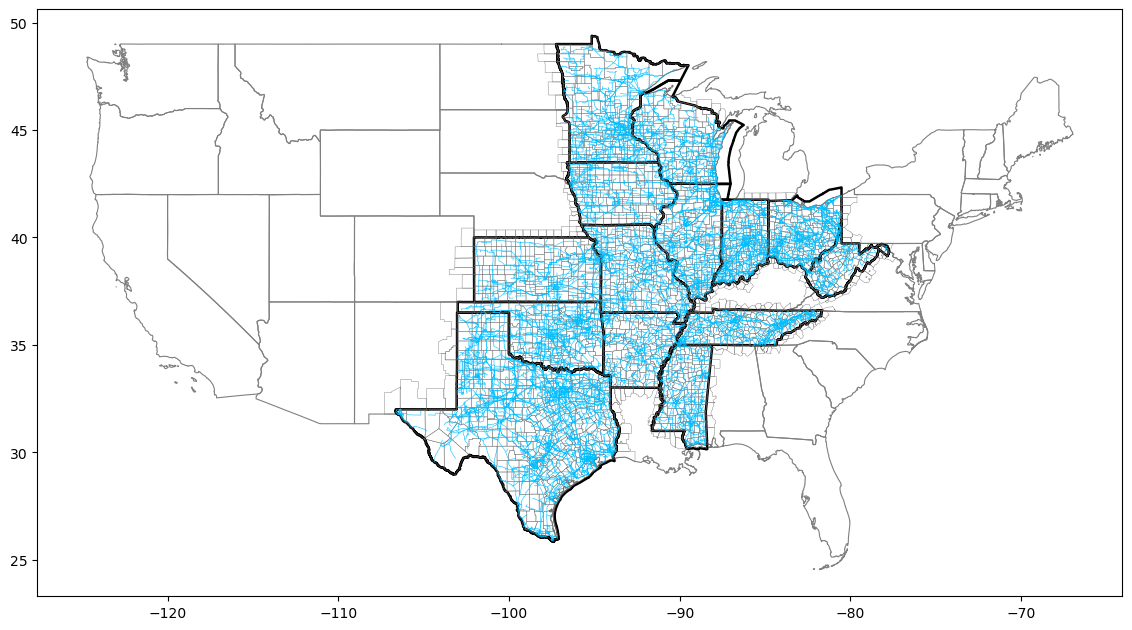

In [67]:
# 1) Normalize county/state geometry context
counties = counties_gdf.to_crs("EPSG:4326").copy()
counties = _to_county_fips(counties, state_col="STATE", county_col="COUNTY")

# Exclude AK/HI/PR for a CONUS background.
excluded_state_fips = {"02", "15", "72"}
counties_conus = counties[~counties["STATE"].isin(excluded_state_fips)].copy()

# AOI counties for county boundaries + Eagle-I shading.
aoi_union = gdf_aoi.to_crs("EPSG:4326").union_all()
counties_aoi = counties_conus[counties_conus.intersects(aoi_union)].copy()

conus_states = counties_conus.dissolve(by="STATE", as_index=False)


# 3) Plot layers in requested order
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Background: CONUS states in gray
conus_states.boundary.plot(ax=ax, color="gray", linewidth=0.8, zorder=1)

# AOI states bold
gdf_aoi.to_crs("EPSG:4326").boundary.plot(ax=ax, color="black", linewidth=1.8, zorder=2)

# AOI county lines
counties_aoi.boundary.plot(ax=ax, color="dimgray", linewidth=0.3, alpha=0.9, zorder=3)

# Physical grid in AOI
gdf_powergrid_aoi.to_crs("EPSG:4326").plot(ax=ax, color="deepskyblue", linewidth=0.5, alpha=0.8, zorder=4)


In [ ]:
from pathlib import Path
import subprocess
import shutil
import matplotlib.colors as mcolors

# Movie settings
frames_dir = Path('/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/figures/eaglei_whisker_frames')
frames_dir.mkdir(parents=True, exist_ok=True)
movie_path = frames_dir / 'eaglei_whisker_snapshot_movie_2023-03-28_to_2023-04-03.mp4'

start_hour_utc = pd.Timestamp('2023-03-28 00:00:00+00:00')
end_hour_utc = pd.Timestamp('2023-04-03 23:00:00+00:00')
all_hours = pd.date_range(start=start_hour_utc, end=end_hour_utc, freq='1h', tz='UTC')

# Tighter map bounds around AOI
lon_min, lat_min, lon_max, lat_max = gdf_aoi.to_crs('EPSG:4326').total_bounds
xlim = (lon_min - 1.0, lon_max + 1.0)
ylim = (lat_min - 0.7, lat_max + 0.7)

# Static layers
counties = counties_gdf.to_crs('EPSG:4326').copy()
counties['STATE'] = counties['STATE'].astype(str).str.zfill(2)
counties['COUNTY'] = counties['COUNTY'].astype(str).str.zfill(3)
counties['county_fips'] = counties['STATE'] + counties['COUNTY']
counties_conus = counties[~counties['STATE'].isin({'02', '15', '72'})].copy()
conus_states = counties_conus.dissolve(by='STATE', as_index=False)
aoi_geom = gdf_aoi.to_crs('EPSG:4326')
aoi_union = aoi_geom.union_all()
counties_aoi = counties_conus[counties_conus.intersects(aoi_union)].copy()
grid_aoi = gdf_powergrid_aoi.to_crs('EPSG:4326').copy()

# Eagle-I hourly max by county
eagle = eaglei_data.copy()
eagle['run_start_time'] = pd.to_datetime(eagle['run_start_time'], errors='coerce', utc=True)
eagle['hour'] = eagle['run_start_time'].dt.floor('h')
eagle['fips_code'] = eagle['fips_code'].astype(str).str.zfill(5)
eagle_hourly = (
    eagle.dropna(subset=['hour', 'fips_code'])
    .groupby(['hour', 'fips_code'], as_index=False)['sum']
    .max()
)

# Whisker hourly max sensors by lat/lon
whisker = df.copy()
whisker['start_time'] = pd.to_datetime(whisker['start_time'], errors='coerce', utc=True)
whisker['hour'] = whisker['start_time'].dt.floor('h')
whisker_hourly = (
    whisker.dropna(subset=['hour', 'latitude', 'longitude'])
    .groupby(['hour', 'latitude', 'longitude'], as_index=False)
    .agg(sensors=('sensors', 'max'))
)

if len(eagle_hourly) > 0:
    eagle_vmin = float(eagle_hourly['sum'].min())
    eagle_vmax = float(eagle_hourly['sum'].max())
else:
    eagle_vmin, eagle_vmax = 0.0, 1.0
if eagle_vmin == eagle_vmax:
    eagle_vmax = eagle_vmin + 1.0

print(f'Generating {len(all_hours)} frames in {frames_dir}')

for i, hour_ts in enumerate(all_hours):
    eagle_at_hour = eagle_hourly[eagle_hourly['hour'] == hour_ts].copy()
    whisker_at_hour = whisker_hourly[whisker_hourly['hour'] == hour_ts].copy()

    eagle_counties = counties_aoi.merge(
        eagle_at_hour[['fips_code', 'sum']].rename(columns={'fips_code': 'county_fips'}),
        on='county_fips',
        how='left'
    )
    eagle_counties['sum'] = eagle_counties['sum'].fillna(0)

    fig, ax = plt.subplots(1, 1, figsize=(12, 9))

    conus_states.boundary.plot(ax=ax, color='gray', linewidth=0.6, zorder=1)
    aoi_geom.boundary.plot(ax=ax, color='black', linewidth=1.8, zorder=2)
    counties_aoi.boundary.plot(ax=ax, color='dimgray', linewidth=0.25, alpha=0.8, zorder=3)
    grid_aoi.plot(ax=ax, color='deepskyblue', linewidth=0.4, alpha=0.8, zorder=4)

    eagle_counties.plot(
        ax=ax,
        column='sum',
        cmap='YlOrRd',
        linewidth=0,
        alpha=0.55,
        zorder=5,
        vmin=eagle_vmin,
        vmax=eagle_vmax,
    )

    sm = plt.cm.ScalarMappable(norm=mcolors.Normalize(vmin=eagle_vmin, vmax=eagle_vmax), cmap='YlOrRd')
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label('Eagle-I outage sum (hourly max by county)')

    if len(whisker_at_hour) > 0:
        sensor_size = whisker_at_hour['sensors'].fillna(1).clip(lower=1)
        ax.scatter(
            whisker_at_hour['longitude'],
            whisker_at_hour['latitude'],
            s=np.sqrt(sensor_size) * 10,
            c='black',
            alpha=0.75,
            edgecolor='white',
            linewidth=0.25,
            zorder=6,
        )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(
        f'Hourly outage snapshot (UTC {hour_ts:%Y-%m-%d %H:%M})\n'
        f'Eagle-I counties: {len(eagle_at_hour)} | Whisker points: {len(whisker_at_hour)}'
    )

    fig.savefig(frames_dir / f'frame_{i:04d}.png', dpi=140, bbox_inches='tight')
    plt.close(fig)

    if (i + 1) % 24 == 0 or i == 0 or i == len(all_hours) - 1:
        print(f'  saved {i + 1}/{len(all_hours)} frames')

if shutil.which('ffmpeg') is None:
    print('ffmpeg not found on PATH. Frames generated, movie not created.')
else:
    ffmpeg_cmd = [
        'ffmpeg', '-y',
        '-framerate', '6',
        '-i', str(frames_dir / 'frame_%04d.png'),
        '-c:v', 'libx264',
        '-pix_fmt', 'yuv420p',
        '-crf', '20',
        str(movie_path)
    ]
    print('Running ffmpeg...')
    subprocess.run(ffmpeg_cmd, check=True)
    print(f'Movie written to: {movie_path}')

movie_path

In [37]:
from pathlib import Path
import subprocess

frames_dir = Path('/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/figures/eaglei_whisker_frames')
movie_path = frames_dir / 'eaglei_whisker_snapshot_movie_2023-03-28_to_2023-04-03.mp4'

ffmpeg_cmd = [
    'ffmpeg', '-y',
    '-framerate', '6',
    '-i', str(frames_dir / 'frame_%04d.png'),
    '-vf', 'scale=trunc(iw/2)*2:trunc(ih/2)*2',
    '-c:v', 'libx264',
    '-pix_fmt', 'yuv420p',
    '-crf', '20',
    str(movie_path)
]

print('Running ffmpeg with even-dimension scaling...')
subprocess.run(ffmpeg_cmd, check=True)
print(f'Movie written to: {movie_path}')
movie_path

Running ffmpeg with even-dimension scaling...


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with clang version 19.1.7
  configuration: --prefix=/Users/ryanmc/miniforge3/envs/spwxr_network_new --cc=arm64-apple-darwin20.0.0-clang --cxx=arm64-apple-darwin20.0.0-clang++ --nm=arm64-apple-darwin20.0.0-nm --ar=arm64-apple-darwin20.0.0-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --enable-cross-compile --arch=arm64 --target-os=darwin --cross-prefix=arm64-apple-darwin20.0.0- --host-cc=/Users/runner/miniforge3/conda-bld/ffmpeg_1753272244790/_build_env/bin/x86_64-apple-darwin13.4.0-clang --enable-neon --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-libmp3lame --enable-libaom --enable-libsvtav1 --enable-libxml2 --enable-pic --enable-shared --disable-static --enable-version3 --enabl

Movie written to: /Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/figures/eaglei_whisker_frames/eaglei_whisker_snapshot_movie_2023-03-28_to_2023-04-03.mp4


[out#0/mp4 @ 0x12b904ef0] video:476KiB audio:0KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.587515%
frame=  168 fps=0.0 q=-1.0 Lsize=     478KiB time=00:00:27.66 bitrate= 141.6kbits/s speed=43.7x    
[libx264 @ 0x129f090c0] frame I:1     Avg QP: 7.41  size:272940
[libx264 @ 0x129f090c0] frame P:48    Avg QP:14.24  size:  2216
[libx264 @ 0x129f090c0] frame B:119   Avg QP:23.57  size:   899
[libx264 @ 0x129f090c0] consecutive B-frames:  3.6%  4.8%  3.6% 88.1%
[libx264 @ 0x129f090c0] mb I  I16..4: 51.9%  7.5% 40.6%
[libx264 @ 0x129f090c0] mb P  I16..4:  0.0%  0.0%  0.0%  P16..4:  2.6%  0.4%  0.3%  0.0%  0.0%    skip:96.7%
[libx264 @ 0x129f090c0] mb B  I16..4:  0.0%  0.0%  0.0%  B16..8:  1.2%  0.1%  0.1%  direct: 0.1%  skip:98.4%  L0:47.3% L1:50.8% BI: 1.9%
[libx264 @ 0x129f090c0] 8x8 transform intra:7.4% inter:41.6%
[libx264 @ 0x129f090c0] coded y,uvDC,uvAC intra: 40.6% 31.2% 30.7% inter: 0.5% 0.6% 0.3%
[libx264 @ 0x129f090c0] i16 v,h,dc,p: 84% 13%  2%  0%
[l

PosixPath('/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/figures/eaglei_whisker_frames/eaglei_whisker_snapshot_movie_2023-03-28_to_2023-04-03.mp4')

## Whisker voltage/frequency analysis: 1) event-rate climatology and 2) severity structure

In [11]:
import numpy as np
import re

base_whisker_dir = Path('/Users/ryanmc/Documents/NASA_JPL/Projects/NaturalHazards/NASA ROSES Disasters 2025-2027/data/Whisker_Labs_Data_March2026/2023-03-26 to 2023-04-09 Event')

event_files = {
    'Frequency': 'Frequency.json',
    'Sag_Inside_CBEMA': 'Sags_Inside_CBEMA.json',
    'Sag_Outside_CBEMA': 'Sags_Outside_CBEMA.json',
    'Swell_Inside_CBEMA': 'Swells_Inside_CBEMA.json',
    'Swell_Outside_CBEMA': 'Swells_Outside_CBEMA.json',
}

records = []
for event_group, file_name in event_files.items():
    file_path = base_whisker_dir / file_name
    with open(file_path, 'r', encoding='utf-8') as f:
        arr = json.load(f)

    for row in arr:
        loc = row.get('Location', {}) or {}

        start_local_raw = row.get('StartTimeLocal')
        local_hour = np.nan
        if isinstance(start_local_raw, str):
            m = re.search(r'T(\d{2}):\d{2}:\d{2}', start_local_raw)
            if m:
                local_hour = int(m.group(1))

        records.append({
            'event_group': event_group,
            'event_type': row.get('Type', event_group),
            'start_utc': pd.to_datetime(row.get('StartTime'), utc=True, errors='coerce'),
            'start_local_raw': start_local_raw,
            'local_hour': local_hour,
            'sensors': pd.to_numeric(row.get('Sensors'), errors='coerce'),
            'average_amplitude': pd.to_numeric(row.get('AverageAmplitude'), errors='coerce'),
            'lat': pd.to_numeric(loc.get('Latitude'), errors='coerce'),
            'lon': pd.to_numeric(loc.get('Longitude'), errors='coerce'),
        })

whisker_events = pd.DataFrame(records)
whisker_events = whisker_events.dropna(subset=['start_utc', 'average_amplitude', 'lat', 'lon', 'local_hour']).copy()
whisker_events['local_hour'] = whisker_events['local_hour'].astype(int)

whisker_events['utc_day'] = whisker_events['start_utc'].dt.floor('D')

print(f"Total events loaded: {len(whisker_events):,}")
print('Counts by event_group:')
print(whisker_events['event_group'].value_counts().sort_index())
print('\nUTC coverage:')
print(whisker_events['start_utc'].min(), 'to', whisker_events['start_utc'].max())
print('Local-hour parse completeness:')
print(whisker_events['local_hour'].notna().mean())

Total events loaded: 7,572
Counts by event_group:
event_group
Frequency              5741
Sag_Inside_CBEMA        721
Sag_Outside_CBEMA       947
Swell_Inside_CBEMA       77
Swell_Outside_CBEMA      86
Name: count, dtype: int64

UTC coverage:
2023-03-26 00:15:25.672000+00:00 to 2023-04-09 21:49:06.378000+00:00
Local-hour parse completeness:
1.0


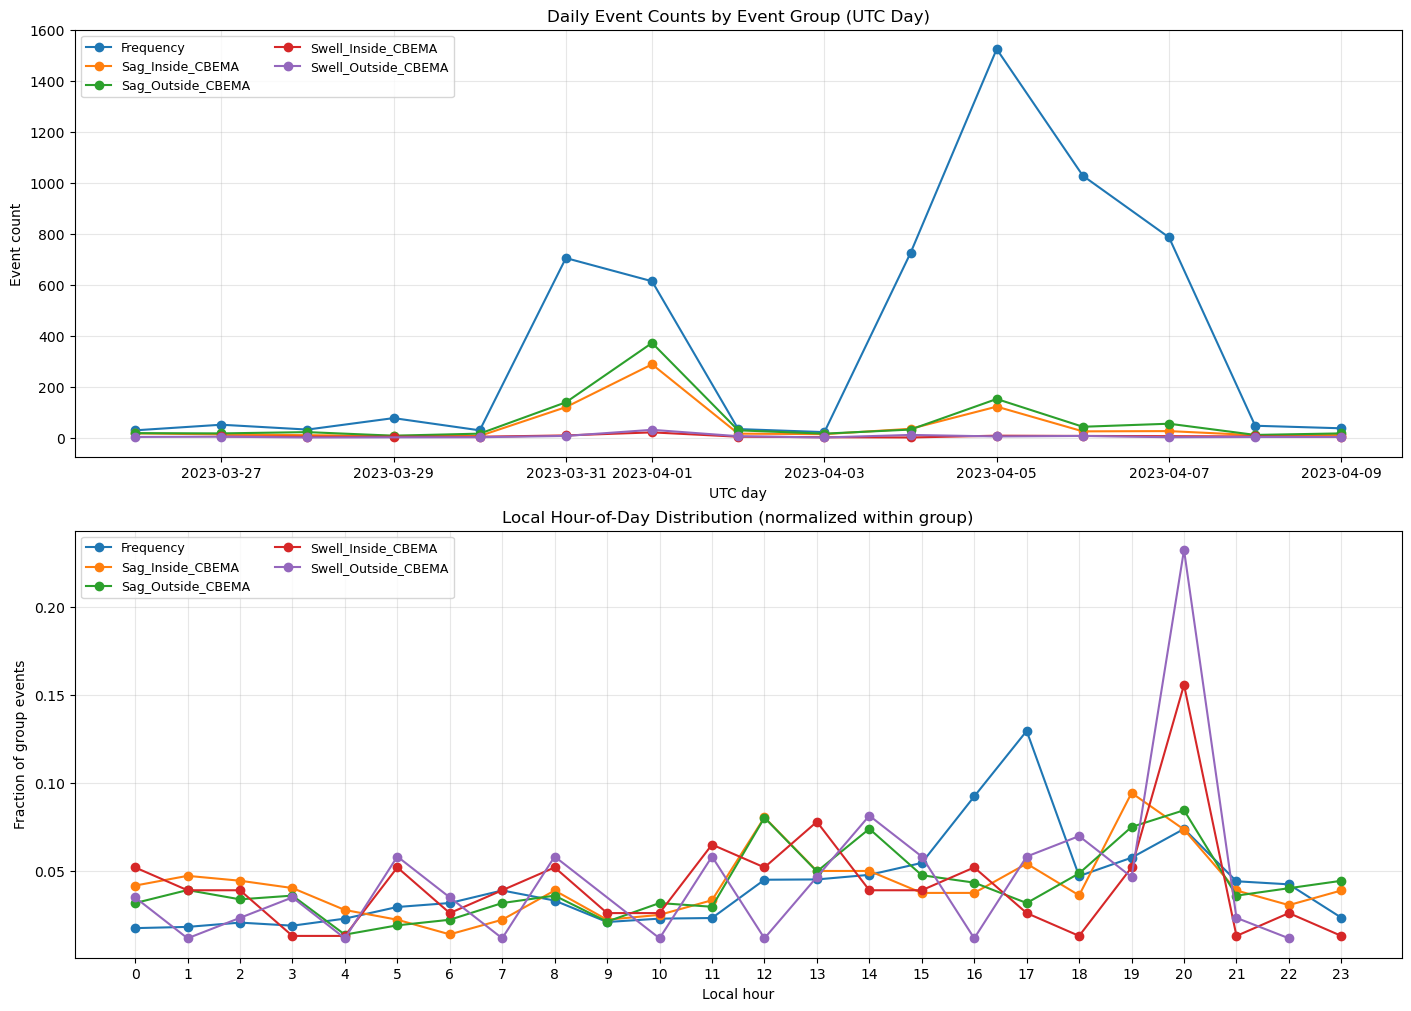

Top 10 day/group peaks:
                  utc_day       event_group  count
2023-04-05 00:00:00+00:00         Frequency   1525
2023-04-06 00:00:00+00:00         Frequency   1028
2023-04-07 00:00:00+00:00         Frequency    786
2023-04-04 00:00:00+00:00         Frequency    725
2023-03-31 00:00:00+00:00         Frequency    705
2023-04-01 00:00:00+00:00         Frequency    614
2023-04-01 00:00:00+00:00 Sag_Outside_CBEMA    372
2023-04-01 00:00:00+00:00  Sag_Inside_CBEMA    288
2023-04-05 00:00:00+00:00 Sag_Outside_CBEMA    152
2023-03-31 00:00:00+00:00 Sag_Outside_CBEMA    139


In [12]:
# 1) Event-rate climatology
fig, axes = plt.subplots(2, 1, figsize=(14, 10), constrained_layout=True)

# Daily event counts (UTC day)
daily_counts = (
    whisker_events
    .groupby(['utc_day', 'event_group'])
    .size()
    .reset_index(name='count')
)

for group, sub in daily_counts.groupby('event_group'):
    axes[0].plot(sub['utc_day'], sub['count'], marker='o', linewidth=1.5, label=group)

axes[0].set_title('Daily Event Counts by Event Group (UTC Day)')
axes[0].set_xlabel('UTC day')
axes[0].set_ylabel('Event count')
axes[0].grid(alpha=0.3)
axes[0].legend(ncol=2, fontsize=9)

# Local-hour distribution normalized within each event group
hour_counts = (
    whisker_events
    .groupby(['event_group', 'local_hour'])
    .size()
    .reset_index(name='count')
)
hour_counts['fraction'] = hour_counts['count'] / hour_counts.groupby('event_group')['count'].transform('sum')

for group, sub in hour_counts.groupby('event_group'):
    sub = sub.sort_values('local_hour')
    axes[1].plot(sub['local_hour'], sub['fraction'], marker='o', linewidth=1.5, label=group)

axes[1].set_title('Local Hour-of-Day Distribution (normalized within group)')
axes[1].set_xlabel('Local hour')
axes[1].set_ylabel('Fraction of group events')
axes[1].set_xticks(np.arange(0, 24, 1))
axes[1].grid(alpha=0.3)
axes[1].legend(ncol=2, fontsize=9)

plt.show()

peak_days = daily_counts.sort_values('count', ascending=False).head(10)
print('Top 10 day/group peaks:')
print(peak_days.to_string(index=False))

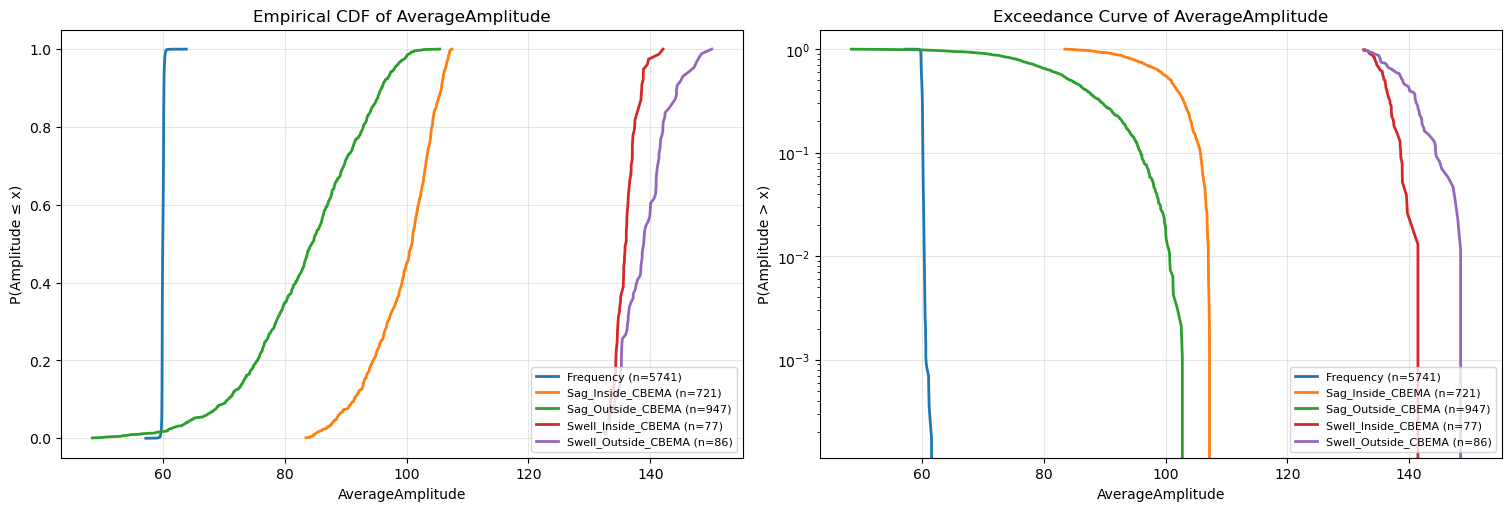

Amplitude summary by event_group:
                         min      p10      p50      p90      max     mean
event_group                                                              
Frequency             57.218   59.850   59.982   60.176   63.850   60.003
Sag_Inside_CBEMA      83.488   91.404  100.885  105.732  107.453   99.430
Sag_Outside_CBEMA     48.434   70.758   84.446   95.927  105.441   83.608
Swell_Inside_CBEMA   132.512  133.791  136.057  138.602  142.102  136.061
Swell_Outside_CBEMA  132.780  134.502  138.944  144.362  150.089  139.232


In [13]:
# 2) Severity structure: CDF and exceedance curves
amp_df = whisker_events[['event_group', 'average_amplitude']].dropna().copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

for group, sub in amp_df.groupby('event_group'):
    x = np.sort(sub['average_amplitude'].to_numpy())
    cdf = np.arange(1, len(x) + 1) / len(x)
    exceed = 1.0 - cdf

    axes[0].plot(x, cdf, linewidth=2, label=f'{group} (n={len(x)})')
    axes[1].plot(x, exceed, linewidth=2, label=f'{group} (n={len(x)})')

axes[0].set_title('Empirical CDF of AverageAmplitude')
axes[0].set_xlabel('AverageAmplitude')
axes[0].set_ylabel('P(Amplitude ≤ x)')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].set_title('Exceedance Curve of AverageAmplitude')
axes[1].set_xlabel('AverageAmplitude')
axes[1].set_ylabel('P(Amplitude > x)')
axes[1].set_yscale('log')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

plt.show()

summary = (
    amp_df
    .groupby('event_group')['average_amplitude']
    .quantile([0.1, 0.5, 0.9])
    .unstack()
    .rename(columns={0.1: 'p10', 0.5: 'p50', 0.9: 'p90'})
)
summary['mean'] = amp_df.groupby('event_group')['average_amplitude'].mean()
summary['min'] = amp_df.groupby('event_group')['average_amplitude'].min()
summary['max'] = amp_df.groupby('event_group')['average_amplitude'].max()
summary = summary[['min', 'p10', 'p50', 'p90', 'max', 'mean']].sort_index()

print('Amplitude summary by event_group:')
print(summary.round(3).to_string())

NameError: name 'eaglei_data' is not defined

In [14]:
whisker_events

,event_group,event_type,start_utc,start_local_raw,local_hour,sensors,average_amplitude,lat,lon,utc_day
0,Frequency,FrequencyJump,2023-03-26 00:15:25.672000+00:00,2023-03-25T20:15:25.672-04:00,20,5,59.884,41.437,-81.816,2023-03-26 00:00:00+00:00
1,Frequency,FrequencyJump,2023-03-26 00:16:52.376000+00:00,2023-03-25T20:16:52.376-04:00,20,4,59.860,39.986,-80.696,2023-03-26 00:00:00+00:00
2,Frequency,FrequencyJump,2023-03-26 02:13:08.946000+00:00,2023-03-25T22:13:08.946-04:00,22,17,59.858,40.168,-82.907,2023-03-26 00:00:00+00:00
3,Frequency,FrequencyJump,2023-03-26 02:13:28.477000+00:00,2023-03-25T22:13:28.477-04:00,22,18,59.973,40.168,-82.907,2023-03-26 00:00:00+00:00
4,Frequency,FrequencyJump,2023-03-26 07:43:09.931000+00:00,2023-03-26T02:43:09.931-05:00,2,5,59.842,33.062,-97.301,2023-03-26 00:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...
7567,Swell_Outside_CBEMA,Swell_outside_CBEMA,2023-04-08 11:51:33.433000+00:00,2023-04-08T06:51:33.433-05:00,6,28,139.295,41.958,-87.753,2023-04-08 00:00:00+00:00
7568,Swell_Outside_CBEMA,Swell_outside_CBEMA,2023-04-08 22:23:32.394000+00:00,2023-04-08T17:23:32.394-05:00,17,4,140.925,33.000,-96.784,2023-04-08 00:00:00+00:00
7569,Swell_Outside_CBEMA,Swell_outside_CBEMA,2023-04-09 03:42:23.179000+00:00,2023-04-08T22:42:23.179-05:00,22,4,133.315,40.731,-88.713,2023-04-09 00:00:00+00:00
7570,Swell_Outside_CBEMA,Swell_outside_CBEMA,2023-04-09 06:48:23.526000+00:00,2023-04-09T01:48:23.526-05:00,1,4,147.950,41.995,-88.021,2023-04-09 00:00:00+00:00


## Hypothesis-oriented transition diagnostics (without hazard driver)

This block operationalizes the chain using only power-quality and outage observations:
1. Stress emergence: elevated sag rates (especially outside CBEMA)
2. Localized fault proxy: deep sags (low-amplitude sag events)
3. Outgrowth/protection actions: outages and nearby swells
4. Restoration: decay back toward baseline after outage peaks

In [15]:
# Build outage table and hourly state proxies
if isinstance(whisker_outages, dict) and 'features' in whisker_outages:
    outages_iter = whisker_outages['features']
elif isinstance(whisker_outages, list):
    outages_iter = whisker_outages
else:
    raise ValueError('Unexpected structure in whisker_outages')

outage_records = []
for item in outages_iter:
    loc = (item or {}).get('Location', {}) or {}
    outage_records.append({
        'start_utc': pd.to_datetime((item or {}).get('StartTime'), utc=True, errors='coerce'),
        'sensors': pd.to_numeric((item or {}).get('Sensors'), errors='coerce'),
        'average_amplitude': pd.to_numeric((item or {}).get('AverageAmplitude'), errors='coerce'),
        'lat': pd.to_numeric(loc.get('Latitude'), errors='coerce'),
        'lon': pd.to_numeric(loc.get('Longitude'), errors='coerce'),
    })

df_outages = pd.DataFrame(outage_records).dropna(subset=['start_utc']).copy()
df_outages['hour'] = df_outages['start_utc'].dt.floor('H')

events = whisker_events.copy()
events['hour'] = events['start_utc'].dt.floor('H')

# Fault proxy threshold for deep sags (lower amplitude means deeper sag)
deep_sag_threshold = 90.0

hour_index = pd.date_range(
    start=min(events['hour'].min(), df_outages['hour'].min()),
    end=max(events['hour'].max(), df_outages['hour'].max()),
    freq='H',
    tz='UTC'
)

hourly = pd.DataFrame(index=hour_index)
hourly.index.name = 'hour'

hourly['frequency_count'] = events[events['event_group'] == 'Frequency'].groupby('hour').size().reindex(hour_index, fill_value=0)
hourly['sag_inside_count'] = events[events['event_group'] == 'Sag_Inside_CBEMA'].groupby('hour').size().reindex(hour_index, fill_value=0)
hourly['sag_outside_count'] = events[events['event_group'] == 'Sag_Outside_CBEMA'].groupby('hour').size().reindex(hour_index, fill_value=0)
hourly['sag_total_count'] = hourly['sag_inside_count'] + hourly['sag_outside_count']

hourly['deep_sag_count'] = (
    events[(events['event_group'].str.contains('Sag')) & (events['average_amplitude'] < deep_sag_threshold)]
    .groupby('hour').size().reindex(hour_index, fill_value=0)
)

hourly['swell_inside_count'] = events[events['event_group'] == 'Swell_Inside_CBEMA'].groupby('hour').size().reindex(hour_index, fill_value=0)
hourly['swell_outside_count'] = events[events['event_group'] == 'Swell_Outside_CBEMA'].groupby('hour').size().reindex(hour_index, fill_value=0)
hourly['swell_total_count'] = hourly['swell_inside_count'] + hourly['swell_outside_count']

hourly['outage_count'] = df_outages.groupby('hour').size().reindex(hour_index, fill_value=0)

# Stress emergence proxies
hourly['sag_outside_roll6h'] = hourly['sag_outside_count'].rolling(6, min_periods=1).mean()
hourly['sag_outside_roll24h'] = hourly['sag_outside_count'].rolling(24, min_periods=1).mean()
hourly['stress_ratio_6h_24h'] = (hourly['sag_outside_roll6h'] + 1e-9) / (hourly['sag_outside_roll24h'] + 1e-9)

display(hourly.head())
print(f'Hourly timeline length: {len(hourly)} hours')
print(f'Deep sag threshold used: amplitude < {deep_sag_threshold}')

/var/folders/g_/2j33jfhn72j448cr82hzgr0c0002d4/T/ipykernel_22028/1099686886.py:21: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_outages['hour'] = df_outages['start_utc'].dt.floor('H')
/var/folders/g_/2j33jfhn72j448cr82hzgr0c0002d4/T/ipykernel_22028/1099686886.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  events['hour'] = events['start_utc'].dt.floor('H')
/var/folders/g_/2j33jfhn72j448cr82hzgr0c0002d4/T/ipykernel_22028/1099686886.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hour_index = pd.date_range(


,frequency_count,sag_inside_count,sag_outside_count,sag_total_count,deep_sag_count,swell_inside_count,swell_outside_count,swell_total_count,outage_count,sag_outside_roll6h,sag_outside_roll24h,stress_ratio_6h_24h
hour,,,,,,,,,,,,
2023-03-26 00:00:00+00:00,2,1,1,2,0,0,0,0,5,1.00,1.00,1.0
2023-03-26 01:00:00+00:00,0,0,2,2,2,0,0,0,2,1.50,1.50,1.0
2023-03-26 02:00:00+00:00,2,1,0,1,0,0,0,0,1,1.00,1.00,1.0
2023-03-26 03:00:00+00:00,0,0,0,0,0,0,0,0,0,0.75,0.75,1.0
2023-03-26 04:00:00+00:00,0,0,1,1,1,0,0,0,1,0.80,0.80,1.0


Hourly timeline length: 360 hours
Deep sag threshold used: amplitude < 90.0


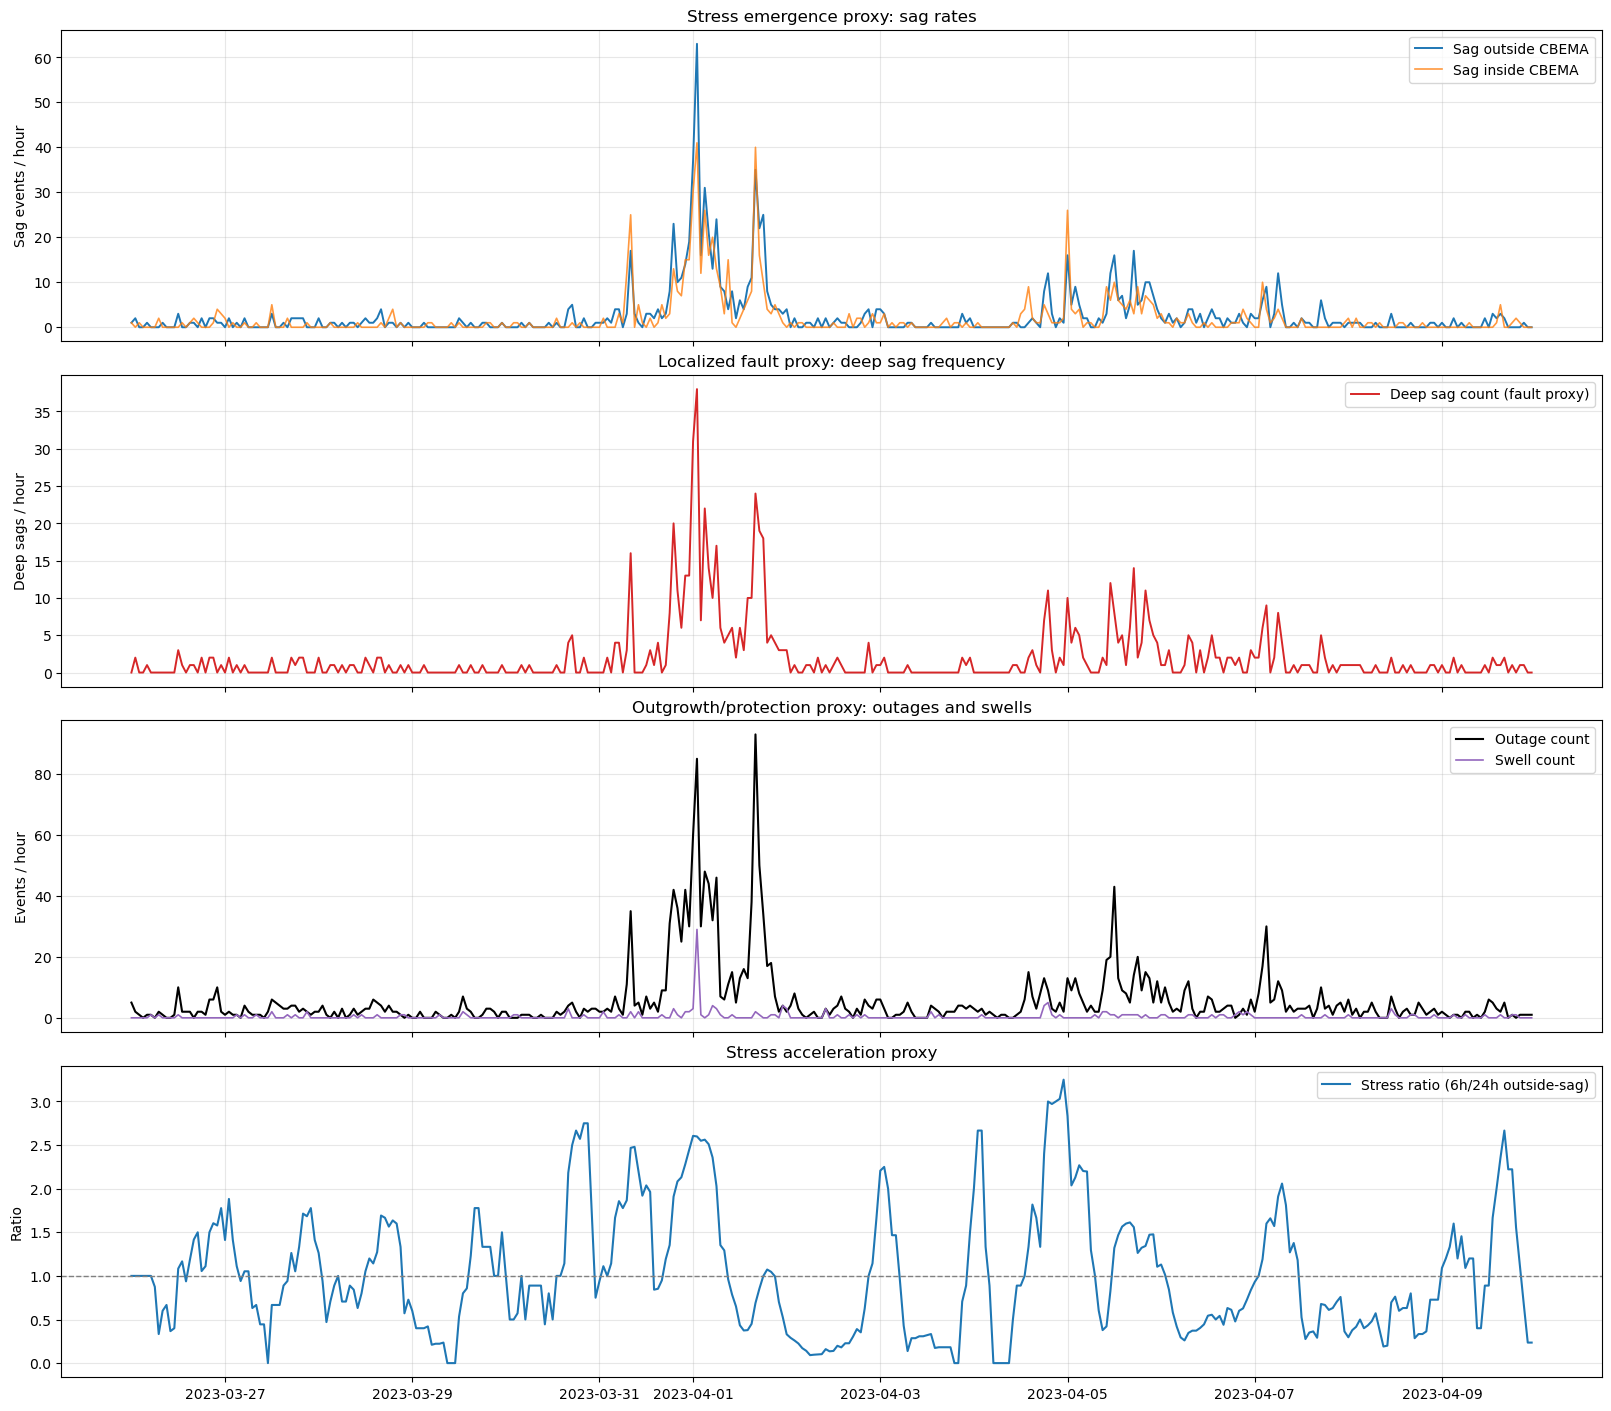

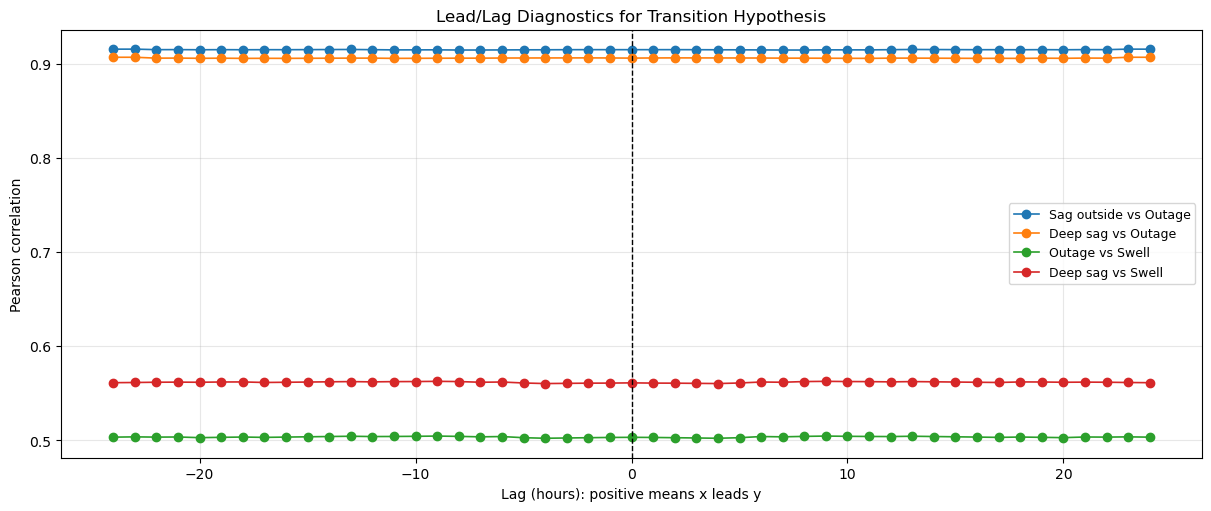

In [16]:
# Visualization of state-proxy chronology and lead/lag relationships
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True, constrained_layout=True)

axes[0].plot(hourly.index, hourly['sag_outside_count'], label='Sag outside CBEMA', linewidth=1.4)
axes[0].plot(hourly.index, hourly['sag_inside_count'], label='Sag inside CBEMA', linewidth=1.2, alpha=0.8)
axes[0].set_ylabel('Sag events / hour')
axes[0].set_title('Stress emergence proxy: sag rates')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(hourly.index, hourly['deep_sag_count'], color='tab:red', label='Deep sag count (fault proxy)', linewidth=1.4)
axes[1].set_ylabel('Deep sags / hour')
axes[1].set_title('Localized fault proxy: deep sag frequency')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(hourly.index, hourly['outage_count'], color='black', label='Outage count', linewidth=1.5)
axes[2].plot(hourly.index, hourly['swell_total_count'], color='tab:purple', label='Swell count', linewidth=1.2)
axes[2].set_ylabel('Events / hour')
axes[2].set_title('Outgrowth/protection proxy: outages and swells')
axes[2].legend()
axes[2].grid(alpha=0.3)

axes[3].plot(hourly.index, hourly['stress_ratio_6h_24h'], color='tab:blue', label='Stress ratio (6h/24h outside-sag)')
axes[3].axhline(1.0, linestyle='--', color='gray', linewidth=1)
axes[3].set_ylabel('Ratio')
axes[3].set_title('Stress acceleration proxy')
axes[3].legend()
axes[3].grid(alpha=0.3)

plt.show()

# Lead/lag correlation curves
max_lag_hours = 24
lags = np.arange(-max_lag_hours, max_lag_hours + 1)

def lagged_corr(x, y, lag):
    x = pd.Series(x)
    y = pd.Series(y)
    if lag > 0:
        return x.iloc[:-lag].corr(y.iloc[lag:])
    if lag < 0:
        return x.iloc[-lag:].corr(y.iloc[:lag])
    return x.corr(y)

pairs = [
    ('sag_outside_count', 'outage_count', 'Sag outside vs Outage'),
    ('deep_sag_count', 'outage_count', 'Deep sag vs Outage'),
    ('outage_count', 'swell_total_count', 'Outage vs Swell'),
    ('deep_sag_count', 'swell_total_count', 'Deep sag vs Swell'),
]

fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
for x_col, y_col, label in pairs:
    corrs = [lagged_corr(hourly[x_col].values, hourly[y_col].values, lag) for lag in lags]
    ax.plot(lags, corrs, marker='o', linewidth=1.2, label=label)

ax.axvline(0, color='k', linestyle='--', linewidth=1)
ax.set_xlabel('Lag (hours): positive means x leads y')
ax.set_ylabel('Pearson correlation')
ax.set_title('Lead/Lag Diagnostics for Transition Hypothesis')
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
plt.show()

Transition probability diagnostics:


,window_hours,P(outage_next_w | deep_sag_now),P(outage_next_w),lift_outage_from_deep_sag,P(swell_next_w | outage_now),P(swell_next_w),lift_swell_from_outage
0,1,0.901639,0.833333,1.081967,0.265781,0.261111,1.017884
1,3,0.994536,0.980556,1.014257,0.564784,0.555556,1.016611
2,6,1.000000,0.997222,1.002786,0.784053,0.775000,1.011681


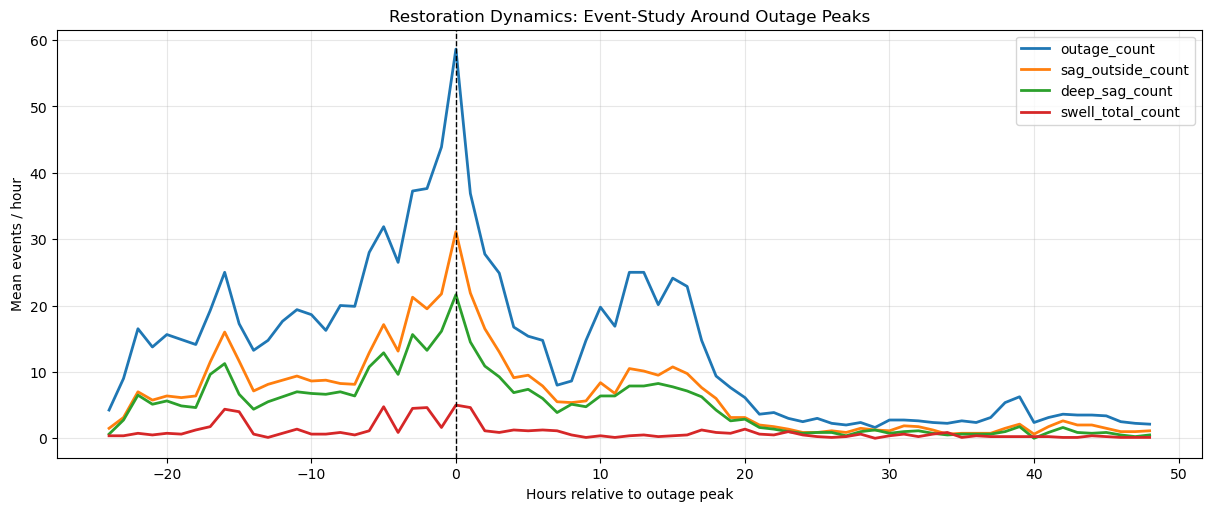

Approximate restoration timing (mean curve):
  outage_count: first return to near-baseline at +4 h
  sag_outside_count: first return to near-baseline at +4 h
  deep_sag_count: first return to near-baseline at +4 h
  swell_total_count: first return to near-baseline at +2 h


In [17]:
# Conditional probabilities and restoration dynamics
windows = [1, 3, 6]

binary = pd.DataFrame(index=hourly.index)
binary['deep_sag_now'] = (hourly['deep_sag_count'] > 0).astype(int)
binary['sag_outside_now'] = (hourly['sag_outside_count'] > 0).astype(int)
binary['outage_now'] = (hourly['outage_count'] > 0).astype(int)
binary['swell_now'] = (hourly['swell_total_count'] > 0).astype(int)

rows = []
for w in windows:
    any_outage_next_w = (
        pd.concat([binary['outage_now'].shift(-k) for k in range(1, w + 1)], axis=1)
        .max(axis=1)
        .fillna(0)
        .astype(int)
    )
    any_swell_next_w = (
        pd.concat([binary['swell_now'].shift(-k) for k in range(1, w + 1)], axis=1)
        .max(axis=1)
        .fillna(0)
        .astype(int)
    )

    # P(outage in next w | deep sag now) vs unconditional baseline
    cond_mask = binary['deep_sag_now'] == 1
    p_cond_out = any_outage_next_w[cond_mask].mean() if cond_mask.any() else np.nan
    p_base_out = any_outage_next_w.mean()

    # P(swell in next w | outage now) vs unconditional baseline
    cond_out_now = binary['outage_now'] == 1
    p_cond_swell = any_swell_next_w[cond_out_now].mean() if cond_out_now.any() else np.nan
    p_base_swell = any_swell_next_w.mean()

    rows.append({
        'window_hours': w,
        'P(outage_next_w | deep_sag_now)': p_cond_out,
        'P(outage_next_w)': p_base_out,
        'lift_outage_from_deep_sag': p_cond_out / p_base_out if p_base_out > 0 else np.nan,
        'P(swell_next_w | outage_now)': p_cond_swell,
        'P(swell_next_w)': p_base_swell,
        'lift_swell_from_outage': p_cond_swell / p_base_swell if p_base_swell > 0 else np.nan,
    })

transition_metrics = pd.DataFrame(rows)
print('Transition probability diagnostics:')
display(transition_metrics)

# Restoration event-study: align hours around top outage peaks
peak_hours = hourly[hourly['outage_count'] > 0].sort_values('outage_count', ascending=False).head(8).index
pre_h, post_h = 24, 48

profiles = []
for t0 in peak_hours:
    win = hourly.loc[(hourly.index >= t0 - pd.Timedelta(hours=pre_h)) & (hourly.index <= t0 + pd.Timedelta(hours=post_h)),
                     ['outage_count', 'sag_outside_count', 'deep_sag_count', 'swell_total_count']].copy()
    rel_h = ((win.index - t0) / pd.Timedelta(hours=1)).astype(int)
    win['rel_hour'] = rel_h
    profiles.append(win.set_index('rel_hour'))

if profiles:
    aligned = pd.concat(profiles).groupby(level=0).mean().sort_index()

    fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
    for col in ['outage_count', 'sag_outside_count', 'deep_sag_count', 'swell_total_count']:
        ax.plot(aligned.index, aligned[col], linewidth=2, label=col)

    ax.axvline(0, color='k', linestyle='--', linewidth=1)
    ax.set_xlabel('Hours relative to outage peak')
    ax.set_ylabel('Mean events / hour')
    ax.set_title('Restoration Dynamics: Event-Study Around Outage Peaks')
    ax.grid(alpha=0.3)
    ax.legend()
    plt.show()

    print('Approximate restoration timing (mean curve):')
    post = aligned[aligned.index >= 0]
    baseline = aligned[aligned.index < 0].mean()
    for col in ['outage_count', 'sag_outside_count', 'deep_sag_count', 'swell_total_count']:
        thresh = baseline[col] + 0.1 * max(1e-9, baseline[col])
        candidates = post.index[post[col] <= thresh]
        t_restore = int(candidates[0]) if len(candidates) else None
        print(f'  {col}: first return to near-baseline at +{t_restore} h')
else:
    print('No outage peaks found for restoration event-study.')

## Refinements

**Refinement 1** — Residual lead/lag: subtract 48-h rolling mean from each signal before correlating, to isolate sub-daily directionality from the shared storm envelope.

**Refinement 2** — Depth-stratified conditional probabilities: repeat the transition table at deeper sag thresholds (< 80 V, < 70 V) to test whether fault severity improves predictive lift.

**Refinement 3** — CBEMA-stratified transition table: split the sag predictor into inside- vs outside-CBEMA to directly test the equipment-survival framing (outside ≈ malfunction/damage risk).

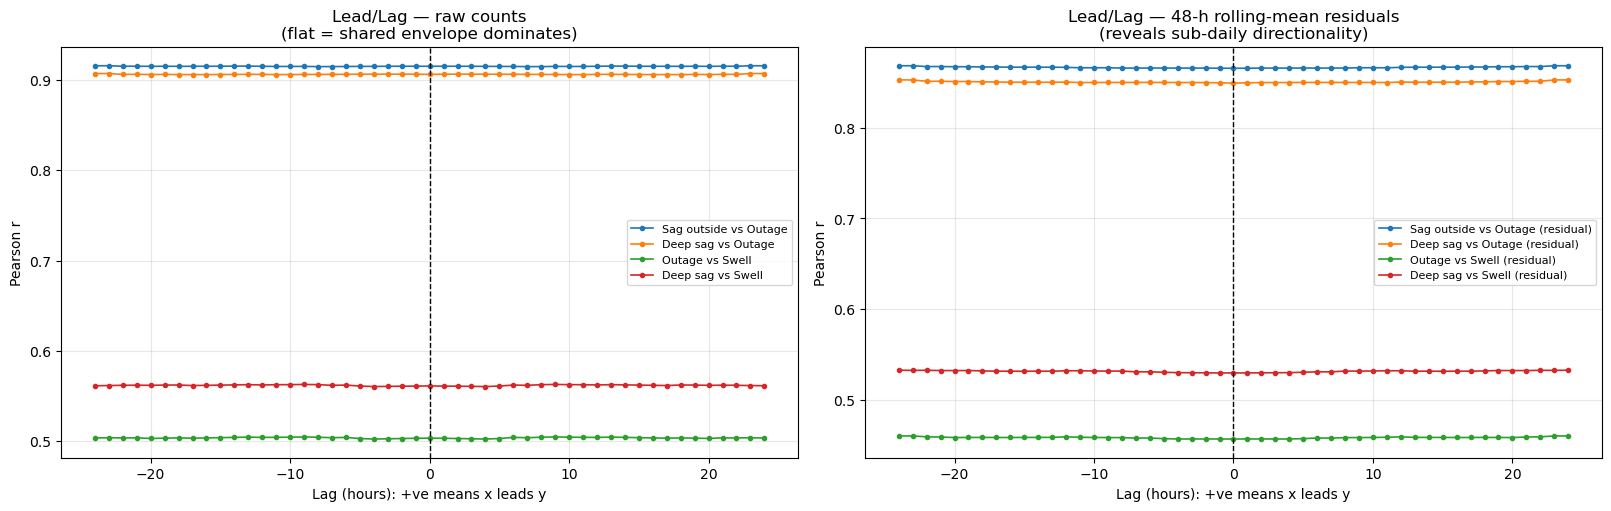

Peak correlation lags (residuals):
  Sag outside vs Outage (residual): peak |r|=0.868 at lag=-24 h  (positive = x leads y)
  Deep sag vs Outage (residual): peak |r|=0.853 at lag=-24 h  (positive = x leads y)
  Outage vs Swell (residual): peak |r|=0.460 at lag=-24 h  (positive = x leads y)
  Deep sag vs Swell (residual): peak |r|=0.533 at lag=-24 h  (positive = x leads y)


In [18]:
# Refinement 1: residual lead/lag to strip the shared storm envelope
roll_window = 48  # hours

hourly_resid = pd.DataFrame(index=hourly.index)
for col in ['sag_outside_count', 'deep_sag_count', 'outage_count', 'swell_total_count']:
    rolling_mean = hourly[col].rolling(roll_window, min_periods=1, center=True).mean()
    hourly_resid[col] = hourly[col] - rolling_mean

pairs_resid = [
    ('sag_outside_count', 'outage_count',    'Sag outside vs Outage (residual)'),
    ('deep_sag_count',    'outage_count',    'Deep sag vs Outage (residual)'),
    ('outage_count',      'swell_total_count','Outage vs Swell (residual)'),
    ('deep_sag_count',    'swell_total_count','Deep sag vs Swell (residual)'),
]

max_lag_hours = 24
lags = np.arange(-max_lag_hours, max_lag_hours + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

# Raw (left) for comparison
for x_col, y_col, label in pairs_resid:
    raw_label = label.replace(' (residual)', '')
    corrs = [lagged_corr(hourly[x_col].values, hourly[y_col].values, lag) for lag in lags]
    axes[0].plot(lags, corrs, marker='o', markersize=3, linewidth=1.2,
                 label=raw_label)

axes[0].axvline(0, color='k', linestyle='--', linewidth=1)
axes[0].set_title('Lead/Lag — raw counts\n(flat = shared envelope dominates)')
axes[0].set_xlabel('Lag (hours): +ve means x leads y')
axes[0].set_ylabel('Pearson r')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

# Residuals (right)
for x_col, y_col, label in pairs_resid:
    corrs = [lagged_corr(hourly_resid[x_col].values, hourly_resid[y_col].values, lag)
             for lag in lags]
    axes[1].plot(lags, corrs, marker='o', markersize=3, linewidth=1.2, label=label)

axes[1].axvline(0, color='k', linestyle='--', linewidth=1)
axes[1].set_title(f'Lead/Lag — {roll_window}-h rolling-mean residuals\n(reveals sub-daily directionality)')
axes[1].set_xlabel('Lag (hours): +ve means x leads y')
axes[1].set_ylabel('Pearson r')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

plt.show()

# Report peak-lag positions for the residuals
print('Peak correlation lags (residuals):')
for x_col, y_col, label in pairs_resid:
    corrs = np.array([lagged_corr(hourly_resid[x_col].values,
                                   hourly_resid[y_col].values, lag) for lag in lags])
    peak_idx = int(np.argmax(np.abs(corrs)))
    print(f'  {label}: peak |r|={corrs[peak_idx]:.3f} at lag={lags[peak_idx]:+d} h'
          f'  (positive = x leads y)')

Refinement 2 — depth-stratified transition probabilities:


n_deep_sag_hours  P(outage | deep_sag)  \
depth_threshold window_hours                                           
amp < 90        1                          183                0.9016   
                3                          183                0.9945   
                6                          183                1.0000   
amp < 80        1                          130                0.9538   
                3                          130                0.9923   
                6                          130                1.0000   
amp < 70        1                           57                0.9474   
                3                           57                0.9825   
                6                           57                1.0000   

                              P(outage) baseline  lift_outage  \
depth_threshold window_hours                                    
amp < 90        1                         0.8333       1.0820   
                3                         0.9806       1.0143   
                6                         0.9972       1.0028   
amp < 80        1                         0.8333       1.1446   
                3                         0.9806       1.0120   
                6                         0.9972       1.0028   
amp < 70        1                         0.8333       1.1368   
                3                         0.9806       1.0019   
                6                         0.9972       1.0028   

                              P(swell | deep_sag)  P(swell) baseline  \
depth_threshold window_hours                                           
amp < 90        1                          0.3115             0.2611   
                3                          0.6011             0.5556   
                6                          0.8087             0.7750   
amp < 80        1                          0.3154             0.2611   
                3                          0.6077             0.5556   
                6                          0.8308             0.7750   
amp < 70        1                          0.4386             0.2611   
                3                          0.6842             0.5556   
                6                          0.9298             0.7750   

                              lift_swell  
depth_threshold window_hours              
amp < 90        1                 1.1929  
                3                 1.0820  
                6                 1.0435  
amp < 80        1                 1.2079  
                3                 1.0938  
                6                 1.0720  
amp < 70        1                 1.6797  
                3                 1.2316  
                6                 1.1998

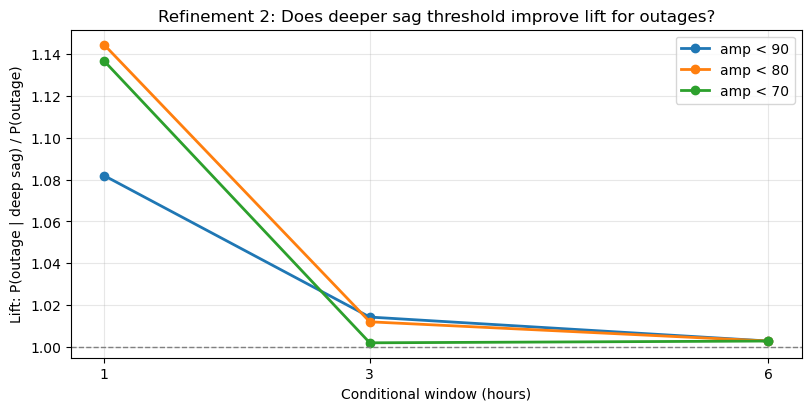

In [19]:
# Refinement 2: depth-stratified conditional probabilities
# Test whether progressively deeper sag thresholds improve predictive lift for outages

depth_thresholds = [90.0, 80.0, 70.0]
windows_r2 = [1, 3, 6]

r2_rows = []
for thresh_val in depth_thresholds:
    deep_mask = ((events['event_group'].str.contains('Sag')) &
                 (events['average_amplitude'] < thresh_val))
    deep_counts = events[deep_mask].groupby('hour').size().reindex(hour_index, fill_value=0)

    bin_deep = (deep_counts > 0).astype(int)
    bin_outage = (hourly['outage_count'] > 0).astype(int)
    bin_swell  = (hourly['swell_total_count'] > 0).astype(int)

    for w in windows_r2:
        any_outage_w = (
            pd.concat([bin_outage.shift(-k) for k in range(1, w + 1)], axis=1)
            .max(axis=1).fillna(0).astype(int)
        )
        any_swell_w = (
            pd.concat([bin_swell.shift(-k) for k in range(1, w + 1)], axis=1)
            .max(axis=1).fillna(0).astype(int)
        )
        mask = bin_deep == 1
        n_cond = int(mask.sum())
        p_cond = any_outage_w[mask].mean() if n_cond > 0 else np.nan
        p_base = any_outage_w.mean()

        p_cond_swell = any_swell_w[mask].mean() if n_cond > 0 else np.nan
        p_base_swell = any_swell_w.mean()

        r2_rows.append({
            'depth_threshold': f'amp < {thresh_val:.0f}',
            'n_deep_sag_hours': n_cond,
            'window_hours': w,
            'P(outage | deep_sag)': p_cond,
            'P(outage) baseline': p_base,
            'lift_outage': p_cond / p_base if p_base > 0 else np.nan,
            'P(swell | deep_sag)': p_cond_swell,
            'P(swell) baseline': p_base_swell,
            'lift_swell': p_cond_swell / p_base_swell if p_base_swell > 0 else np.nan,
        })

r2_df = pd.DataFrame(r2_rows)
print('Refinement 2 — depth-stratified transition probabilities:')
display(r2_df.set_index(['depth_threshold', 'window_hours']).round(4))

# Summary view: lift for outage at 1-hour window across thresholds
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
for thresh_val in depth_thresholds:
    sub = r2_df[r2_df['depth_threshold'] == f'amp < {thresh_val:.0f}']
    ax.plot(sub['window_hours'], sub['lift_outage'], marker='o', linewidth=2,
            label=f'amp < {thresh_val:.0f}')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Conditional window (hours)')
ax.set_ylabel('Lift: P(outage | deep sag) / P(outage)')
ax.set_title('Refinement 2: Does deeper sag threshold improve lift for outages?')
ax.set_xticks(windows_r2)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

Refinement 3 — CBEMA-stratified transition probabilities:


n_active_hours  P(outage | sag)  P(outage) base  \
sag_cbema_class window_hours                                                    
Sag_Inside      1                        170           0.9000          0.8333   
                3                        170           0.9941          0.9806   
                6                        170           1.0000          0.9972   
Sag_Outside     1                        206           0.9029          0.8333   
                3                        206           0.9903          0.9806   
                6                        206           1.0000          0.9972   

                              lift_outage  P(swell | sag)  P(swell) base  \
sag_cbema_class window_hours                                               
Sag_Inside      1                  1.0800          0.3235         0.2611   
                3                  1.0138          0.5941         0.5556   
                6                  1.0028          0.8000         0.7750   
Sag_Outside     1                  1.0835          0.3107         0.2611   
                3                  1.0099          0.5971         0.5556   
                6                  1.0028          0.8301         0.7750   

                              lift_swell  
sag_cbema_class window_hours              
Sag_Inside      1                 1.2390  
                3                 1.0694  
                6                 1.0323  
Sag_Outside     1                 1.1898  
                3                 1.0748  
                6                 1.0711

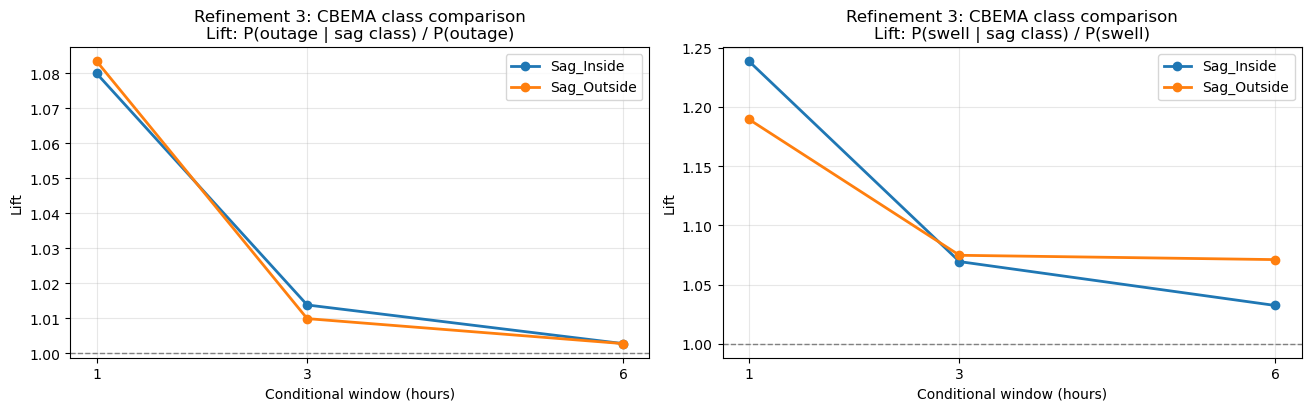


Key result (1-hour window, outage):
  Sag inside  CBEMA lift = 1.080  (equipment likely survives → weaker outage predictor)
  Sag outside CBEMA lift = 1.083  (malfunction/damage risk → stronger outage predictor)
  Ratio (outside / inside) = 1.003


In [20]:
# Refinement 3: CBEMA-stratified transition table
# Tests the equipment-survival framing:
#   inside CBEMA → equipment likely rides through (weaker predictor of outage/damage)
#   outside CBEMA → malfunction/damage risk (stronger predictor of outage)

cbema_groups = {
    'Sag_Inside':  'Sag_Inside_CBEMA',
    'Sag_Outside': 'Sag_Outside_CBEMA',
}
windows_r3 = [1, 3, 6]

r3_rows = []
for label_r3, group_name in cbema_groups.items():
    grp_counts = (
        events[events['event_group'] == group_name]
        .groupby('hour').size()
        .reindex(hour_index, fill_value=0)
    )
    bin_grp = (grp_counts > 0).astype(int)
    bin_outage = (hourly['outage_count'] > 0).astype(int)
    bin_swell  = (hourly['swell_total_count'] > 0).astype(int)

    for w in windows_r3:
        any_outage_w = (
            pd.concat([bin_outage.shift(-k) for k in range(1, w + 1)], axis=1)
            .max(axis=1).fillna(0).astype(int)
        )
        any_swell_w = (
            pd.concat([bin_swell.shift(-k) for k in range(1, w + 1)], axis=1)
            .max(axis=1).fillna(0).astype(int)
        )
        mask = bin_grp == 1
        n_cond = int(mask.sum())
        p_cond_out   = any_outage_w[mask].mean()  if n_cond > 0 else np.nan
        p_base_out   = any_outage_w.mean()
        p_cond_swell = any_swell_w[mask].mean()   if n_cond > 0 else np.nan
        p_base_swell = any_swell_w.mean()

        r3_rows.append({
            'sag_cbema_class':   label_r3,
            'n_active_hours':    n_cond,
            'window_hours':      w,
            'P(outage | sag)':   p_cond_out,
            'P(outage) base':    p_base_out,
            'lift_outage':       p_cond_out / p_base_out if p_base_out > 0 else np.nan,
            'P(swell | sag)':    p_cond_swell,
            'P(swell) base':     p_base_swell,
            'lift_swell':        p_cond_swell / p_base_swell if p_base_swell > 0 else np.nan,
        })

r3_df = pd.DataFrame(r3_rows)
print('Refinement 3 — CBEMA-stratified transition probabilities:')
display(r3_df.set_index(['sag_cbema_class', 'window_hours']).round(4))

# Lift comparison: inside vs outside CBEMA
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for label_r3, grp in r3_df.groupby('sag_cbema_class'):
    grp = grp.sort_values('window_hours')
    axes[0].plot(grp['window_hours'], grp['lift_outage'], marker='o', linewidth=2, label=label_r3)
    axes[1].plot(grp['window_hours'], grp['lift_swell'],  marker='o', linewidth=2, label=label_r3)

for ax, title in zip(axes, [
    'Lift: P(outage | sag class) / P(outage)',
    'Lift: P(swell | sag class) / P(swell)',
]):
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Conditional window (hours)')
    ax.set_ylabel('Lift')
    ax.set_title(f'Refinement 3: CBEMA class comparison\n{title}')
    ax.set_xticks(windows_r3)
    ax.legend()
    ax.grid(alpha=0.3)

plt.show()

# Print the key number for the hypothesis decision table
inside_lift_1h = r3_df.loc[(r3_df['sag_cbema_class']=='Sag_Inside')  & (r3_df['window_hours']==1), 'lift_outage'].values[0]
outside_lift_1h= r3_df.loc[(r3_df['sag_cbema_class']=='Sag_Outside') & (r3_df['window_hours']==1), 'lift_outage'].values[0]
print(f'\nKey result (1-hour window, outage):')
print(f'  Sag inside  CBEMA lift = {inside_lift_1h:.3f}  (equipment likely survives → weaker outage predictor)')
print(f'  Sag outside CBEMA lift = {outside_lift_1h:.3f}  (malfunction/damage risk → stronger outage predictor)')
print(f'  Ratio (outside / inside) = {outside_lift_1h / inside_lift_1h:.3f}')

## Hypothesis diagnostics with Eagle-I outages (county-level, 15-minute)

This section repeats the transition logic using Eagle-I county-level outages at 15-minute resolution:
1. Stress emergence: elevated outside-CBEMA sag counts
2. Localized fault proxy: deep sag counts
3. Outgrowth/protection: Eagle-I outage surges and swells
4. Restoration: post-peak decay in Eagle-I and Whisker signatures

In [23]:
# Build Eagle-I and Whisker aligned 15-minute signals
required_cols = {'run_start_time', 'fips_code', 'sum'}
missing_cols = sorted(list(required_cols - set(eaglei_data.columns)))
if missing_cols:
    raise ValueError(f'eaglei_data missing required columns: {missing_cols}')

eagle = eaglei_data.copy()
eagle['run_start_time'] = pd.to_datetime(eagle['run_start_time'], errors='coerce', utc=True)
eagle['fips_code'] = eagle['fips_code'].astype(str).str.zfill(5)
eagle['sum'] = pd.to_numeric(eagle['sum'], errors='coerce').fillna(0)
eagle = eagle.dropna(subset=['run_start_time']).copy()
eagle['t15'] = eagle['run_start_time'].dt.floor('15min')

# County-level outages transformed to system-level 15-minute metrics
eagle_15m = eagle.groupby('t15').agg(
    eagle_outage_sum=('sum', 'sum'),
    eagle_active_counties=('fips_code', lambda s: s.nunique()),
    eagle_counties_out_gt0=('sum', lambda s: int((s > 0).sum())),
).sort_index()

# Whisker 15-minute event counts
we = whisker_events.copy()
we['t15'] = we['start_utc'].dt.floor('15min')

whisker_15m = pd.DataFrame(index=we['t15'].sort_values().unique())
whisker_15m.index.name = 't15'

for g in ['Frequency', 'Sag_Inside_CBEMA', 'Sag_Outside_CBEMA', 'Swell_Inside_CBEMA', 'Swell_Outside_CBEMA']:
    whisker_15m[f'cnt_{g.lower()}'] = (
        we[we['event_group'] == g].groupby('t15').size().reindex(whisker_15m.index, fill_value=0)
    )

# Fault proxy: deep sags at two thresholds
deep_thresh_primary = 80.0
deep_thresh_secondary = 70.0
for thr in [deep_thresh_primary, deep_thresh_secondary]:
    whisker_15m[f'cnt_deep_sag_lt_{int(thr)}'] = (
        we[(we['event_group'].str.contains('Sag')) & (we['average_amplitude'] < thr)]
        .groupby('t15').size().reindex(whisker_15m.index, fill_value=0)
    )

# Merge and fill full 15-minute timeline
full_t15 = pd.date_range(
    start=min(eagle_15m.index.min(), whisker_15m.index.min()),
    end=max(eagle_15m.index.max(), whisker_15m.index.max()),
    freq='15min', tz='UTC'
)

eh = pd.DataFrame(index=full_t15)
eh.index.name = 't15'
eh = eh.join(eagle_15m, how='left').join(whisker_15m, how='left').fillna(0)

# Useful derived Eagle-I surge metrics
eh['eagle_outage_delta'] = eh['eagle_outage_sum'].diff().fillna(0)
eh['eagle_outage_roll2h'] = eh['eagle_outage_sum'].rolling(8, min_periods=1).mean()
eh['eagle_outage_roll24h'] = eh['eagle_outage_sum'].rolling(96, min_periods=1).mean()
eh['eagle_stress_ratio_2h_24h'] = (eh['eagle_outage_roll2h'] + 1e-9) / (eh['eagle_outage_roll24h'] + 1e-9)

print(f'15-minute timeline points: {len(eh):,}')
print('Eagle-I outage sum range:', float(eh['eagle_outage_sum'].min()), 'to', float(eh['eagle_outage_sum'].max()))
print('Whisker deep sag (<80 V) total count:', int(eh['cnt_deep_sag_lt_80'].sum()))
display(eh.head())

15-minute timeline points: 1,432
Eagle-I outage sum range: 0.0 to 1122984.0
Whisker deep sag (<80 V) total count: 328


,eagle_outage_sum,eagle_active_counties,eagle_counties_out_gt0,cnt_frequency,cnt_sag_inside_cbema,cnt_sag_outside_cbema,cnt_swell_inside_cbema,cnt_swell_outside_cbema,cnt_deep_sag_lt_80,cnt_deep_sag_lt_70,eagle_outage_delta,eagle_outage_roll2h,eagle_outage_roll24h,eagle_stress_ratio_2h_24h
t15,,,,,,,,,,,,,,
2023-03-26 00:00:00+00:00,750449.0,938.0,927.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,750449.000000,750449.000000,1.0
2023-03-26 00:15:00+00:00,733467.0,917.0,909.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,-16982.0,741958.000000,741958.000000,1.0
2023-03-26 00:30:00+00:00,713678.0,913.0,904.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-19789.0,732531.333333,732531.333333,1.0
2023-03-26 00:45:00+00:00,700202.0,891.0,870.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,-13476.0,724449.000000,724449.000000,1.0
2023-03-26 01:00:00+00:00,690736.0,866.0,856.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-9466.0,717706.400000,717706.400000,1.0


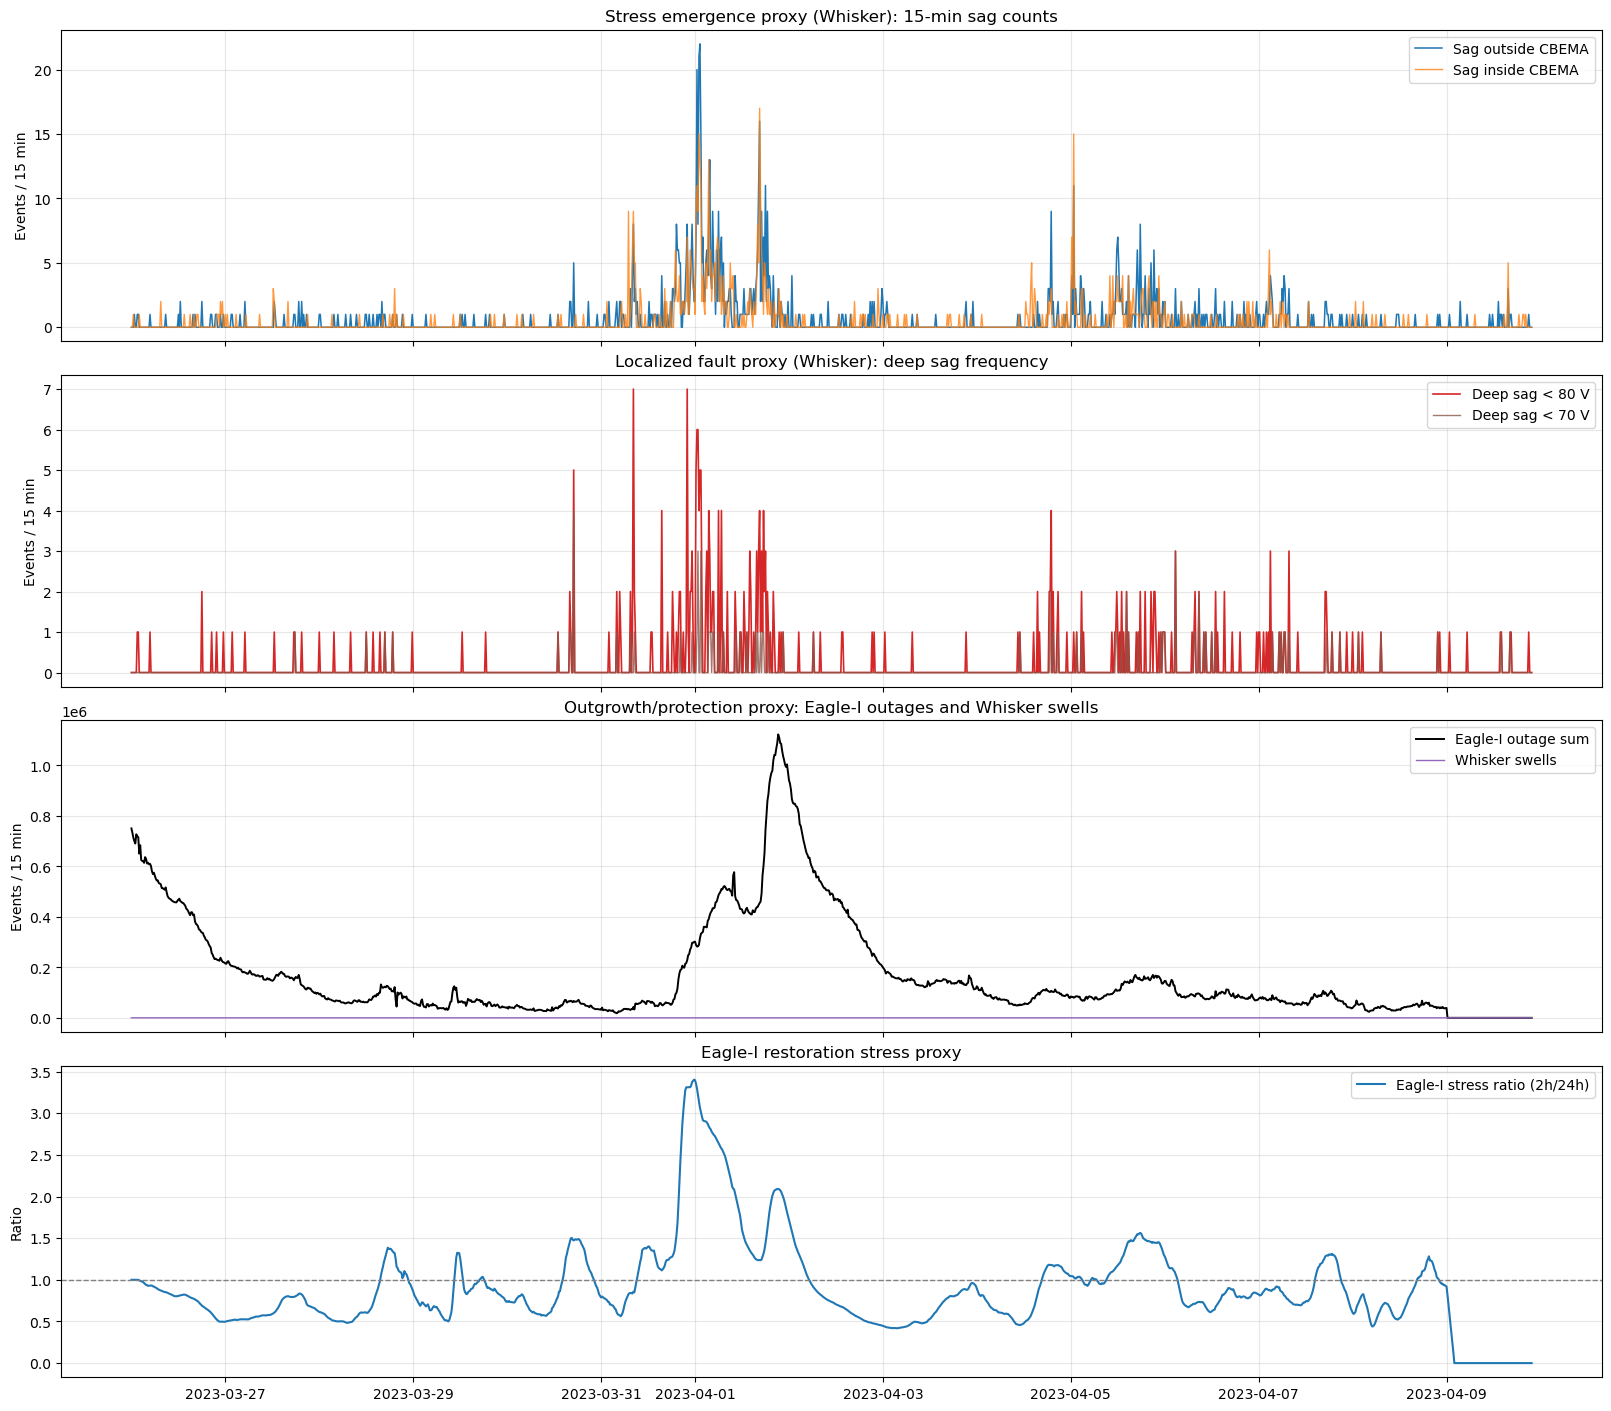

Sag outside vs Eagle-I outages: peak |r|=-0.058 at lag=-20.25 h (positive means x leads y)
Deep sag <80 vs Eagle-I outages: peak |r|=-0.059 at lag=-5.00 h (positive means x leads y)
Eagle-I outages vs Whisker swells: peak |r|=0.004 at lag=-5.75 h (positive means x leads y)


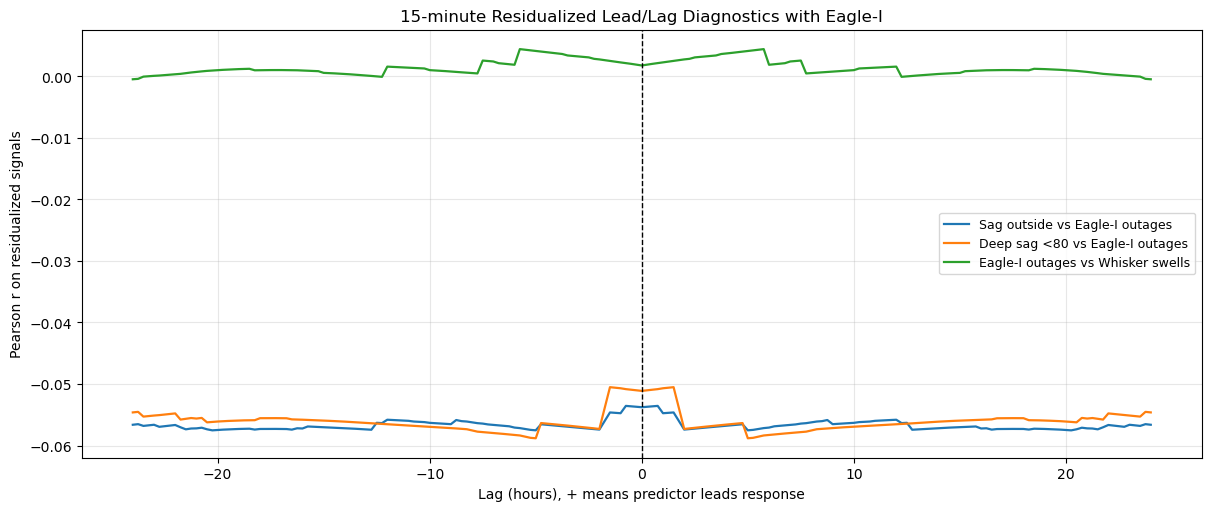

In [24]:
# Chronology and lead/lag diagnostics at 15-minute resolution
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True, constrained_layout=True)

axes[0].plot(eh.index, eh['cnt_sag_outside_cbema'], label='Sag outside CBEMA', linewidth=1.1)
axes[0].plot(eh.index, eh['cnt_sag_inside_cbema'], label='Sag inside CBEMA', linewidth=1.0, alpha=0.8)
axes[0].set_title('Stress emergence proxy (Whisker): 15-min sag counts')
axes[0].set_ylabel('Events / 15 min')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(eh.index, eh['cnt_deep_sag_lt_80'], color='tab:red', label='Deep sag < 80 V', linewidth=1.2)
axes[1].plot(eh.index, eh['cnt_deep_sag_lt_70'], color='tab:brown', label='Deep sag < 70 V', linewidth=1.0, alpha=0.8)
axes[1].set_title('Localized fault proxy (Whisker): deep sag frequency')
axes[1].set_ylabel('Events / 15 min')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(eh.index, eh['eagle_outage_sum'], color='black', label='Eagle-I outage sum', linewidth=1.4)
axes[2].plot(eh.index, eh['cnt_swell_inside_cbema'] + eh['cnt_swell_outside_cbema'], color='tab:purple', label='Whisker swells', linewidth=1.0)
axes[2].set_title('Outgrowth/protection proxy: Eagle-I outages and Whisker swells')
axes[2].set_ylabel('Events / 15 min')
axes[2].legend()
axes[2].grid(alpha=0.3)

axes[3].plot(eh.index, eh['eagle_stress_ratio_2h_24h'], color='tab:blue', label='Eagle-I stress ratio (2h/24h)')
axes[3].axhline(1.0, linestyle='--', color='gray', linewidth=1)
axes[3].set_title('Eagle-I restoration stress proxy')
axes[3].set_ylabel('Ratio')
axes[3].legend()
axes[3].grid(alpha=0.3)

plt.show()

# Lead/lag in +/- 24 h at 15-min resolution (96 bins)
max_lag_bins = 96
lags_bins = np.arange(-max_lag_bins, max_lag_bins + 1)

def lagged_corr_series(x, y, lag_bins):
    x = pd.Series(x)
    y = pd.Series(y)
    if lag_bins > 0:
        return x.iloc[:-lag_bins].corr(y.iloc[lag_bins:])
    if lag_bins < 0:
        return x.iloc[-lag_bins:].corr(y.iloc[:lag_bins])
    return x.corr(y)

# Residualize to remove shared envelope
roll_bins = 192  # 48h at 15-min resolution
eh_resid = pd.DataFrame(index=eh.index)
for c in ['cnt_sag_outside_cbema', 'cnt_deep_sag_lt_80', 'eagle_outage_sum', 'cnt_swell_inside_cbema', 'cnt_swell_outside_cbema']:
    eh_resid[c] = eh[c] - eh[c].rolling(roll_bins, min_periods=1, center=True).mean()
eh_resid['cnt_swell_total'] = eh_resid['cnt_swell_inside_cbema'] + eh_resid['cnt_swell_outside_cbema']

pairs_eagle = [
    ('cnt_sag_outside_cbema', 'eagle_outage_sum', 'Sag outside vs Eagle-I outages'),
    ('cnt_deep_sag_lt_80', 'eagle_outage_sum', 'Deep sag <80 vs Eagle-I outages'),
    ('eagle_outage_sum', 'cnt_swell_total', 'Eagle-I outages vs Whisker swells'),
]

fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
for x_col, y_col, label in pairs_eagle:
    corrs = np.array([lagged_corr_series(eh_resid[x_col].values, eh_resid[y_col].values, lag) for lag in lags_bins])
    ax.plot(lags_bins / 4.0, corrs, linewidth=1.6, label=label)
    peak_i = int(np.nanargmax(np.abs(corrs)))
    print(f'{label}: peak |r|={corrs[peak_i]:.3f} at lag={lags_bins[peak_i]/4.0:+.2f} h (positive means x leads y)')

ax.axvline(0, color='k', linestyle='--', linewidth=1)
ax.set_xlabel('Lag (hours), + means predictor leads response')
ax.set_ylabel('Pearson r on residualized signals')
ax.set_title('15-minute Residualized Lead/Lag Diagnostics with Eagle-I')
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
plt.show()

Eagle-I surge threshold (90th pct of outage delta): 7185.600
Transition metrics (Whisker predictor -> Eagle-I surge / Whisker swell):


,predictor,window_hours,P(eagle_surge_next | predictor_now),P(eagle_surge_next),lift_surge,P(swell_next | predictor_now),P(swell_next),lift_swell
0,sag_outside_now,0.25,0.1768,0.1006,1.7579,0.1162,0.0810,1.4340
1,deep80_now,0.25,0.2030,0.1006,2.0184,0.1337,0.0810,1.6501
2,deep70_now,0.25,0.1528,0.1006,1.5193,0.2083,0.0810,2.5718
3,sag_outside_now,1.00,0.4318,0.2891,1.4936,0.3434,0.2626,1.3080
4,deep80_now,1.00,0.4901,0.2891,1.6952,0.3663,0.2626,1.3952
5,deep70_now,1.00,0.4444,0.2891,1.5373,0.4722,0.2626,1.7985
6,sag_outside_now,3.00,0.7121,0.5642,1.2621,0.6338,0.5601,1.1317
7,deep80_now,3.00,0.7376,0.5642,1.3073,0.6683,0.5601,1.1933
8,deep70_now,3.00,0.7083,0.5642,1.2554,0.6667,0.5601,1.1904


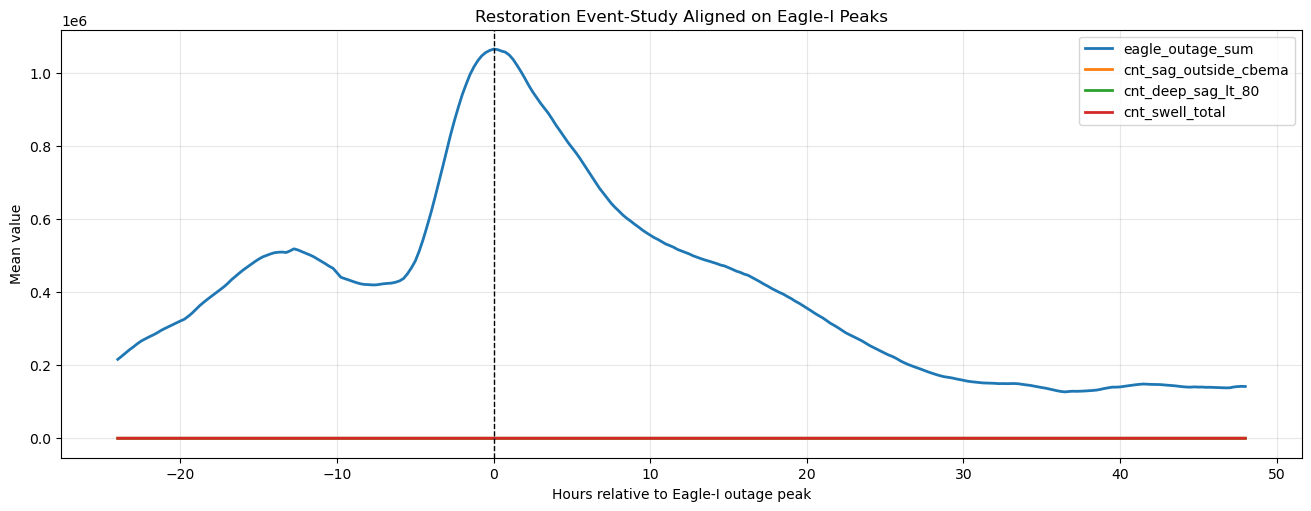

Near-baseline return times after Eagle-I peaks:
  eagle_outage_sum: +10.75 h
  cnt_sag_outside_cbema: +0.0 h
  cnt_deep_sag_lt_80: +0.0 h
  cnt_swell_total: +0.0 h


In [25]:
# Transition probabilities and restoration dynamics using Eagle-I as outage signal
windows_h = [0.25, 1.0, 3.0]  # 15 min, 1 h, 3 h
windows_bins = [int(w * 4) for w in windows_h]

# Define Eagle-I outage surge as upper-tail positive delta
surge_threshold = float(eh['eagle_outage_delta'].quantile(0.90))
eh['eagle_surge_now'] = (eh['eagle_outage_delta'] >= surge_threshold).astype(int)
eh['swell_total_now'] = ((eh['cnt_swell_inside_cbema'] + eh['cnt_swell_outside_cbema']) > 0).astype(int)
eh['deep80_now'] = (eh['cnt_deep_sag_lt_80'] > 0).astype(int)
eh['deep70_now'] = (eh['cnt_deep_sag_lt_70'] > 0).astype(int)
eh['sag_outside_now'] = (eh['cnt_sag_outside_cbema'] > 0).astype(int)

rows_eh = []
for w_h, w_b in zip(windows_h, windows_bins):
    any_surge_next = pd.concat([eh['eagle_surge_now'].shift(-k) for k in range(1, w_b + 1)], axis=1).max(axis=1).fillna(0)
    any_swell_next = pd.concat([eh['swell_total_now'].shift(-k) for k in range(1, w_b + 1)], axis=1).max(axis=1).fillna(0)

    for pred_name in ['sag_outside_now', 'deep80_now', 'deep70_now']:
        pred_mask = eh[pred_name] == 1
        p_cond_surge = any_surge_next[pred_mask].mean() if pred_mask.any() else np.nan
        p_base_surge = any_surge_next.mean()

        p_cond_swell = any_swell_next[pred_mask].mean() if pred_mask.any() else np.nan
        p_base_swell = any_swell_next.mean()

        rows_eh.append({
            'predictor': pred_name,
            'window_hours': w_h,
            'P(eagle_surge_next | predictor_now)': p_cond_surge,
            'P(eagle_surge_next)': p_base_surge,
            'lift_surge': p_cond_surge / p_base_surge if p_base_surge > 0 else np.nan,
            'P(swell_next | predictor_now)': p_cond_swell,
            'P(swell_next)': p_base_swell,
            'lift_swell': p_cond_swell / p_base_swell if p_base_swell > 0 else np.nan,
        })

trans_eagle = pd.DataFrame(rows_eh)
print(f'Eagle-I surge threshold (90th pct of outage delta): {surge_threshold:.3f}')
print('Transition metrics (Whisker predictor -> Eagle-I surge / Whisker swell):')
display(trans_eagle.round(4))

# Event-study around Eagle-I peaks (restoration)
peak_t15 = eh.sort_values('eagle_outage_sum', ascending=False).head(12).index
pre_bins, post_bins = 96, 192  # 24h before, 48h after
profiles = []

for t0 in peak_t15:
    win = eh.loc[(eh.index >= t0 - pd.Timedelta(minutes=15*pre_bins)) &
                 (eh.index <= t0 + pd.Timedelta(minutes=15*post_bins)),
                 ['eagle_outage_sum', 'cnt_sag_outside_cbema', 'cnt_deep_sag_lt_80', 'cnt_swell_inside_cbema', 'cnt_swell_outside_cbema']].copy()
    win['cnt_swell_total'] = win['cnt_swell_inside_cbema'] + win['cnt_swell_outside_cbema']
    rel_h = ((win.index - t0) / pd.Timedelta(hours=1)).astype(float)
    win['rel_h'] = rel_h
    profiles.append(win.set_index('rel_h')[['eagle_outage_sum', 'cnt_sag_outside_cbema', 'cnt_deep_sag_lt_80', 'cnt_swell_total']])

aligned_eagle = pd.concat(profiles).groupby(level=0).mean().sort_index()

fig, ax = plt.subplots(figsize=(13, 5), constrained_layout=True)
for col in ['eagle_outage_sum', 'cnt_sag_outside_cbema', 'cnt_deep_sag_lt_80', 'cnt_swell_total']:
    ax.plot(aligned_eagle.index, aligned_eagle[col], linewidth=2, label=col)
ax.axvline(0, color='k', linestyle='--', linewidth=1)
ax.set_xlabel('Hours relative to Eagle-I outage peak')
ax.set_ylabel('Mean value')
ax.set_title('Restoration Event-Study Aligned on Eagle-I Peaks')
ax.grid(alpha=0.3)
ax.legend()
plt.show()

# Simple near-baseline return time
baseline_e = aligned_eagle[aligned_eagle.index < 0].mean()
post_e = aligned_eagle[aligned_eagle.index >= 0]
print('Near-baseline return times after Eagle-I peaks:')
for col in ['eagle_outage_sum', 'cnt_sag_outside_cbema', 'cnt_deep_sag_lt_80', 'cnt_swell_total']:
    thr = baseline_e[col] + 0.10 * max(1e-9, baseline_e[col])
    cand = post_e.index[post_e[col] <= thr]
    t_restore = float(cand[0]) if len(cand) else None
    print(f'  {col}: +{t_restore} h')

In [26]:
# Compact summary of Eagle-I transition lifts
summary_cols = ['predictor', 'window_hours', 'lift_surge', 'lift_swell']
trans_eagle_summary = trans_eagle[summary_cols].copy().sort_values(['predictor', 'window_hours'])

print('Compact transition lift summary (Eagle-I):')
print(trans_eagle_summary.round(3).to_string(index=False))

print('\nBest outage-surge lift by predictor:')
best_by_predictor = trans_eagle.loc[trans_eagle.groupby('predictor')['lift_surge'].idxmax(), ['predictor', 'window_hours', 'lift_surge']]
print(best_by_predictor.round(3).to_string(index=False))

Compact transition lift summary (Eagle-I):
      predictor  window_hours  lift_surge  lift_swell
     deep70_now          0.25       1.519       2.572
     deep70_now          1.00       1.537       1.798
     deep70_now          3.00       1.255       1.190
     deep80_now          0.25       2.018       1.650
     deep80_now          1.00       1.695       1.395
     deep80_now          3.00       1.307       1.193
sag_outside_now          0.25       1.758       1.434
sag_outside_now          1.00       1.494       1.308
sag_outside_now          3.00       1.262       1.132

Best outage-surge lift by predictor:
      predictor  window_hours  lift_surge
     deep70_now          1.00       1.537
     deep80_now          0.25       2.018
sag_outside_now          0.25       1.758


## Nuance handling: commensurate severity and spatially explicit county panel

This section addresses two nuances:
1. Different measurement units (Eagle-I customers-out vs Whisker sensor/event amplitudes)
2. Spatial relationship (same-county and neighboring-county propagation)

Approach:
- Convert both feeds to county x 15-minute panel
- Build normalized county-level severity metrics
- Add neighbor exposure features from county adjacency
- Compare local vs neighbor-conditioned Eagle-I outage surges

In [27]:
# Build county-level 15-minute panel with commensurate severity variables
V_NOM = 120.0

# County geometry + FIPS
counties = counties_gdf.to_crs('EPSG:4326').copy()
counties['STATE'] = counties['STATE'].astype(str).str.zfill(2)
counties['COUNTY'] = counties['COUNTY'].astype(str).str.zfill(3)
counties['county_fips'] = counties['STATE'] + counties['COUNTY']
counties = counties[['county_fips', 'geometry']].drop_duplicates('county_fips')

# Restrict to AOI counties for cleaner spatial analysis
aoi_union = gdf_aoi.to_crs('EPSG:4326').union_all()
counties_aoi = counties[counties.intersects(aoi_union)].copy()

# Eagle-I county x 15-min
eagle_cty = eaglei_data.copy()
eagle_cty['run_start_time'] = pd.to_datetime(eagle_cty['run_start_time'], errors='coerce', utc=True)
eagle_cty['county_fips'] = eagle_cty['fips_code'].astype(str).str.zfill(5)
eagle_cty['customers_out'] = pd.to_numeric(eagle_cty['sum'], errors='coerce').fillna(0)
eagle_cty = eagle_cty.dropna(subset=['run_start_time'])
eagle_cty['t15'] = eagle_cty['run_start_time'].dt.floor('15min')

eagle_cty = (
    eagle_cty[eagle_cty['county_fips'].isin(set(counties_aoi['county_fips']))]
    .groupby(['county_fips', 't15'], as_index=False)
    .agg(customers_out=('customers_out', 'sum'))
)

# Whisker power-quality events + outage events unified
wpq = whisker_events[['event_group', 'start_utc', 'lat', 'lon', 'sensors', 'average_amplitude']].copy()
wpq['event_source'] = 'power_quality'
wpq['t15'] = wpq['start_utc'].dt.floor('15min')

wout = df_outages[['start_utc', 'lat', 'lon', 'sensors', 'average_amplitude']].copy()
wout['event_group'] = 'Outage_Whisker'
wout['event_source'] = 'outage'
wout['t15'] = wout['start_utc'].dt.floor('15min')

w_all = pd.concat([wpq, wout], ignore_index=True)
w_all = w_all.dropna(subset=['lat', 'lon', 't15']).copy()

# Severity constructs that respect unit nuance
w_all['sensor_weight'] = pd.to_numeric(w_all['sensors'], errors='coerce').fillna(1).clip(lower=1)
amp = pd.to_numeric(w_all['average_amplitude'], errors='coerce')

w_all['sag_severity'] = 0.0
w_all.loc[w_all['event_group'].str.contains('Sag', na=False), 'sag_severity'] = (
    w_all.loc[w_all['event_group'].str.contains('Sag', na=False), 'sensor_weight'] *
    ((V_NOM - amp[w_all['event_group'].str.contains('Sag', na=False)]) / V_NOM).clip(lower=0)
)

w_all['swell_severity'] = 0.0
w_all.loc[w_all['event_group'].str.contains('Swell', na=False), 'swell_severity'] = (
    w_all.loc[w_all['event_group'].str.contains('Swell', na=False), 'sensor_weight'] *
    ((amp[w_all['event_group'].str.contains('Swell', na=False)] - V_NOM) / V_NOM).clip(lower=0)
)

w_all['deep80_flag'] = ((w_all['event_group'].str.contains('Sag', na=False)) & (amp < 80)).astype(int)
w_all['outside_sag_flag'] = (w_all['event_group'] == 'Sag_Outside_CBEMA').astype(int)
w_all['whisker_outage_flag'] = (w_all['event_group'] == 'Outage_Whisker').astype(int)

# Spatial join Whisker events to counties
w_gdf = gpd.GeoDataFrame(
    w_all,
    geometry=gpd.points_from_xy(w_all['lon'], w_all['lat']),
    crs='EPSG:4326'
)

w_join = gpd.sjoin(
    w_gdf,
    counties_aoi[['county_fips', 'geometry']],
    how='inner',
    predicate='within'
).drop(columns=['index_right'])

w_cty = (
    w_join.groupby(['county_fips', 't15'], as_index=False)
    .agg(
        whisker_sensor_events=('sensor_weight', 'sum'),
        sag_severity=('sag_severity', 'sum'),
        swell_severity=('swell_severity', 'sum'),
        deep80_any=('deep80_flag', 'max'),
        outside_sag_any=('outside_sag_flag', 'max'),
        whisker_outage_any=('whisker_outage_flag', 'max'),
    )
)

# County x 15-min merged panel
panel = eagle_cty.merge(w_cty, on=['county_fips', 't15'], how='outer').fillna(0)
panel = panel.sort_values(['county_fips', 't15']).reset_index(drop=True)

# Normalize per county to address commensurability
for col in ['customers_out', 'whisker_sensor_events', 'sag_severity', 'swell_severity']:
    grp = panel.groupby('county_fips')[col]
    mean = grp.transform('mean')
    std = grp.transform('std').replace(0, np.nan)
    panel[f'{col}_z'] = ((panel[col] - mean) / std).fillna(0)

# Eagle county surge: county-specific top decile positive delta
panel['eagle_delta'] = panel.groupby('county_fips')['customers_out'].diff().fillna(0)
q90 = panel[panel['eagle_delta'] > 0].groupby('county_fips')['eagle_delta'].quantile(0.90)
panel = panel.merge(q90.rename('eagle_delta_q90'), on='county_fips', how='left')
panel['eagle_delta_q90'] = panel['eagle_delta_q90'].fillna(panel['eagle_delta'].quantile(0.90))
panel['eagle_surge_now'] = ((panel['eagle_delta'] > 0) & (panel['eagle_delta'] >= panel['eagle_delta_q90'])).astype(int)

print('County panel shape:', panel.shape)
print('Unique AOI counties in panel:', panel['county_fips'].nunique())
display(panel.head())

County panel shape: (552071, 16)
Unique AOI counties in panel: 1554


,county_fips,t15,customers_out,whisker_sensor_events,sag_severity,swell_severity,deep80_any,outside_sag_any,whisker_outage_any,customers_out_z,whisker_sensor_events_z,sag_severity_z,swell_severity_z,eagle_delta,eagle_delta_q90,eagle_surge_now
0,01023,2023-03-26 12:15:00+00:00,21.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.243976,0.0,0.0,0.0,0.0,28.5,0
1,01023,2023-03-26 12:30:00+00:00,21.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.243976,0.0,0.0,0.0,0.0,28.5,0
2,01023,2023-03-26 12:45:00+00:00,21.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.243976,0.0,0.0,0.0,0.0,28.5,0
3,01023,2023-03-26 13:00:00+00:00,24.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.219419,0.0,0.0,0.0,3.0,28.5,0
4,01023,2023-03-26 13:15:00+00:00,24.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.219419,0.0,0.0,0.0,0.0,28.5,0


Spatially conditioned 1-hour Eagle surge risk:


,condition,probability,lift
0,baseline,0.0539,1.0000
1,local deep sag <80,0.6180,11.4690
2,neighbor-only deep sag <80,0.3773,7.0015
3,local outside-CBEMA sag,0.5854,10.8637
4,neighbor-only outside-CBEMA sag,0.3517,6.5271


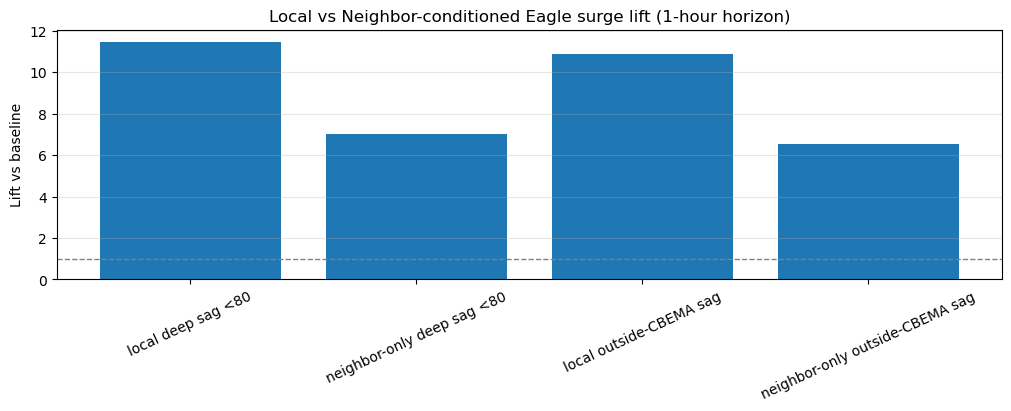

In [28]:
# Spatial propagation: same-county vs neighbor-county conditioning
county_geom = counties_aoi[['county_fips', 'geometry']].drop_duplicates('county_fips').copy()

neighbors = gpd.sjoin(
    county_geom.rename(columns={'county_fips': 'county_left'}),
    county_geom.rename(columns={'county_fips': 'county_right'}),
    predicate='touches', how='inner'
)[['county_left', 'county_right']]

# include self to form local-or-neighbor exposure
self_pairs = county_geom[['county_fips']].rename(columns={'county_fips': 'county_left'})
self_pairs['county_right'] = self_pairs['county_left']
neighbor_map = pd.concat([neighbors, self_pairs], ignore_index=True).drop_duplicates()

# Build neighbor deep-sag exposure at each t15
deep_by_county = panel[['county_fips', 't15', 'deep80_any', 'outside_sag_any']].rename(columns={'county_fips': 'county_right'})
neighbor_exposure = neighbor_map.merge(deep_by_county, on='county_right', how='left')
neighbor_exposure = (
    neighbor_exposure.groupby(['county_left', 't15'], as_index=False)
    .agg(deep80_neighbor_any=('deep80_any', 'max'), outside_sag_neighbor_any=('outside_sag_any', 'max'))
    .rename(columns={'county_left': 'county_fips'})
)

panel = panel.merge(neighbor_exposure, on=['county_fips', 't15'], how='left').fillna(0)
panel['deep80_neighbor_only'] = ((panel['deep80_neighbor_any'] > 0) & (panel['deep80_any'] == 0)).astype(int)

# Next-window Eagle surge (1 hour = 4 bins)
window_bins = 4
panel = panel.sort_values(['county_fips', 't15']).reset_index(drop=True)

future_cols = []
for k in range(1, window_bins + 1):
    col = f'eagle_surge_plus_{k}'
    panel[col] = panel.groupby('county_fips')['eagle_surge_now'].shift(-k).fillna(0)
    future_cols.append(col)
panel['eagle_surge_next_1h'] = (panel[future_cols].max(axis=1) > 0).astype(int)

# Conditioned probabilities
base = panel['eagle_surge_next_1h'].mean()
cond_local_deep = panel.loc[panel['deep80_any'] == 1, 'eagle_surge_next_1h'].mean()
cond_neighbor_deep = panel.loc[panel['deep80_neighbor_only'] == 1, 'eagle_surge_next_1h'].mean()
cond_local_outside = panel.loc[panel['outside_sag_any'] == 1, 'eagle_surge_next_1h'].mean()
cond_neighbor_outside = panel.loc[(panel['outside_sag_neighbor_any'] == 1) & (panel['outside_sag_any'] == 0), 'eagle_surge_next_1h'].mean()

spatial_lift = pd.DataFrame([
    {'condition': 'baseline', 'probability': base, 'lift': 1.0},
    {'condition': 'local deep sag <80', 'probability': cond_local_deep, 'lift': cond_local_deep / base if base > 0 else np.nan},
    {'condition': 'neighbor-only deep sag <80', 'probability': cond_neighbor_deep, 'lift': cond_neighbor_deep / base if base > 0 else np.nan},
    {'condition': 'local outside-CBEMA sag', 'probability': cond_local_outside, 'lift': cond_local_outside / base if base > 0 else np.nan},
    {'condition': 'neighbor-only outside-CBEMA sag', 'probability': cond_neighbor_outside, 'lift': cond_neighbor_outside / base if base > 0 else np.nan},
])

print('Spatially conditioned 1-hour Eagle surge risk:')
display(spatial_lift.round(4))

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
plot_df = spatial_lift[spatial_lift['condition'] != 'baseline'].copy()
ax.bar(plot_df['condition'], plot_df['lift'])
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('Lift vs baseline')
ax.set_title('Local vs Neighbor-conditioned Eagle surge lift (1-hour horizon)')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.3)
plt.show()

County-day block bootstrap CIs for 1-hour Eagle surge lift:


,condition,lift_point,lift_ci_low,lift_ci_high,bootstrap_samples
0,local deep sag <80,11.4690,10.2070,12.6645,300
1,neighbor-only deep sag <80,7.0015,6.3637,7.6584,300
2,local outside-CBEMA sag,10.8637,9.9942,11.7904,300
3,neighbor-only outside-CBEMA sag,6.5271,6.1301,6.9818,300


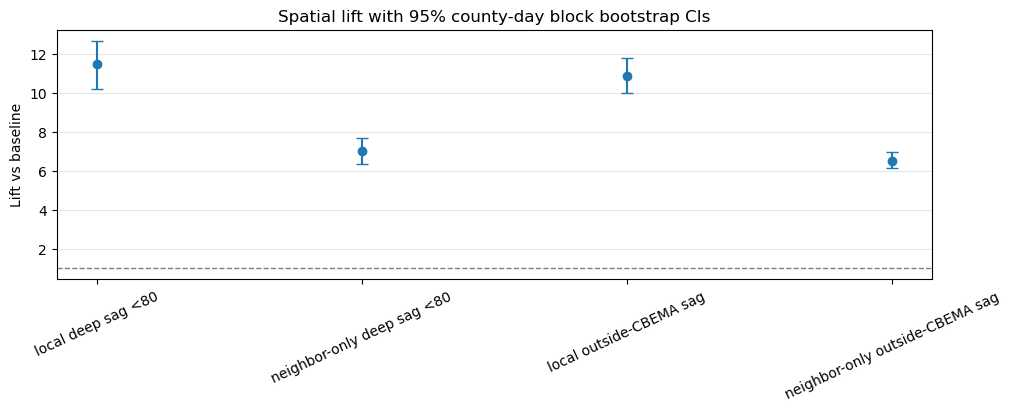

In [30]:
# Uncertainty quantification: county-day block bootstrap CIs for spatial lifts
required_cols = [
    'county_fips', 't15', 'eagle_surge_next_1h',
    'deep80_any', 'deep80_neighbor_only', 'outside_sag_any', 'outside_sag_neighbor_any'
]
missing_cols = [c for c in required_cols if c not in panel.columns]
if missing_cols:
    raise ValueError(f'Panel is missing columns needed for bootstrap CIs: {missing_cols}')

boot_df = panel[required_cols].copy()
boot_df['day'] = boot_df['t15'].dt.floor('D')
boot_df['block_id'] = boot_df['county_fips'].astype(str) + '|' + boot_df['day'].astype(str)

# Precompute indicator-weighted outcomes for fast block aggregation
y = boot_df['eagle_surge_next_1h'].astype(float)
boot_df['n'] = 1.0
boot_df['y'] = y

boot_df['n_local_deep'] = (boot_df['deep80_any'] == 1).astype(float)
boot_df['y_local_deep'] = boot_df['n_local_deep'] * y

boot_df['n_neighbor_deep'] = (boot_df['deep80_neighbor_only'] == 1).astype(float)
boot_df['y_neighbor_deep'] = boot_df['n_neighbor_deep'] * y

boot_df['n_local_outside'] = (boot_df['outside_sag_any'] == 1).astype(float)
boot_df['y_local_outside'] = boot_df['n_local_outside'] * y

boot_df['n_neighbor_outside'] = ((boot_df['outside_sag_neighbor_any'] == 1) & (boot_df['outside_sag_any'] == 0)).astype(float)
boot_df['y_neighbor_outside'] = boot_df['n_neighbor_outside'] * y

agg2 = boot_df.groupby('block_id', as_index=False)[
    [
        'n', 'y',
        'n_local_deep', 'y_local_deep',
        'n_neighbor_deep', 'y_neighbor_deep',
        'n_local_outside', 'y_local_outside',
        'n_neighbor_outside', 'y_neighbor_outside'
    ]
].sum()

metrics = [
    ('local deep sag <80', 'n_local_deep', 'y_local_deep'),
    ('neighbor-only deep sag <80', 'n_neighbor_deep', 'y_neighbor_deep'),
    ('local outside-CBEMA sag', 'n_local_outside', 'y_local_outside'),
    ('neighbor-only outside-CBEMA sag', 'n_neighbor_outside', 'y_neighbor_outside'),
]

# Point estimates
base_p = agg2['y'].sum() / max(1, agg2['n'].sum())
point_rows = []
for name, n_col, y_col in metrics:
    n_c = agg2[n_col].sum()
    y_c = agg2[y_col].sum()
    p_c = (y_c / n_c) if n_c > 0 else np.nan
    point_rows.append({'condition': name, 'probability': p_c, 'lift': p_c / base_p if base_p > 0 else np.nan})
point_df = pd.DataFrame(point_rows)

# County-day block bootstrap
n_boot = 300
rng = np.random.default_rng(42)
blocks = np.arange(len(agg2))
n_blocks = len(blocks)

boot_lifts = {name: [] for name, _, _ in metrics}
for _ in range(n_boot):
    draw_idx = rng.choice(blocks, size=n_blocks, replace=True)
    b = agg2.iloc[draw_idx]
    b_base = b['y'].sum() / max(1, b['n'].sum())

    for name, n_col, y_col in metrics:
        n_c = b[n_col].sum()
        y_c = b[y_col].sum()
        if n_c == 0 or b_base == 0:
            boot_lifts[name].append(np.nan)
        else:
            boot_lifts[name].append((y_c / n_c) / b_base)

ci_rows = []
for name, _, _ in metrics:
    vals = np.array(boot_lifts[name], dtype=float)
    vals = vals[np.isfinite(vals)]
    ci_rows.append({
        'condition': name,
        'lift_point': float(point_df.loc[point_df['condition'] == name, 'lift'].iloc[0]),
        'lift_ci_low': np.quantile(vals, 0.025) if len(vals) > 0 else np.nan,
        'lift_ci_high': np.quantile(vals, 0.975) if len(vals) > 0 else np.nan,
        'bootstrap_samples': int(len(vals)),
    })

spatial_lift_ci = pd.DataFrame(ci_rows)
print('County-day block bootstrap CIs for 1-hour Eagle surge lift:')
display(spatial_lift_ci.round(4))

# Error-bar plot
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
plot_ci = spatial_lift_ci.copy()
x = np.arange(len(plot_ci))
y = plot_ci['lift_point'].to_numpy()
yerr_low = y - plot_ci['lift_ci_low'].to_numpy()
yerr_high = plot_ci['lift_ci_high'].to_numpy() - y

ax.errorbar(x, y, yerr=[yerr_low, yerr_high], fmt='o', capsize=4)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(plot_ci['condition'], rotation=25)
ax.set_ylabel('Lift vs baseline')
ax.set_title('Spatial lift with 95% county-day block bootstrap CIs')
ax.grid(axis='y', alpha=0.3)
plt.show()

## Severity measure definitions and side-by-side movie (Eagle-I vs Whisker outages)

The movie uses county-level 15-minute signals:
- Left panel: Eagle-I severity (customers out, normalized per county as z-score)
- Right panel: Whisker outage intensity (sum of outage-event sensors, normalized per county as z-score)

Window: 2023-03-30 through 2023-04-02 (UTC)

In [31]:
# Variable dictionary for severity / intensity measures
severity_dict = pd.DataFrame([
    {
        'variable': 'customers_out',
        'dataset': 'Eagle-I',
        'level': 'county x 15-min',
        'definition': 'Total customers out in county at timestamp (sum over Eagle-I records).',
        'units': 'customers',
    },
    {
        'variable': 'customers_out_z',
        'dataset': 'Eagle-I',
        'level': 'county x 15-min',
        'definition': 'County-standardized severity: (customers_out - county mean) / county std.',
        'units': 'z-score',
    },
    {
        'variable': 'eagle_delta',
        'dataset': 'Eagle-I',
        'level': 'county x 15-min',
        'definition': '15-min first difference in customers_out; positive surges indicate worsening outages.',
        'units': 'customers per 15 min',
    },
    {
        'variable': 'eagle_surge_now',
        'dataset': 'Eagle-I',
        'level': 'county x 15-min',
        'definition': 'Indicator for county-specific upper-tail positive outage delta (>= county q90).',
        'units': 'binary (0/1)',
    },
    {
        'variable': 'whisker_outage_intensity',
        'dataset': 'Whisker',
        'level': 'county x 15-min',
        'definition': 'Sum of Sensors across Whisker outage events (event_group == Outage_Whisker) mapped to county.',
        'units': 'sensor-count equivalent',
    },
    {
        'variable': 'whisker_outage_intensity_z',
        'dataset': 'Whisker',
        'level': 'county x 15-min',
        'definition': 'County-standardized Whisker outage intensity.',
        'units': 'z-score',
    },
    {
        'variable': 'sag_severity',
        'dataset': 'Whisker',
        'level': 'county x 15-min',
        'definition': 'Sensor-weighted sag depth proxy: sum[ Sensors * max(0, (V_nom - amplitude)/V_nom ) ].',
        'units': 'weighted severity index',
    },
    {
        'variable': 'swell_severity',
        'dataset': 'Whisker',
        'level': 'county x 15-min',
        'definition': 'Sensor-weighted swell magnitude proxy: sum[ Sensors * max(0, (amplitude - V_nom)/V_nom ) ].',
        'units': 'weighted severity index',
    },
])

print('Severity/intensity variable descriptions:')
display(severity_dict)

# Build Whisker outage-only intensity at county x 15-min and merge into panel
w_outage_only = w_join[w_join['event_group'] == 'Outage_Whisker'].copy()
whisker_out_cty = (
    w_outage_only.groupby(['county_fips', 't15'], as_index=False)
    .agg(whisker_outage_intensity=('sensor_weight', 'sum'))
)

panel = panel.drop(columns=[c for c in ['whisker_outage_intensity', 'whisker_outage_intensity_z'] if c in panel.columns])
panel = panel.merge(whisker_out_cty, on=['county_fips', 't15'], how='left')
panel['whisker_outage_intensity'] = panel['whisker_outage_intensity'].fillna(0)

grp = panel.groupby('county_fips')['whisker_outage_intensity']
panel['whisker_outage_intensity_z'] = ((panel['whisker_outage_intensity'] - grp.transform('mean')) / grp.transform('std').replace(0, np.nan)).fillna(0)

print('Added columns to panel: whisker_outage_intensity, whisker_outage_intensity_z')
print(panel[['whisker_outage_intensity', 'whisker_outage_intensity_z']].describe().round(3))

Severity/intensity variable descriptions:


,variable,dataset,level,definition,units
0,customers_out,Eagle-I,county x 15-min,Total customers out in county at timestamp (su...,customers
1,customers_out_z,Eagle-I,county x 15-min,County-standardized severity: (customers_out -...,z-score
2,eagle_delta,Eagle-I,county x 15-min,15-min first difference in customers_out; posi...,customers per 15 min
3,eagle_surge_now,Eagle-I,county x 15-min,Indicator for county-specific upper-tail posit...,binary (0/1)
4,whisker_outage_intensity,Whisker,county x 15-min,Sum of Sensors across Whisker outage events (e...,sensor-count equivalent
5,whisker_outage_intensity_z,Whisker,county x 15-min,County-standardized Whisker outage intensity.,z-score
6,sag_severity,Whisker,county x 15-min,Sensor-weighted sag depth proxy: sum[ Sensors ...,weighted severity index
7,swell_severity,Whisker,county x 15-min,Sensor-weighted swell magnitude proxy: sum[ Se...,weighted severity index


Added columns to panel: whisker_outage_intensity, whisker_outage_intensity_z
       whisker_outage_intensity  whisker_outage_intensity_z
count                552071.000                  552071.000
mean                      0.032                      -0.000
std                       0.988                       0.632
min                       0.000                      -0.866
25%                       0.000                      -0.053
50%                       0.000                       0.000
75%                       0.000                       0.000
max                     184.000                      36.647


In [32]:
# Side-by-side movie: left Eagle-I severity, right Whisker outage intensity (county-level)
from pathlib import Path
import shutil
import subprocess
import matplotlib.colors as mcolors

movie_start = pd.Timestamp('2023-03-30 00:00:00+00:00')
movie_end = pd.Timestamp('2023-04-02 23:45:00+00:00')
movie_t15 = pd.date_range(movie_start, movie_end, freq='15min', tz='UTC')


frames_dir = Path('/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/figures/eaglei_whisker_frames/normalized outage severity data')
frames_dir.mkdir(parents=True, exist_ok=True)
movie_path = frames_dir / 'eaglei_severity_vs_whisker_outage_intensity_2023-03-30_to_2023-04-02.mp4'

# Precompute plotting bounds from AOI counties
bounds = counties_aoi.total_bounds
xlim = (bounds[0] - 0.5, bounds[2] + 0.5)
ylim = (bounds[1] - 0.5, bounds[3] + 0.5)

# Robust color limits for comparability across frames
left_vals = panel.loc[(panel['t15'] >= movie_start) & (panel['t15'] <= movie_end), 'customers_out_z']
right_vals = panel.loc[(panel['t15'] >= movie_start) & (panel['t15'] <= movie_end), 'whisker_outage_intensity_z']

left_lim = np.nanquantile(np.abs(left_vals), 0.98) if len(left_vals) > 0 else 2.0
right_lim = np.nanquantile(np.abs(right_vals), 0.98) if len(right_vals) > 0 else 2.0
left_lim = float(max(left_lim, 0.5))
right_lim = float(max(right_lim, 0.5))

cmap = 'coolwarm'
left_norm = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=-left_lim, vmax=left_lim)
right_norm = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=-right_lim, vmax=right_lim)

panel_window = panel[(panel['t15'] >= movie_start) & (panel['t15'] <= movie_end)].copy()

print(f'Generating {len(movie_t15)} frames to {frames_dir} ...')
for i, t in enumerate(movie_t15):
    snap = panel_window[panel_window['t15'] == t][['county_fips', 'customers_out_z', 'whisker_outage_intensity_z']]

    g = counties_aoi[['county_fips', 'geometry']].merge(snap, on='county_fips', how='left')
    g['customers_out_z'] = g['customers_out_z'].fillna(0)
    g['whisker_outage_intensity_z'] = g['whisker_outage_intensity_z'].fillna(0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

    counties_aoi.boundary.plot(ax=axes[0], color='lightgray', linewidth=0.3)
    g.plot(ax=axes[0], column='customers_out_z', cmap=cmap, norm=left_norm, linewidth=0)
    axes[0].set_title('Eagle-I severity (customers_out_z)')
    axes[0].set_xlim(xlim); axes[0].set_ylim(ylim)
    axes[0].set_xlabel('Lon'); axes[0].set_ylabel('Lat')

    counties_aoi.boundary.plot(ax=axes[1], color='lightgray', linewidth=0.3)
    g.plot(ax=axes[1], column='whisker_outage_intensity_z', cmap=cmap, norm=right_norm, linewidth=0)
    axes[1].set_title('Whisker outage intensity (z)')
    axes[1].set_xlim(xlim); axes[1].set_ylim(ylim)
    axes[1].set_xlabel('Lon'); axes[1].set_ylabel('Lat')

    # Shared timestamp title
    fig.suptitle(f'County-level severity comparison | UTC {t:%Y-%m-%d %H:%M}')

    # Colorbars
    sm_left = plt.cm.ScalarMappable(norm=left_norm, cmap=cmap)
    sm_left._A = []
    cb_left = fig.colorbar(sm_left, ax=axes[0], fraction=0.046, pad=0.04)
    cb_left.set_label('z-score')

    sm_right = plt.cm.ScalarMappable(norm=right_norm, cmap=cmap)
    sm_right._A = []
    cb_right = fig.colorbar(sm_right, ax=axes[1], fraction=0.046, pad=0.04)
    cb_right.set_label('z-score')

    out_png = frames_dir / f'frame_{i:04d}.png'
    fig.savefig(out_png, dpi=120, bbox_inches='tight')
    plt.close(fig)

    if (i + 1) % 48 == 0 or i == 0 or i == len(movie_t15) - 1:
        print(f'  saved {i + 1}/{len(movie_t15)} frames')

if shutil.which('ffmpeg') is None:
    print('ffmpeg not found; frames are generated but movie was not created.')
else:
    ffmpeg_cmd = [
        'ffmpeg', '-y',
        '-framerate', '8',
        '-i', str(frames_dir / 'frame_%04d.png'),
        '-vf', 'scale=trunc(iw/2)*2:trunc(ih/2)*2',
        '-c:v', 'libx264',
        '-pix_fmt', 'yuv420p',
        '-crf', '20',
        str(movie_path)
    ]
    print('Running ffmpeg...')
    subprocess.run(ffmpeg_cmd, check=True)
    print(f'Movie written to: {movie_path}')

movie_path

Generating 384 frames to /Users/ryanmc/Documents/Complex_Risk_Science/dev/Complex-Risk-Collective/.github/Projects/NASA-disasters-grid-resilience/data/tmp_frames_eaglei_whisker_20230330_20230402 ...
  saved 1/384 frames
  saved 48/384 frames
  saved 96/384 frames
  saved 144/384 frames
  saved 192/384 frames
  saved 240/384 frames
  saved 288/384 frames
  saved 336/384 frames
  saved 384/384 frames
Running ffmpeg...


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with clang version 19.1.7
  configuration: --prefix=/Users/ryanmc/miniforge3/envs/spwxr_network_new --cc=arm64-apple-darwin20.0.0-clang --cxx=arm64-apple-darwin20.0.0-clang++ --nm=arm64-apple-darwin20.0.0-nm --ar=arm64-apple-darwin20.0.0-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --enable-cross-compile --arch=arm64 --target-os=darwin --cross-prefix=arm64-apple-darwin20.0.0- --host-cc=/Users/runner/miniforge3/conda-bld/ffmpeg_1753272244790/_build_env/bin/x86_64-apple-darwin13.4.0-clang --enable-neon --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-libmp3lame --enable-libaom --enable-libsvtav1 --enable-libxml2 --enable-pic --enable-shared --disable-static --enable-version3 --enabl

Movie written to: /Users/ryanmc/Documents/Complex_Risk_Science/dev/Complex-Risk-Collective/.github/Projects/NASA-disasters-grid-resilience/data/tmp_frames_eaglei_whisker_20230330_20230402/eaglei_severity_vs_whisker_outage_intensity_2023-03-30_to_2023-04-02.mp4


[out#0/mp4 @ 0x123e1b100] video:1477KiB audio:0KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.363835%
frame=  384 fps=298 q=-1.0 Lsize=    1482KiB time=00:00:47.75 bitrate= 254.2kbits/s speed=  37x    
[libx264 @ 0x123e1d150] frame I:2     Avg QP: 6.17  size:106055
[libx264 @ 0x123e1d150] frame P:97    Avg QP:13.74  size:  9598
[libx264 @ 0x123e1d150] frame B:285   Avg QP:19.33  size:  1292
[libx264 @ 0x123e1d150] consecutive B-frames:  0.8%  0.5%  0.8% 97.9%
[libx264 @ 0x123e1d150] mb I  I16..4: 53.7% 12.6% 33.6%
[libx264 @ 0x123e1d150] mb P  I16..4:  0.0%  0.2%  0.6%  P16..4:  5.2%  1.1%  1.5%  0.0%  0.0%    skip:91.4%
[libx264 @ 0x123e1d150] mb B  I16..4:  0.0%  0.0%  0.0%  B16..8:  6.0%  0.5%  0.2%  direct: 0.3%  skip:93.1%  L0:46.7% L1:52.2% BI: 1.0%
[libx264 @ 0x123e1d150] 8x8 transform intra:15.1% inter:45.2%
[libx264 @ 0x123e1d150] coded y,uvDC,uvAC intra: 50.2% 37.4% 35.9% inter: 1.1% 2.4% 2.1%
[libx264 @ 0x123e1d150] i16 v,h,dc,p: 83% 13%  4%  0%


PosixPath('/Users/ryanmc/Documents/Complex_Risk_Science/dev/Complex-Risk-Collective/.github/Projects/NASA-disasters-grid-resilience/data/tmp_frames_eaglei_whisker_20230330_20230402/eaglei_severity_vs_whisker_outage_intensity_2023-03-30_to_2023-04-02.mp4')

## Cross-scale coupling: distribution-level Whisker vs transmission-level grid

Whisker events are observed on the distribution system, while `gdf_powergrid_aoi` represents transmission assets.

To avoid over-claiming direct component failure, this section uses a **distance-weighted coupling model**:
- map each Whisker event to nearest transmission line with a distance
- assign coupling weight as a decaying function of distance
- aggregate weighted stress per line and time bin
- test whether high line-stress intervals align with county-level Eagle-I surge risk

In [34]:
# Build distance-weighted line stress from Whisker events
import warnings

# Metric CRS for distances
metric_crs = 'EPSG:3857'

# Prepare transmission lines with stable IDs
lines_tx = gdf_powergrid_aoi[['geometry']].copy().reset_index(drop=True)
lines_tx['line_id'] = np.arange(len(lines_tx))
lines_tx = lines_tx.to_crs(metric_crs)

# Whisker event table with event semantics
wx = w_all.copy()
wx = wx.dropna(subset=['lat', 'lon', 't15']).copy()
wx_gdf = gpd.GeoDataFrame(wx, geometry=gpd.points_from_xy(wx['lon'], wx['lat']), crs='EPSG:4326').to_crs(metric_crs)

# Nearest-line association with distance in meters
try:
    wx_line = gpd.sjoin_nearest(
        wx_gdf,
        lines_tx[['line_id', 'geometry']],
        how='left',
        distance_col='dist_to_line_m'
    )
except Exception as e:
    warnings.warn(f'sjoin_nearest failed ({e}); using geometry distance fallback (slower).')
    line_sindex = lines_tx.sindex
    nearest_ids = []
    nearest_dists = []
    for geom in wx_gdf.geometry:
        cand = list(line_sindex.nearest(geom.bounds, num_results=10))
        cand_df = lines_tx.iloc[cand]
        d = cand_df.distance(geom)
        ii = d.idxmin()
        nearest_ids.append(int(lines_tx.loc[ii, 'line_id']))
        nearest_dists.append(float(d.min()))
    wx_line = wx_gdf.copy()
    wx_line['line_id'] = nearest_ids
    wx_line['dist_to_line_m'] = nearest_dists

# Distance-decay coupling: half-life style scales (meters)
lambda_m = 5000.0
wx_line['coupling_w'] = np.exp(-wx_line['dist_to_line_m'] / lambda_m)

# Event severity weighting: recognizes distribution-vs-transmission uncertainty
wx_line['event_weight'] = 0.0
wx_line.loc[wx_line['event_group'].eq('Outage_Whisker'), 'event_weight'] += 2.0
wx_line.loc[wx_line['event_group'].eq('Sag_Outside_CBEMA'), 'event_weight'] += 1.5
wx_line.loc[wx_line['event_group'].eq('Sag_Inside_CBEMA'), 'event_weight'] += 1.0
wx_line.loc[wx_line['event_group'].eq('Swell_Outside_CBEMA'), 'event_weight'] += 0.8
wx_line.loc[wx_line['event_group'].eq('Swell_Inside_CBEMA'), 'event_weight'] += 0.5
wx_line.loc[wx_line['event_group'].eq('Frequency'), 'event_weight'] += 0.4

wx_line['sensor_w'] = pd.to_numeric(wx_line.get('sensor_weight', wx_line.get('sensors', 1)), errors='coerce').fillna(1).clip(lower=1)
wx_line['line_stress_contrib'] = wx_line['sensor_w'] * wx_line['event_weight'] * wx_line['coupling_w']

# Summaries for interpretation of cross-scale uncertainty
dist_summary = wx_line['dist_to_line_m'].describe(percentiles=[0.5, 0.75, 0.9, 0.95]).rename('dist_to_line_m')
print('Distance of Whisker events to nearest transmission line (meters):')
print(dist_summary)

# Aggregate to line x 15-min
line_t15 = (
    wx_line.groupby(['line_id', 't15'], as_index=False)
    .agg(
        line_stress=('line_stress_contrib', 'sum'),
        mean_coupling_w=('coupling_w', 'mean'),
        n_events=('line_id', 'size'),
        min_dist_m=('dist_to_line_m', 'min')
    )
)

# Map line to county via centroid for Eagle-I linkage
lines_centroid = lines_tx.copy()
lines_centroid['geometry'] = lines_centroid.geometry.centroid
lines_centroid = lines_centroid.to_crs('EPSG:4326')
line_county = gpd.sjoin(
    lines_centroid[['line_id', 'geometry']],
    counties_aoi[['county_fips', 'geometry']].to_crs('EPSG:4326'),
    how='left', predicate='within'
).drop(columns=['index_right'])
line_county = line_county[['line_id', 'county_fips']].drop_duplicates('line_id')

line_t15 = line_t15.merge(line_county, on='line_id', how='left')

# Attach county-level Eagle surge target at same t15 and next 1h
line_panel = line_t15.merge(
    panel[['county_fips', 't15', 'eagle_surge_now', 'eagle_surge_next_1h']],
    on=['county_fips', 't15'], how='left'
).fillna({'eagle_surge_now': 0, 'eagle_surge_next_1h': 0})

# Normalize stress within line for comparability
grp = line_panel.groupby('line_id')['line_stress']
line_panel['line_stress_z'] = ((line_panel['line_stress'] - grp.transform('mean')) / grp.transform('std').replace(0, np.nan)).fillna(0)

print('\nLine-time panel built:', line_panel.shape)
display(line_panel.head())

Distance of Whisker events to nearest transmission line (meters):
count    10078.000000
mean      4359.066427
std       5447.362840
min          0.045919
50%       2862.733393
75%       3525.899186
90%      17536.826980
95%      17845.212527
max      25459.673528
Name: dist_to_line_m, dtype: float64

Line-time panel built: (4284, 10)


,line_id,t15,line_stress,mean_coupling_w,n_events,min_dist_m,county_fips,eagle_surge_now,eagle_surge_next_1h,line_stress_z
0,1,2023-04-01 16:30:00+00:00,8.889350,0.988567,3,31.418831,39153,0.0,1.0,0.000000
1,4,2023-04-01 17:45:00+00:00,9.328751,0.777396,1,1259.027686,54107,0.0,1.0,0.000000
2,15,2023-03-31 20:00:00+00:00,6.260976,0.782622,1,1225.527331,40143,1.0,1.0,0.000000
3,19,2023-04-01 01:15:00+00:00,10.976307,0.608841,2,2410.983337,17177,0.0,0.0,0.707107
4,19,2023-04-04 15:30:00+00:00,2.905776,0.484296,1,3625.295222,17177,0.0,1.0,-0.707107


Risk curve: does line stress quantile map to Eagle-I surge risk?


,stress_q,p_surge_next_1h,n,mean_stress_z,lift_vs_baseline
0,0,0.4559,873,-0.8560,0.9009
1,1,0.5257,2157,-0.1441,1.0389
2,2,0.4455,404,0.3795,0.8804
3,3,0.5365,850,1.0644,1.0601


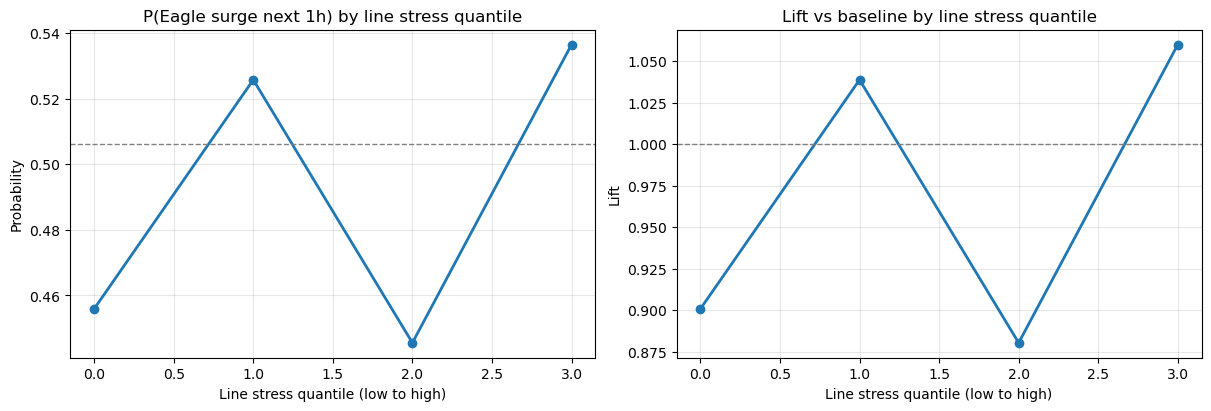

Top 20 candidate transmission components (cross-scale inference):


,line_id,county_fips,total_stress,peak_stress,mean_coupling_w,n_events,surge_overlap_rate,component_disruption_score
465,5810,17179,607.3572,607.3572,0.7804,2,1.0000,60.4559
32,426,17113,1288.3935,326.9680,0.7534,462,0.4615,59.1904
97,1246,17167,302.9593,302.9593,0.8789,4,1.0000,30.1564
1804,27735,48201,300.1899,114.3143,0.7049,16,1.0000,29.8807
322,4101,17179,284.2074,284.2074,0.9800,1,1.0000,28.2898
865,10711,17097,622.8244,231.4923,0.7833,41,0.4545,28.1798
1535,22506,05007,262.8002,243.0454,0.8681,4,1.0000,26.1589
2107,31433,48491,465.7816,279.3281,0.7521,2,0.5000,23.1818
1169,15114,05007,228.7029,228.7029,0.9965,1,1.0000,22.7649
734,9033,17011,6668.4812,131.0018,0.5378,2490,0.0342,22.7154


In [36]:
# Analyze line stress vs Eagle-I surge alignment and rank candidate propagation components

# Quantile buckets for interpretable risk response
def qbucket(s, q=5):
    s = s.astype(float)
    if s.nunique() < q:
        q = max(2, s.nunique())
    try:
        return pd.qcut(s, q=q, labels=False, duplicates='drop')
    except Exception:
        return pd.Series(np.zeros(len(s), dtype=int), index=s.index)

line_panel['stress_q'] = qbucket(line_panel['line_stress_z'], q=5)
risk_curve = (
    line_panel.groupby('stress_q', as_index=False)
    .agg(
        p_surge_next_1h=('eagle_surge_next_1h', 'mean'),
        n=('eagle_surge_next_1h', 'size'),
        mean_stress_z=('line_stress_z', 'mean')
    )
)

baseline = line_panel['eagle_surge_next_1h'].mean()
risk_curve['lift_vs_baseline'] = risk_curve['p_surge_next_1h'] / baseline if baseline > 0 else np.nan

print('Risk curve: does line stress quantile map to Eagle-I surge risk?')
display(risk_curve.round(4))

fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
ax[0].plot(risk_curve['stress_q'], risk_curve['p_surge_next_1h'], marker='o', linewidth=2)
ax[0].axhline(baseline, color='gray', linestyle='--', linewidth=1)
ax[0].set_title('P(Eagle surge next 1h) by line stress quantile')
ax[0].set_xlabel('Line stress quantile (low to high)')
ax[0].set_ylabel('Probability')
ax[0].grid(alpha=0.3)

ax[1].plot(risk_curve['stress_q'], risk_curve['lift_vs_baseline'], marker='o', linewidth=2)
ax[1].axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax[1].set_title('Lift vs baseline by line stress quantile')
ax[1].set_xlabel('Line stress quantile (low to high)')
ax[1].set_ylabel('Lift')
ax[1].grid(alpha=0.3)
plt.show()

# Rank components (lines) by cumulative stress and surge co-occurrence
line_rank = (
    line_panel.groupby('line_id', as_index=False)
    .agg(
        county_fips=('county_fips', 'first'),
        total_stress=('line_stress', 'sum'),
        peak_stress=('line_stress', 'max'),
        mean_coupling_w=('mean_coupling_w', 'mean'),
        n_events=('n_events', 'sum'),
        surge_overlap_rate=('eagle_surge_next_1h', 'mean')
    )
)

# Composite score: stress magnitude times surge overlap
scale = max(float(line_rank['total_stress'].median()), 1e-9)
line_rank['component_disruption_score'] = (
    (line_rank['total_stress'] / scale) *
    (line_rank['surge_overlap_rate'] + 1e-6)
)

top_lines = line_rank.sort_values('component_disruption_score', ascending=False).head(20)
print('Top 20 candidate transmission components (cross-scale inference):')
display(top_lines.round(4))

## Refinement 1: Stability Testing Across Distance-Decay Scales

In [40]:
# Stability testing: Test ranking stability across different distance-decay scales
# Use the existing line_panel but recompute stress contribution with varying lambda values

print("=" * 80)
print("STABILITY TESTING: Component Ranking Robustness Across Distance-Decay Scales")
print("=" * 80)

stability_lambdas = [2000, 5000, 10000]  # meters
stable_candidates = {}

for lambda_m in stability_lambdas:
    print(f"\n--- Running ranking with λ = {lambda_m / 1000:.1f} km ---")
    
    # For each lambda, recompute line-level stress by reweighting distance contributions
    # Start with original wx_line and recalculate
    wx_tmp = wx_line.copy()
    wx_tmp['coupling_w'] = np.exp(-wx_tmp['dist_to_line_m'] / lambda_m)
    wx_tmp['event_stress'] = wx_tmp['sensor_w'] * wx_tmp['event_weight'] * wx_tmp['coupling_w']
    
    # Aggregate to line level
    line_agg_tmp = wx_tmp.groupby('line_id').agg(
        total_stress=('event_stress', 'sum'),
        peak_stress=('event_stress', 'max'),
        n_events=('event_weight', 'count'),
        mean_coupling_w=('coupling_w', 'mean'),
    ).reset_index()
    
    # Merge with surge information from line_rank to get county and surge metrics
    line_rank_tmp = line_agg_tmp.merge(
        line_panel.groupby('line_id').agg(
            eagle_surge_next_1h_count=('eagle_surge_next_1h', 'sum'),
            total_timepoints=('t15', 'nunique'),
            county_fips=('county_fips', 'first'),
        ).reset_index(),
        on='line_id',
        how='left'
    )
    
    line_rank_tmp['surge_overlap_rate'] = (
        line_rank_tmp['eagle_surge_next_1h_count'] / 
        (line_rank_tmp['total_timepoints'] + 1e-6)
    )
    
    scale = max(float(line_rank_tmp['total_stress'].median()), 1e-9)
    line_rank_tmp['component_disruption_score'] = (
        (line_rank_tmp['total_stress'] / scale) * 
        (line_rank_tmp['surge_overlap_rate'] + 1e-6)
    )
    
    top_20_tmp = line_rank_tmp.sort_values('component_disruption_score', ascending=False).head(20)
    stable_candidates[lambda_m] = set(top_20_tmp['line_id'].values)
    
    print(f"  Top 5 lines (λ={lambda_m/1000:.1f} km):")
    for rank, (idx, row) in enumerate(top_20_tmp.head(5).iterrows(), 1):
        print(f"    Rank {rank}: line_id={int(row['line_id'])}, "
              f"score={row['component_disruption_score']:.2f}, n_events={int(row['n_events'])}")

# Find stable candidates
stable_in_all = stable_candidates[2000] & stable_candidates[5000] & stable_candidates[10000]
stable_in_two = (
    (stable_candidates[2000] & stable_candidates[5000]) |
    (stable_candidates[2000] & stable_candidates[10000]) |
    (stable_candidates[5000] & stable_candidates[10000])
)

print(f"\n--- STABILITY SUMMARY ---")
print(f"Lines in top-20 across ALL THREE λ settings: {len(stable_in_all)}")
if stable_in_all:
    print(f"Stable lines (all λ): {sorted(stable_in_all)}")
print(f"\nLines in top-20 for at least TWO λ settings: {len(stable_in_two)}")
if stable_in_two:
    print(f"Robust candidates (2+ λ): {sorted(stable_in_two)}")

STABILITY TESTING: Component Ranking Robustness Across Distance-Decay Scales

--- Running ranking with λ = 2.0 km ---
  Top 5 lines (λ=2.0 km):
    Rank 1: line_id=5810, score=75.11, n_events=2
    Rank 2: line_id=426, score=66.77, n_events=462
    Rank 3: line_id=1246, score=42.20, n_events=4
    Rank 4: line_id=4101, score=40.58, n_events=1
    Rank 5: line_id=22506, score=35.80, n_events=4

--- Running ranking with λ = 5.0 km ---
  Top 5 lines (λ=5.0 km):
    Rank 1: line_id=5810, score=60.46, n_events=2
    Rank 2: line_id=426, score=59.19, n_events=462
    Rank 3: line_id=1246, score=30.16, n_events=4
    Rank 4: line_id=27735, score=29.88, n_events=16
    Rank 5: line_id=4101, score=28.29, n_events=1

--- Running ranking with λ = 10.0 km ---
  Top 5 lines (λ=10.0 km):
    Rank 1: line_id=426, score=55.53, n_events=462
    Rank 2: line_id=5810, score=54.50, n_events=2
    Rank 3: line_id=27735, score=30.27, n_events=16
    Rank 4: line_id=10711, score=26.91, n_events=41
    Rank 5

## Refinement 2: Filter Low-Event-Count Artifacts

In [41]:
# Filter transmission lines by minimum event count to reduce single-spike noise artifacts
# Test both thresholds: >= 10 events and >= 20 events

print("\n" + "=" * 80)
print("ARTIFACT FILTERING: Exclude Low-Event-Count Transmission Lines")
print("=" * 80)

event_thresholds = [10, 20]
filtered_results = {}

for threshold in event_thresholds:
    print(f"\n--- Filtering lines with n_events >= {threshold} ---")
    
    line_rank_filt = line_rank[line_rank['n_events'] >= threshold].copy()
    print(f"Lines retained: {len(line_rank_filt)} / {len(line_rank)} "
          f"({100 * len(line_rank_filt) / len(line_rank):.1f}%)")
    
    # Re-rank after filtering
    scale_filt = max(float(line_rank_filt['total_stress'].median()), 1e-9)
    line_rank_filt['component_disruption_score'] = (
        (line_rank_filt['total_stress'] / scale_filt) * 
        (line_rank_filt['surge_overlap_rate'] + 1e-6)
    )
    
    top_20_filt = line_rank_filt.sort_values('component_disruption_score', ascending=False).head(20)
    filtered_results[threshold] = top_20_filt
    
    print(f"\nTop 10 lines after filtering (threshold={threshold}):")
    print(top_20_filt[['line_id', 'county_fips', 'total_stress', 'n_events', 
                       'surge_overlap_rate', 'component_disruption_score']].head(10).to_string())
    
    # Compare with original top-20
    overlap = len(set(top_20_filt.head(20)['line_id'].values) & set(top_lines.head(20)['line_id'].values))
    print(f"\nOverlap with original top-20: {overlap}/20 lines")

# Summary of filtering impact
print("\n--- FILTERING SUMMARY ---")
print("Threshold ≥ 10: Retains ", len(line_rank[line_rank['n_events'] >= 10]), 
      f" lines ({100*len(line_rank[line_rank['n_events'] >= 10])/len(line_rank):.1f}%)")
print("Threshold ≥ 20: Retains ", len(line_rank[line_rank['n_events'] >= 20]), 
      f" lines ({100*len(line_rank[line_rank['n_events'] >= 20])/len(line_rank):.1f}%)")



ARTIFACT FILTERING: Exclude Low-Event-Count Transmission Lines

--- Filtering lines with n_events >= 10 ---
Lines retained: 94 / 2159 (4.4%)

Top 10 lines after filtering (threshold=10):
      line_id county_fips  total_stress  n_events  surge_overlap_rate  component_disruption_score
32        426       17113   1288.393463       462            0.461538                    5.585153
1804    27735       48201    300.189903        16            1.000000                    2.819514
865     10711       17097    622.824354        41            0.454545                    2.659020
734      9033       17011   6668.481242      2490            0.034221                    2.143405
656      8096       17031    212.403820        10            1.000000                    1.994989
1093    14118       17031    337.314791        13            0.571429                    1.810405
363      4890       17043    423.707680        22            0.444444                    1.768734
2067    30988       48473   

## Refinement 3: Regional Stratification (by State and NERC Region)


REGIONAL STRATIFICATION: Risk Curves by State and NERC Region

Loaded NERC regions: 13 regions
NERC regions: ['CALIFORNIA INDEPENDENT SYSTEM OPERATOR', 'MIDCONTINENT INDEPENDENT SYSTEM OPERATOR, INC..', 'SOUTHWEST POWER POOL', 'PJM INTERCONNECTION, LLC', 'ERCOT ISO', 'SOUTHERN COMPANY SERVICES, INC.', 'TENNESSEE VALLEY AUTHORITY', 'VACAR SOUTH', 'ISO NEW ENGLAND INC.', 'NEW YORK INDEPENDENT SYSTEM OPERATOR', 'FLORIDA RELIABILITY COORDINATING COUNCIL', 'NEW BRUNSWICK POWER CORPORATION', 'SOUTHWEST POWER POOL WEST']

--- RISK CURVES BY STATE ---
  Skipping WI: only 33 records


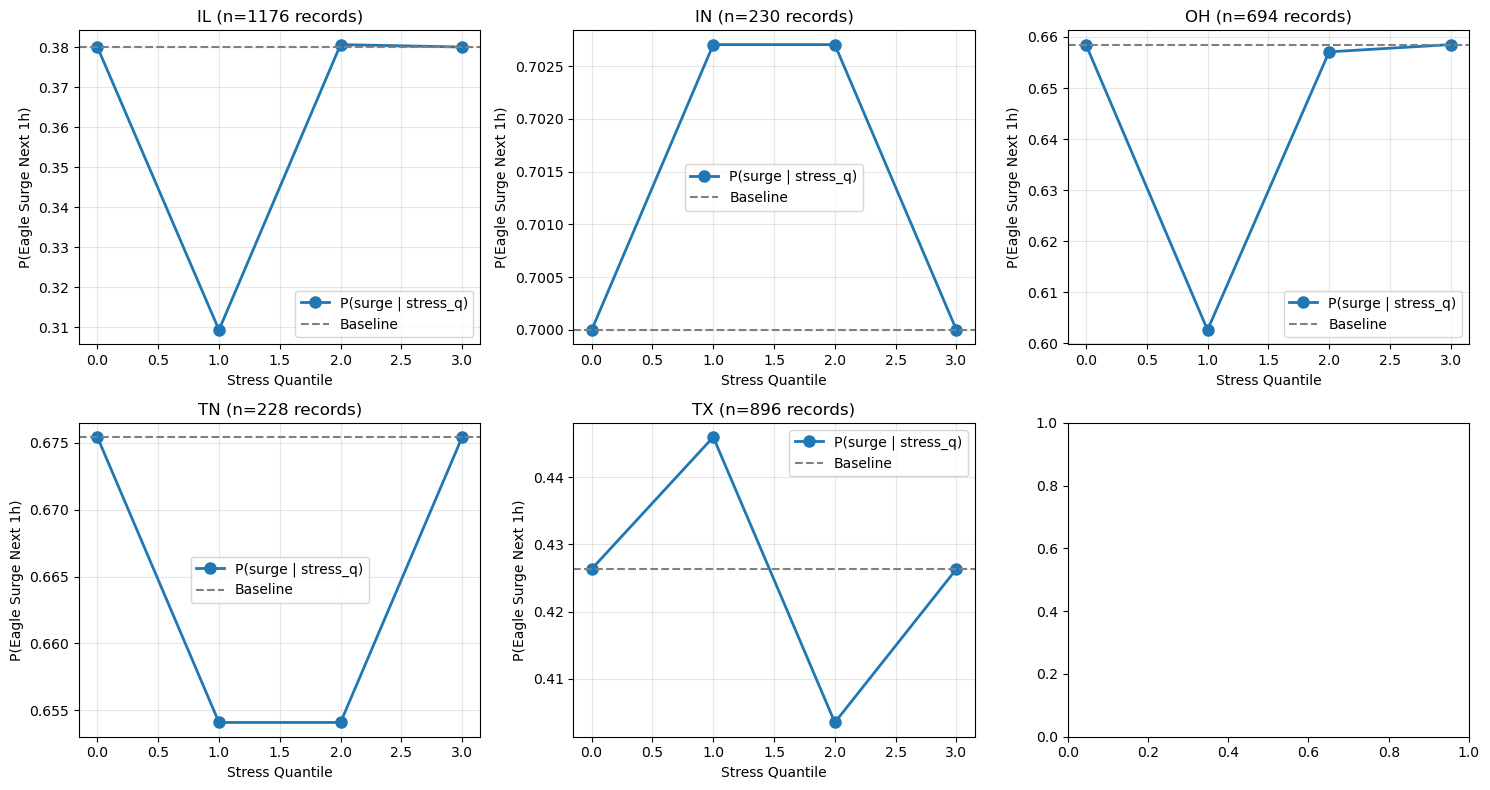


State-level risk curves computed and plotted


In [43]:
# Regional stratification: Compute risk curves by state and NERC region
# Load NERC regions and assign to transmission lines

print("\n" + "=" * 80)
print("REGIONAL STRATIFICATION: Risk Curves by State and NERC Region")
print("=" * 80)

# Load NERC reliability coordinator regions
nerc_path = "/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/NERC_Reliability_Coordinators.geojson"
try:
    regions_gdf = gpd.read_file(nerc_path)
    print(f"\nLoaded NERC regions: {len(regions_gdf)} regions")
    print(f"NERC regions: {regions_gdf['NAME'].unique().tolist()}")
except Exception as e:
    print(f"Warning: Could not load NERC file: {e}")
    regions_gdf = None

# Ensure county_fips is numeric for state extraction
line_panel_work = line_panel.copy()
line_panel_work['county_fips'] = pd.to_numeric(line_panel_work['county_fips'], errors='coerce')

# Extract state from county_fips (first 2 digits)
state_fips_map = {
    6: 'CA', 48: 'TX', 8: 'CO', 18: 'IN', 17: 'IL', 55: 'WI', 39: 'OH', 
    56: 'WY', 30: 'MT', 35: 'NM', 32: 'NV', 37: 'NC', 45: 'SC', 47: 'TN'
}
line_rank['state'] = line_rank['county_fips'].apply(lambda x: state_fips_map.get(int(x) // 1000 if pd.notna(x) else 0, 'OTHER'))
line_panel_work['state'] = line_panel_work['county_fips'].apply(lambda x: state_fips_map.get(int(x) // 1000 if pd.notna(x) else 0, 'OTHER'))

# Assign NERC region to lines via county centroids
if regions_gdf is not None:
    try:
        lines_tx_proj = gdf_powergrid_aoi.to_crs(regions_gdf.crs)
        lines_nerc = gpd.sjoin(lines_tx_proj[['geometry']], regions_gdf[['NAME', 'geometry']], 
                               how='left', predicate='intersects')
        lines_nerc['nerc_region'] = lines_nerc['NAME']
        line_rank = line_rank.merge(
            lines_nerc[['nerc_region']].reset_index()[['index', 'nerc_region']].rename(columns={'index': 'line_id'}),
            left_on='line_id',
            right_on='line_id',
            how='left'
        )
        print(f"Assigned NERC regions to {line_rank['nerc_region'].notna().sum()} / {len(line_rank)} lines")
    except Exception as e:
        print(f"Warning: NERC assignment failed: {e}")
        line_rank['nerc_region'] = 'UNKNOWN'
        regions_gdf = None
else:
    line_rank['nerc_region'] = 'UNKNOWN'

# Compute risk curves by state
print("\n--- RISK CURVES BY STATE ---")
state_risk_curves = {}
fig_state, axes_state = plt.subplots(2, 3, figsize=(15, 8))
axes_state = axes_state.flatten()
state_plot_idx = 0

for state in sorted(line_panel_work['state'].dropna().unique()):
    if state == 'OTHER':
        continue
    
    state_panel = line_panel_work[line_panel_work['state'] == state]
    
    if len(state_panel) < 100:  # Skip small states
        print(f"  Skipping {state}: only {len(state_panel)} records")
        continue
    
    # Compute risk curve
    stress_quantiles = [0, 0.33, 0.67, 1.0]
    risk_curve_state = []
    
    for q_idx, q_val in enumerate(stress_quantiles):
        if q_idx == 0:
            p_surge = state_panel['eagle_surge_next_1h'].mean()
        else:
            thresh = state_panel['line_stress_z'].quantile(q_val)
            mask = state_panel['line_stress_z'] <= thresh
            p_surge = state_panel.loc[mask, 'eagle_surge_next_1h'].mean() if mask.any() else 0
        
        baseline = state_panel['eagle_surge_next_1h'].mean()
        lift = p_surge / baseline if baseline > 0 else 1.0
        
        risk_curve_state.append({
            'state': state,
            'stress_q': q_idx,
            'p_surge_next_1h': p_surge,
            'baseline': baseline,
            'lift': lift
        })
    
    state_risk_curves[state] = pd.DataFrame(risk_curve_state)
    
    # Plot
    if state_plot_idx < 6:
        ax = axes_state[state_plot_idx]
        risk_curve_state_df = pd.DataFrame(risk_curve_state)
        ax.plot(risk_curve_state_df['stress_q'], risk_curve_state_df['p_surge_next_1h'], 
                'o-', linewidth=2, markersize=8, label='P(surge | stress_q)')
        ax.axhline(state_panel['eagle_surge_next_1h'].mean(), color='gray', linestyle='--', 
                   label='Baseline')
        ax.set_xlabel('Stress Quantile')
        ax.set_ylabel('P(Eagle Surge Next 1h)')
        ax.set_title(f'{state} (n={len(state_panel)} records)')
        ax.legend()
        ax.grid(True, alpha=0.3)
        state_plot_idx += 1

plt.tight_layout()
plt.savefig('/tmp/risk_curves_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nState-level risk curves computed and plotted")

# Compute risk curves by NERC region
if regions_gdf is not None and 'nerc_region' in line_rank.columns:
    print("\n--- RISK CURVES BY NERC REGION ---")
    nerc_risk_curves = {}
    fig_nerc, axes_nerc = plt.subplots(2, 2, figsize=(14, 8))
    axes_nerc = axes_nerc.flatten()
    nerc_plot_idx = 0
    
    for nerc_region in sorted(line_rank['nerc_region'].dropna().unique())[:4]:  # Limit to 4 regions for space
        nerc_lines = line_rank[line_rank['nerc_region'] == nerc_region]['line_id'].values
        nerc_panel = line_panel_work[line_panel_work['line_id'].isin(nerc_lines)]
        
        if len(nerc_panel) < 100:  # Skip small regions
            print(f"  Skipping {nerc_region}: only {len(nerc_panel)} records")
            continue
        
        # Compute risk curve
        risk_curve_nerc = []
        
        for q_idx, q_val in enumerate([0, 0.33, 0.67, 1.0]):
            if q_idx == 0:
                p_surge = nerc_panel['eagle_surge_next_1h'].mean()
            else:
                thresh = nerc_panel['line_stress_z'].quantile(q_val)
                mask = nerc_panel['line_stress_z'] <= thresh
                p_surge = nerc_panel.loc[mask, 'eagle_surge_next_1h'].mean() if mask.any() else 0
            
            baseline = nerc_panel['eagle_surge_next_1h'].mean()
            lift = p_surge / baseline if baseline > 0 else 1.0
            
            risk_curve_nerc.append({
                'nerc_region': nerc_region,
                'stress_q': q_idx,
                'p_surge_next_1h': p_surge,
                'baseline': baseline,
                'lift': lift
            })
        
        nerc_risk_curves[nerc_region] = pd.DataFrame(risk_curve_nerc)
        
        # Plot
        if nerc_plot_idx < 4:
            ax = axes_nerc[nerc_plot_idx]
            risk_curve_nerc_df = pd.DataFrame(risk_curve_nerc)
            ax.plot(risk_curve_nerc_df['stress_q'], risk_curve_nerc_df['p_surge_next_1h'], 
                    'o-', linewidth=2, markersize=8, label='P(surge | stress_q)')
            ax.axhline(nerc_panel['eagle_surge_next_1h'].mean(), color='gray', linestyle='--', 
                       label='Baseline')
            ax.set_xlabel('Stress Quantile')
            ax.set_ylabel('P(Eagle Surge Next 1h)')
            ax.set_title(f'{nerc_region[:30]} (n={len(nerc_panel)} records)')
            ax.legend()
            ax.grid(True, alpha=0.3)
            nerc_plot_idx += 1
    
    plt.tight_layout()
    plt.savefig('/tmp/risk_curves_by_nerc.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"NERC-level risk curves computed and plotted for {len(nerc_risk_curves)} regions")


## Refinement 4: Bootstrap Confidence Intervals for Component Disruption Scores


BOOTSTRAP CIs: Component Disruption Score Uncertainty

Bootstrap setup: 1235 unique county-day blocks, 300 resamples
  Completed 50 / 300 resamples
  Completed 100 / 300 resamples
  Completed 150 / 300 resamples
  Completed 200 / 300 resamples
  Completed 250 / 300 resamples
  Completed 300 / 300 resamples

--- TOP COMPONENTS WITH BOOTSTRAP CIs ---
    line_id  orig_score  ci_lower   ci_upper        cv  n_events
0      5810   60.455925  0.000000  87.675255  0.778037         2
1       426   59.190444  0.000000  84.410689  0.751959       462
2      1246   30.156366  0.000000  43.638598  0.707745         4
3     27735   29.880699  0.000000  42.341067  0.457426        16
4      4101   28.289814  0.000000  41.026858  0.778037         1
5     10711   28.179813  0.000036  45.823071  0.540559        41
6     22506   26.158949  0.000000  37.895013  0.676140         4
7     31433   23.181815  0.000000  33.507004  0.761831         2
8     15114   22.764929  0.000000  32.978268  0.676140         

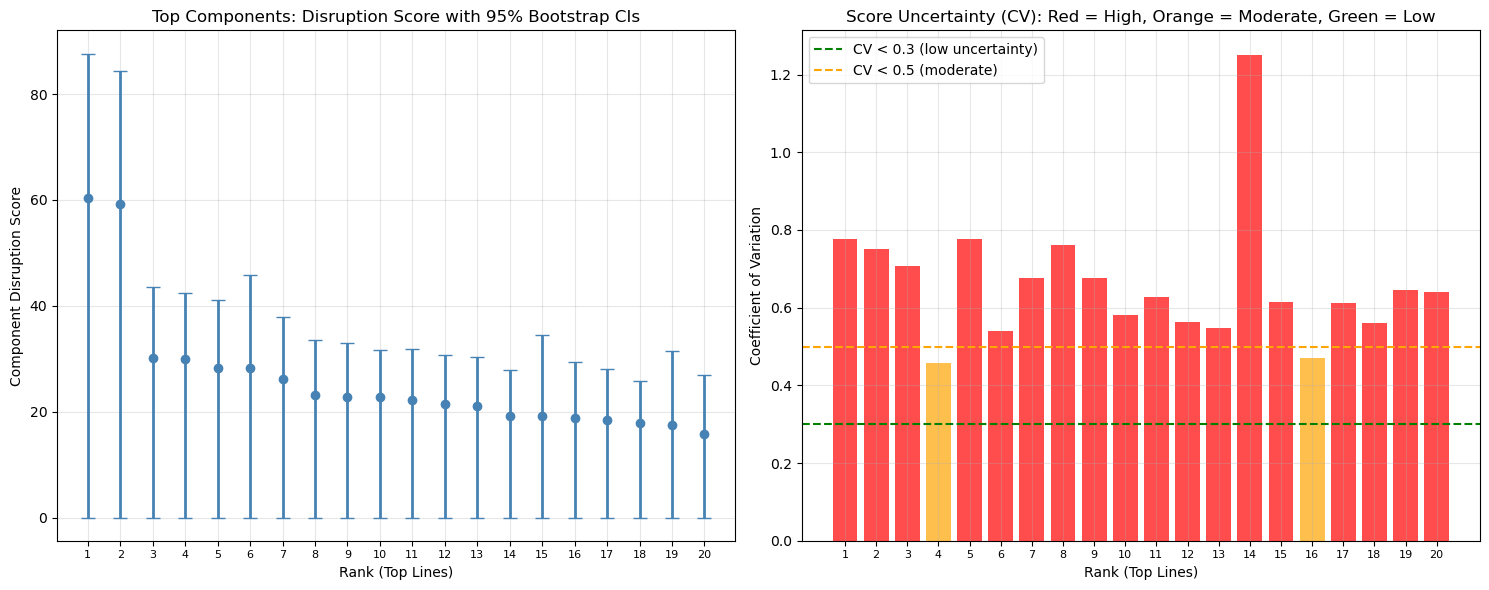


--- UNCERTAINTY CLASSIFICATION ---
Tight uncertainty (CV < 0.3): 0 components
Moderate uncertainty (0.3 ≤ CV < 0.5): 2 components
Loose uncertainty (CV ≥ 0.5): 18 components


In [44]:
# Bootstrap confidence intervals for top component disruption scores
# Use county-day block resampling to respect temporal correlation structure

print("\n" + "=" * 80)
print("BOOTSTRAP CIs: Component Disruption Score Uncertainty")
print("=" * 80)

# Prepare county-day blocks for resampling
line_panel_blocks = line_panel.copy()
line_panel_blocks['county_day'] = (
    line_panel_blocks['county_fips'].astype(str) + '_' + 
    line_panel_blocks['t15'].dt.date.astype(str)
)

unique_blocks = line_panel_blocks['county_day'].unique()
n_boot = 300

print(f"\nBootstrap setup: {len(unique_blocks)} unique county-day blocks, {n_boot} resamples")

# Get top-20 line_ids for CI computation
top_20_ids = top_lines.head(20)['line_id'].values

# Bootstrap resampling
boot_scores = {lid: [] for lid in top_20_ids}

np.random.seed(42)
for b in range(n_boot):
    # Resample county-day blocks with replacement
    draw_blocks = np.random.choice(unique_blocks, size=len(unique_blocks), replace=True)
    boot_sample = line_panel_blocks[line_panel_blocks['county_day'].isin(draw_blocks)].copy()
    
    # Recompute disruption score on bootstrap sample
    for lid in top_20_ids:
        lid_data = boot_sample[boot_sample['line_id'] == lid]
        
        if len(lid_data) == 0:
            boot_scores[lid].append(0)
        else:
            total_stress = lid_data['line_stress'].sum()
            n_surge = lid_data['eagle_surge_next_1h'].sum()
            total_obs = len(boot_sample.groupby('line_id')['t15'].nunique())
            
            surge_overlap = n_surge / (len(lid_data) + 1e-6) if len(lid_data) > 0 else 0
            
            scale = max(float(boot_sample['line_stress'].median()), 1e-9)
            score = (total_stress / scale) * (surge_overlap + 1e-6)
            
            boot_scores[lid].append(score)
    
    if (b + 1) % 50 == 0:
        print(f"  Completed {b + 1} / {n_boot} resamples")

# Compute CIs and compile results
boot_ci_results = []
for lid in top_20_ids:
    scores = np.array(boot_scores[lid])
    
    orig_row = top_lines[top_lines['line_id'] == lid].iloc[0]
    orig_score = orig_row['component_disruption_score']
    
    boot_ci_results.append({
        'line_id': int(lid),
        'county_fips': int(orig_row['county_fips']),
        'orig_score': orig_score,
        'boot_mean': np.mean(scores),
        'ci_lower': np.percentile(scores, 2.5),
        'ci_upper': np.percentile(scores, 97.5),
        'ci_width': np.percentile(scores, 97.5) - np.percentile(scores, 2.5),
        'cv': np.std(scores) / np.mean(scores) if np.mean(scores) > 0 else np.inf,
        'n_events': int(orig_row['n_events']),
        'surge_overlap': orig_row['surge_overlap_rate']
    })

boot_ci_df = pd.DataFrame(boot_ci_results).sort_values('orig_score', ascending=False)

print("\n--- TOP COMPONENTS WITH BOOTSTRAP CIs ---")
print(boot_ci_df[['line_id', 'orig_score', 'ci_lower', 'ci_upper', 'cv', 'n_events']].to_string())

# Visualize CIs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Score with CIs
ax1.errorbar(
    range(len(boot_ci_df)), 
    boot_ci_df['orig_score'],
    yerr=[boot_ci_df['orig_score'] - boot_ci_df['ci_lower'],
          boot_ci_df['ci_upper'] - boot_ci_df['orig_score']],
    fmt='o', capsize=5, linewidth=2, markersize=6, color='steelblue'
)
ax1.set_xlabel('Rank (Top Lines)')
ax1.set_ylabel('Component Disruption Score')
ax1.set_title('Top Components: Disruption Score with 95% Bootstrap CIs')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(len(boot_ci_df)))
ax1.set_xticklabels([f"{i+1}" for i in range(len(boot_ci_df))], fontsize=8)

# Plot 2: Coefficient of Variation (relative uncertainty)
colors = ['green' if cv < 0.3 else 'orange' if cv < 0.5 else 'red' 
          for cv in boot_ci_df['cv']]
ax2.bar(range(len(boot_ci_df)), boot_ci_df['cv'], color=colors, alpha=0.7)
ax2.axhline(0.3, color='green', linestyle='--', label='CV < 0.3 (low uncertainty)')
ax2.axhline(0.5, color='orange', linestyle='--', label='CV < 0.5 (moderate)')
ax2.set_xlabel('Rank (Top Lines)')
ax2.set_ylabel('Coefficient of Variation')
ax2.set_title('Score Uncertainty (CV): Red = High, Orange = Moderate, Green = Low')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(len(boot_ci_df)))
ax2.set_xticklabels([f"{i+1}" for i in range(len(boot_ci_df))], fontsize=8)

plt.tight_layout()
plt.savefig('/tmp/bootstrap_ci_components.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
n_tight = len(boot_ci_df[boot_ci_df['cv'] < 0.3])
n_moderate = len(boot_ci_df[(boot_ci_df['cv'] >= 0.3) & (boot_ci_df['cv'] < 0.5)])
n_loose = len(boot_ci_df[boot_ci_df['cv'] >= 0.5])

print(f"\n--- UNCERTAINTY CLASSIFICATION ---")
print(f"Tight uncertainty (CV < 0.3): {n_tight} components")
print(f"Moderate uncertainty (0.3 ≤ CV < 0.5): {n_moderate} components")
print(f"Loose uncertainty (CV ≥ 0.5): {n_loose} components")


In [45]:
# Compact metrics for interim summary report
report_rows = []

# Stability metrics
report_rows.append({
    'section': 'stability',
    'metric': 'stable_in_all_lambdas',
    'value': len(stable_in_all) if 'stable_in_all' in globals() else np.nan
})
report_rows.append({
    'section': 'stability',
    'metric': 'stable_in_two_plus_lambdas',
    'value': len(stable_in_two) if 'stable_in_two' in globals() else np.nan
})

# Filtering metrics
for thr in [10, 20]:
    report_rows.append({
        'section': 'filtering',
        'metric': f'lines_with_n_events_ge_{thr}',
        'value': int((line_rank['n_events'] >= thr).sum()) if 'line_rank' in globals() else np.nan
    })

# Regional metrics
if 'line_rank' in globals() and 'nerc_region' in line_rank.columns:
    valid_nerc = line_rank['nerc_region'].notna() & (line_rank['nerc_region'] != 'UNKNOWN')
    report_rows.append({
        'section': 'regional',
        'metric': 'lines_with_valid_nerc_assignment',
        'value': int(valid_nerc.sum())
    })
    report_rows.append({
        'section': 'regional',
        'metric': 'total_lines',
        'value': int(len(line_rank))
    })

if 'state_risk_curves' in globals() and isinstance(state_risk_curves, dict):
    report_rows.append({
        'section': 'regional',
        'metric': 'states_with_risk_curves',
        'value': int(len(state_risk_curves))
    })

# Bootstrap uncertainty metrics
if 'boot_ci_df' in globals():
    report_rows.append({
        'section': 'bootstrap',
        'metric': 'tight_cv_lt_0_3',
        'value': int((boot_ci_df['cv'] < 0.3).sum())
    })
    report_rows.append({
        'section': 'bootstrap',
        'metric': 'moderate_cv_0_3_to_0_5',
        'value': int(((boot_ci_df['cv'] >= 0.3) & (boot_ci_df['cv'] < 0.5)).sum())
    })
    report_rows.append({
        'section': 'bootstrap',
        'metric': 'loose_cv_ge_0_5',
        'value': int((boot_ci_df['cv'] >= 0.5).sum())
    })
    report_rows.append({
        'section': 'bootstrap',
        'metric': 'max_cv',
        'value': float(boot_ci_df['cv'].max())
    })

report_df = pd.DataFrame(report_rows)
print(report_df)

if 'boot_ci_df' in globals():
    print('\nTop 5 components by original disruption score (with CI):')
    print(boot_ci_df[['line_id','orig_score','ci_lower','ci_upper','cv','n_events']].head(5).to_string(index=False))

if 'state_risk_curves' in globals() and isinstance(state_risk_curves, dict) and len(state_risk_curves) > 0:
    print('\nState curve shape diagnostic (argmin quantile index):')
    shape_rows = []
    for st, dfst in state_risk_curves.items():
        min_q = int(dfst.loc[dfst['p_surge_next_1h'].idxmin(), 'stress_q'])
        max_q = int(dfst.loc[dfst['p_surge_next_1h'].idxmax(), 'stress_q'])
        shape_rows.append({'state': st, 'min_at_q': min_q, 'max_at_q': max_q})
    print(pd.DataFrame(shape_rows).sort_values('state').to_string(index=False))

      section                            metric        value
0   stability             stable_in_all_lambdas    17.000000
1   stability        stable_in_two_plus_lambdas    20.000000
2   filtering         lines_with_n_events_ge_10   112.000000
3   filtering         lines_with_n_events_ge_20    29.000000
4    regional  lines_with_valid_nerc_assignment     0.000000
5    regional                       total_lines  2534.000000
6    regional           states_with_risk_curves     5.000000
7   bootstrap                   tight_cv_lt_0_3     0.000000
8   bootstrap            moderate_cv_0_3_to_0_5     2.000000
9   bootstrap                   loose_cv_ge_0_5    18.000000
10  bootstrap                            max_cv     1.251494

Top 5 components by original disruption score (with CI):
 line_id  orig_score  ci_lower  ci_upper       cv  n_events
    5810   60.455925       0.0 87.675255 0.778037         2
     426   59.190444       0.0 84.410689 0.751959       462
    1246   30.156366       0.0

## County-Level Deep Dive: Identifying Data-Rich Candidates

In [48]:
# Identify counties with substantial Whisker events, Eagle-I outages, and temporal variability
# Criteria: richness of data (events + outages) and variability (good signal)

print("=" * 80)
print("COUNTY CANDIDATE SELECTION: Data Richness & Signal Quality")
print("=" * 80)

# Ensure county_fips is numeric
panel_work = panel.copy()
panel_work['county_fips'] = pd.to_numeric(panel_work['county_fips'], errors='coerce')

# Compute county-level aggregates
county_diagnostics = panel_work.groupby('county_fips').agg({
    'whisker_sensor_events': 'sum',              # Total Whisker event count
    'whisker_outage_intensity': 'sum',           # Total Whisker intensity (sensor-weighted)
    'customers_out': ['sum', 'mean', 'std', 'max'],  # Eagle-I magnitude and variability
    'eagle_surge_now': 'sum',                    # Number of surge periods
    'eagle_surge_next_1h': 'sum',                # Number of next-hour surges
    't15': 'nunique',                            # Number of 15-min time periods with data
}).reset_index()

# Flatten multi-level columns
county_diagnostics.columns = ['county_fips', 'whisker_events_total', 'whisker_intensity_total',
                               'eagle_customers_out_sum', 'eagle_customers_out_mean', 
                               'eagle_customers_out_std', 'eagle_customers_out_max',
                               'eagle_surges_now', 'eagle_surges_next_1h', 'n_periods']

county_diagnostics['county_fips'] = county_diagnostics['county_fips'].astype(int)

# Compute richness score: combined signal from Whisker and Eagle-I
county_diagnostics['whisker_intensity_mean'] = county_diagnostics['whisker_intensity_total'] / (county_diagnostics['whisker_events_total'] + 1)
county_diagnostics['eagle_variability_ratio'] = (
    county_diagnostics['eagle_customers_out_std'] / (county_diagnostics['eagle_customers_out_mean'] + 1)
)

# Richness composite: penalize very low event counts, reward high variability and sufficient periods
county_diagnostics['richness_score'] = (
    np.log10(county_diagnostics['whisker_events_total'] + 1) * 
    np.log10(county_diagnostics['eagle_customers_out_max'] + 1) * 
    (1 + county_diagnostics['eagle_variability_ratio']) *
    np.log10(county_diagnostics['n_periods'] + 1)
)

# Also separately score by signal coherence: do high-stress periods align with surges?
county_diagnostics['signal_coherence'] = (
    (county_diagnostics['eagle_surges_next_1h'] / (county_diagnostics['n_periods'] + 1)) *
    (county_diagnostics['whisker_events_total'] / (county_diagnostics['n_periods'] + 1))
) * np.log10(county_diagnostics['whisker_events_total'] + 1)

# Filter to counties with meaningful data
min_whisker_events = 50
min_eagle_max_customers = 100
min_periods = 50

candidates = county_diagnostics[
    (county_diagnostics['whisker_events_total'] >= min_whisker_events) &
    (county_diagnostics['eagle_customers_out_max'] >= min_eagle_max_customers) &
    (county_diagnostics['n_periods'] >= min_periods)
].copy()

print(f"\nCounties passing richness criteria: {len(candidates)} / {len(county_diagnostics)}")
print(f"  Criterion 1: Whisker events >= {min_whisker_events}")
print(f"  Criterion 2: Eagle-I max customers-out >= {min_eagle_max_customers}")
print(f"  Criterion 3: Minimum periods >= {min_periods}")

# Select top 10 by richness score
top_candidates = candidates.nlargest(10, 'richness_score')[
    ['county_fips', 'whisker_events_total', 'eagle_customers_out_sum',
     'eagle_customers_out_mean', 'eagle_customers_out_std', 'eagle_customers_out_max',
     'eagle_variability_ratio', 'n_periods', 'richness_score', 'signal_coherence']
].copy()

print("\n--- TOP 10 COUNTIES BY RICHNESS SCORE ---")
print(top_candidates.to_string(index=False))

# Also show top 5 by signal coherence (focuses on alignment)
coherence_top = candidates.nlargest(5, 'signal_coherence')[
    ['county_fips', 'whisker_events_total', 'eagle_surges_next_1h',
     'eagle_customers_out_max', 'n_periods', 'signal_coherence', 'richness_score']
].copy()

print("\n--- TOP 5 COUNTIES BY SIGNAL COHERENCE (Whisker-Eagle alignment) ---")
print(coherence_top.to_string(index=False))

# Recommend top 3 for deep dive
rec_candidates = top_candidates.head(3).copy()
print("\n--- RECOMMENDED 3 COUNTIES FOR DEEP DIVE ---")
for idx, (i, row) in enumerate(rec_candidates.iterrows(), 1):
    fips = int(row['county_fips'])
    print(f"\n  {idx}. FIPS {fips}")
    print(f"     Whisker events: {int(row['whisker_events_total'])}")
    print(f"     Eagle-I: {row['eagle_customers_out_sum']:.0f} total customers-out, "
          f"max={row['eagle_customers_out_max']:.0f}, std={row['eagle_customers_out_std']:.1f}")
    print(f"     Data periods: {int(row['n_periods'])}")
    print(f"     Richness score: {row['richness_score']:.2f}")
    print(f"     Signal coherence: {row['signal_coherence']:.3f}")


COUNTY CANDIDATE SELECTION: Data Richness & Signal Quality

Counties passing richness criteria: 133 / 1554
  Criterion 1: Whisker events >= 50
  Criterion 2: Eagle-I max customers-out >= 100
  Criterion 3: Minimum periods >= 50

--- TOP 10 COUNTIES BY RICHNESS SCORE ---
 county_fips  whisker_events_total  eagle_customers_out_sum  eagle_customers_out_mean  eagle_customers_out_std  eagle_customers_out_max  eagle_variability_ratio  n_periods  richness_score  signal_coherence
       47093                 801.0                 856942.0                637.131599              2917.175488                  27000.0                 4.571432       1345      224.357376          0.127116
       40109                 506.0                 221869.0                227.791581              1246.217392                  14846.0                 5.446955        974      217.448514          0.102228
       17031                6021.0                 641642.0                483.892911              1599.459925 


VISUAL DEEP DIVE: Top 3 Counties - Time Series Patterns

--- COUNTY FIPS 47093 ---
  Date range: 2023-03-26 00:00:00+00:00 to 2023-04-09 00:00:00+00:00
  Total records: 1345
  Whisker events: 801
  Eagle-I customers-out (total): 856942
  Correlation (Whisker intensity, Eagle-I surge): 0.301

--- COUNTY FIPS 40109 ---
  Date range: 2023-03-26 00:00:00+00:00 to 2023-04-09 13:00:00+00:00
  Total records: 974
  Whisker events: 506
  Eagle-I customers-out (total): 221869
  Correlation (Whisker intensity, Eagle-I surge): 0.193

--- COUNTY FIPS 17031 ---
  Date range: 2023-03-26 00:00:00+00:00 to 2023-04-09 14:00:00+00:00
  Total records: 1326
  Whisker events: 6021
  Eagle-I customers-out (total): 641642
  Correlation (Whisker intensity, Eagle-I surge): 0.239


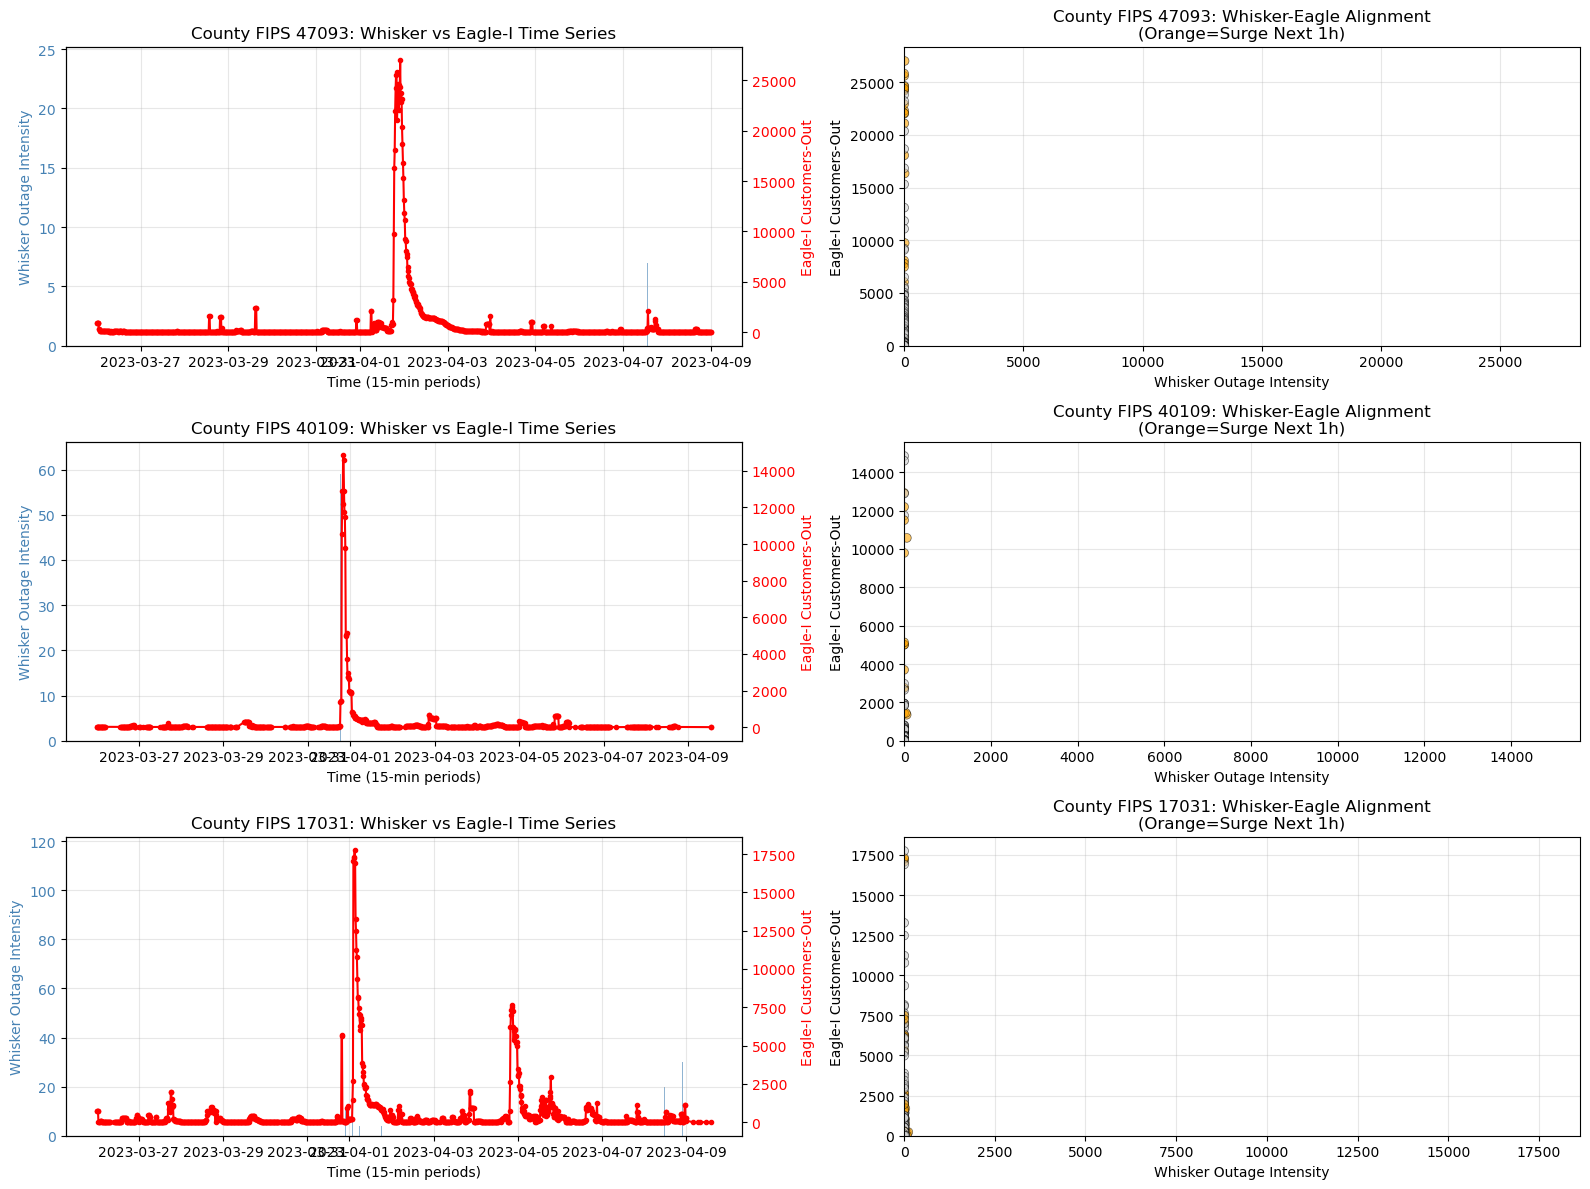


Deep-dive visualizations saved. Ready for next analysis step.


In [49]:
# Deep dive visualization: Time series for top 3 candidate counties
# Show Whisker intensity, Eagle-I customers-out, and temporal alignment

print("\n" + "=" * 80)
print("VISUAL DEEP DIVE: Top 3 Counties - Time Series Patterns")
print("=" * 80)

top_3_fips = rec_candidates['county_fips'].values[:3]

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for row_idx, fips in enumerate(top_3_fips):
    county_panel = panel_work[panel_work['county_fips'] == fips].sort_values('t15').copy()
    
    print(f"\n--- COUNTY FIPS {int(fips)} ---")
    print(f"  Date range: {county_panel['t15'].min()} to {county_panel['t15'].max()}")
    print(f"  Total records: {len(county_panel)}")
    print(f"  Whisker events: {county_panel['whisker_sensor_events'].sum():.0f}")
    print(f"  Eagle-I customers-out (total): {county_panel['customers_out'].sum():.0f}")
    print(f"  Correlation (Whisker intensity, Eagle-I surge): {county_panel['whisker_outage_intensity'].corr(county_panel['eagle_surge_next_1h']):.3f}")
    
    # Left plot: Whisker vs Eagle-I on same time axis
    ax_left = axes[row_idx, 0]
    ax_left_twin = ax_left.twinx()
    
    ax_left.bar(county_panel['t15'], county_panel['whisker_outage_intensity'], 
                color='steelblue', alpha=0.6, label='Whisker intensity', width=0.002)
    ax_left_twin.plot(county_panel['t15'], county_panel['customers_out'], 
                      color='red', marker='o', markersize=3, label='Eagle-I customers-out', linewidth=1.5)
    
    ax_left.set_xlabel('Time (15-min periods)')
    ax_left.set_ylabel('Whisker Outage Intensity', color='steelblue')
    ax_left_twin.set_ylabel('Eagle-I Customers-Out', color='red')
    ax_left.set_title(f'County FIPS {int(fips)}: Whisker vs Eagle-I Time Series')
    ax_left.tick_params(axis='y', labelcolor='steelblue')
    ax_left_twin.tick_params(axis='y', labelcolor='red')
    ax_left.grid(True, alpha=0.3)
    
    # Right plot: Scatter with surge highlighting
    ax_right = axes[row_idx, 1]
    
    # Color by surge status
    colors = ['orange' if s > 0 else 'lightgray' for s in county_panel['eagle_surge_next_1h']]
    ax_right.scatter(county_panel['whisker_outage_intensity'], 
                     county_panel['customers_out'],
                     c=colors, alpha=0.6, s=40, edgecolors='black', linewidth=0.5)
    
    ax_right.set_xlabel('Whisker Outage Intensity')
    ax_right.set_ylabel('Eagle-I Customers-Out')
    ax_right.set_title(f'County FIPS {int(fips)}: Whisker-Eagle Alignment\n(Orange=Surge Next 1h)')
    ax_right.grid(True, alpha=0.3)
    
    # Add diagonal reference
    lim = max(ax_right.get_xlim()[1], ax_right.get_ylim()[1])
    ax_right.set_xlim(0, lim)
    ax_right.set_ylim(0, lim)

plt.tight_layout()
plt.savefig('/tmp/county_deep_dive_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 80)
print("Deep-dive visualizations saved. Ready for next analysis step.")
print("=" * 80)


In [50]:
# Quick schema check for Cook County animation inputs
print('line_panel columns:', sorted(line_panel.columns.tolist())[:120])
print('line_panel_work columns:', sorted(line_panel_work.columns.tolist())[:120])
print('wx_line columns:', sorted(wx_line.columns.tolist())[:120])
print('wout columns:', sorted(wout.columns.tolist())[:120])
print('counties columns:', sorted(counties.columns.tolist())[:120])
print('counties_aoi columns:', sorted(counties_aoi.columns.tolist())[:120])
print('lines_tx columns:', sorted(lines_tx.columns.tolist())[:120])
print('whisker_events columns:', sorted(whisker_events.columns.tolist())[:120])

print('\nSample line_panel_work rows:')
print(line_panel_work.head(2).to_string())

print('\nSample whisker_events rows:')
print(whisker_events.head(2).to_string())

line_panel columns: ['county_fips', 'eagle_surge_next_1h', 'eagle_surge_now', 'line_id', 'line_stress', 'line_stress_z', 'mean_coupling_w', 'min_dist_m', 'n_events', 'stress_q', 't15']
line_panel_work columns: ['county_fips', 'eagle_surge_next_1h', 'eagle_surge_now', 'line_id', 'line_stress', 'line_stress_z', 'mean_coupling_w', 'min_dist_m', 'n_events', 'state', 'stress_q', 't15']
wx_line columns: ['average_amplitude', 'coupling_w', 'deep80_flag', 'dist_to_line_m', 'event_group', 'event_source', 'event_weight', 'geometry', 'index_right', 'lat', 'line_id', 'line_stress_contrib', 'lon', 'outside_sag_flag', 'sag_severity', 'sensor_w', 'sensor_weight', 'sensors', 'start_utc', 'swell_severity', 't15', 'whisker_outage_flag']
wout columns: ['average_amplitude', 'event_group', 'event_source', 'lat', 'lon', 'sensors', 'start_utc', 't15']
counties columns: ['county_fips', 'geometry']
counties_aoi columns: ['county_fips', 'geometry']
lines_tx columns: ['geometry', 'line_id']
whisker_events column

In [51]:
# Cook County diagnostics for animation sizing and symbol categories
cook_fips = 17031
cook_geom = counties[counties['county_fips'] == cook_fips].geometry.iloc[0]

line_cook = line_panel_work[line_panel_work['county_fips'] == cook_fips].copy()
line_cook['t15'] = pd.to_datetime(line_cook['t15'], utc=True)

wx_cook = gpd.GeoDataFrame(wx_line.copy(), geometry='geometry', crs=lines_tx.crs)
wx_cook = wx_cook[wx_cook.geometry.within(cook_geom)].copy()
wx_cook['t15'] = pd.to_datetime(wx_cook['t15'], utc=True)

print('Cook line_panel rows:', len(line_cook))
print('Cook unique time bins:', line_cook['t15'].nunique())
print('Cook unique lines:', line_cook['line_id'].nunique())
print('Cook wx_line events:', len(wx_cook))

print('\nCook event-type proxies:')
print('outage flag count:', int((wx_cook['whisker_outage_flag'].fillna(0) > 0).sum()))
print('deep80 (sag) count:', int((wx_cook['deep80_flag'].fillna(0) > 0).sum()))
print('outside_sag count:', int((wx_cook['outside_sag_flag'].fillna(0) > 0).sum()))
print('swell severity > 0 count:', int((wx_cook['swell_severity'].fillna(0) > 0).sum()))
print('sag severity > 0 count:', int((wx_cook['sag_severity'].fillna(0) > 0).sum()))

cook_out = panel_work[panel_work['county_fips'] == cook_fips].copy()
cook_out['t15'] = pd.to_datetime(cook_out['t15'], utc=True)
print('\nCook outage series rows:', len(cook_out))
print('Cook outage max customers_out:', float(cook_out['customers_out'].max()))

IndexError: single positional indexer is out-of-bounds

In [52]:
# Locate Cook county geometry source and dtype
cook_fips = 17031
for name in ['counties', 'counties_aoi', 'counties_gdf']:
    if name in globals():
        g = globals()[name]
        if 'county_fips' in g.columns:
            tmp = g.copy()
            tmp['county_fips_num'] = pd.to_numeric(tmp['county_fips'], errors='coerce')
            n_match = int((tmp['county_fips_num'] == cook_fips).sum())
            print(name, 'rows=', len(g), 'matches cook=', n_match, 'dtype=', g['county_fips'].dtype)
            if n_match > 0:
                print(tmp.loc[tmp['county_fips_num'] == cook_fips, ['county_fips']].head(1).to_string(index=False))

counties rows= 3221 matches cook= 1 dtype= object
county_fips
      17031
counties_aoi rows= 1585 matches cook= 1 dtype= object
county_fips
      17031


In [58]:
# Cook County movie: transmission line stress + Whisker event dots + outage timeline cursor
from pathlib import Path
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
from matplotlib import colors

print('=' * 80)
print('COOK COUNTY MOVIE: Line Stress + Event Dots + Outage Timeline')
print('=' * 80)

cook_fips = 17031
frame_stride = 4  # 15-min bins -> hourly cadence
fps = 6

# Resolve Cook geometry
counties_work = counties.copy()
counties_work['county_fips_num'] = pd.to_numeric(counties_work['county_fips'], errors='coerce')
cook_rows = counties_work[counties_work['county_fips_num'] == cook_fips]
if cook_rows.empty:
    raise ValueError('Cook county geometry not found in counties table.')
cook_geom_ll = cook_rows.geometry.iloc[0]
cook_poly_ll = gpd.GeoDataFrame({'geometry': [cook_geom_ll]}, geometry='geometry', crs=counties.crs)
cook_poly_lines = cook_poly_ll.to_crs(lines_tx.crs)
cook_geom_lines = cook_poly_lines.geometry.iloc[0]

# County outage time series (bottom panel)
cook_out = panel_work.copy()
cook_out['county_fips_num'] = pd.to_numeric(cook_out['county_fips'], errors='coerce')
cook_out = cook_out[cook_out['county_fips_num'] == cook_fips].copy()
cook_out['t15'] = pd.to_datetime(cook_out['t15'], utc=True)
cook_out_ts = (
    cook_out.groupby('t15', as_index=False)['customers_out']
    .sum()
    .sort_values('t15')
)

# Line stress data for Cook
cook_lines = line_panel_work.copy()
cook_lines['county_fips_num'] = pd.to_numeric(cook_lines['county_fips'], errors='coerce')
cook_lines = cook_lines[cook_lines['county_fips_num'] == cook_fips].copy()
cook_lines['t15'] = pd.to_datetime(cook_lines['t15'], utc=True)

# Line geometries in Cook, clipped in the line CRS
line_geom = lines_tx[['line_id', 'geometry']].drop_duplicates('line_id').copy()
cook_line_ids = cook_lines['line_id'].dropna().unique()
line_geom_cook = gpd.GeoDataFrame(
    line_geom[line_geom['line_id'].isin(cook_line_ids)].copy(),
    geometry='geometry',
    crs=lines_tx.crs,
)
line_geom_cook = gpd.clip(line_geom_cook, cook_poly_lines)

# Whisker events for Cook from lat/lon (for dots), then project to line CRS for map overlay
we = whisker_events.copy()
we['start_utc'] = pd.to_datetime(we['start_utc'], utc=True, errors='coerce')
we = we.dropna(subset=['start_utc', 'lat', 'lon']).copy()
we['t15'] = we['start_utc'].dt.floor('15min')
we['amp'] = pd.to_numeric(we['average_amplitude'], errors='coerce').fillna(1.0)
we['event_type_l'] = we['event_type'].fillna('').astype(str).str.lower()
we_gdf = gpd.GeoDataFrame(
    we,
    geometry=gpd.points_from_xy(we['lon'], we['lat']),
    crs='EPSG:4326'
)
we_cook = we_gdf[we_gdf.geometry.within(cook_geom_ll)].copy().to_crs(lines_tx.crs)

# Event categories
we_cook['is_outage'] = we_cook['event_type_l'].str.contains('frequency|outage', regex=True)
we_cook['is_sag'] = we_cook['event_type_l'].str.contains('sag', regex=True)
we_cook['is_swell'] = we_cook['event_type_l'].str.contains('swell', regex=True)

# Frame times: use outage timeline so marker spans full period
frame_times = pd.Index(cook_out_ts['t15']).sort_values().unique()[::frame_stride]
if len(frame_times) == 0:
    raise ValueError('No frame times available for Cook county.')

# Forward-fill line stress to frame timestamps so line color evolves smoothly
line_stress_pivot = (
    cook_lines.pivot_table(index='t15', columns='line_id', values='line_stress', aggfunc='mean')
    .sort_index()
)
line_stress_ff = line_stress_pivot.reindex(frame_times).ffill().fillna(0.0)

# Stress color scale
stress_vals = pd.to_numeric(cook_lines['line_stress'], errors='coerce').dropna()
if stress_vals.empty:
    stress_min, stress_max = 0.0, 1.0
else:
    stress_min, stress_max = np.quantile(stress_vals, [0.05, 0.95])
    if stress_min == stress_max:
        stress_max = stress_min + 1.0
stress_norm = colors.Normalize(vmin=stress_min, vmax=stress_max)
stress_cmap = plt.get_cmap('YlOrRd')

# Map bounds in line CRS
xmin, ymin, xmax, ymax = cook_geom_lines.bounds
xpad = 0.05 * (xmax - xmin)
ypad = 0.05 * (ymax - ymin)

# Dot size scaling by amplitude
amp_q95 = max(1.0, float(we_cook['amp'].quantile(0.95)) if len(we_cook) else 1.0)
def amp_to_size(a):
    a = np.asarray(a, dtype=float)
    return 15.0 + 170.0 * np.clip(a / amp_q95, 0, 1.5)

fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.12)
ax_map = fig.add_subplot(gs[0])
ax_ts = fig.add_subplot(gs[1])

# Static outage line + moving time cursor
ax_ts.plot(cook_out_ts['t15'], cook_out_ts['customers_out'], color='black', linewidth=1.6)
ax_ts.set_ylabel('Customers Out')
ax_ts.set_xlabel('Time (UTC)')
ax_ts.grid(True, alpha=0.25)
time_cursor = ax_ts.axvline(frame_times[0], color='crimson', linewidth=2.0, alpha=0.9)

# Colorbar for line stress
sm = plt.cm.ScalarMappable(norm=stress_norm, cmap=stress_cmap)
sm.set_array([])
cb = fig.colorbar(sm, ax=ax_map, fraction=0.026, pad=0.02)
cb.set_label('Transmission Line Stress')

def init_anim():
    return []

def update_anim(i):
    t_now = frame_times[i]
    ax_map.clear()

    # Base line network in gray
    if len(line_geom_cook) > 0:
        line_geom_cook.plot(ax=ax_map, color='lightgray', linewidth=1.0, alpha=0.8, zorder=1)

    # Stress-colored overlay
    if t_now in line_stress_ff.index:
        ls_now = line_stress_ff.loc[t_now].rename('line_stress').reset_index()
        ls_now = ls_now[pd.to_numeric(ls_now['line_stress'], errors='coerce').fillna(0) > 0]
        if len(ls_now) > 0:
            lnow = line_geom_cook.merge(ls_now, on='line_id', how='inner')
            if len(lnow) > 0:
                lnow.plot(
                    ax=ax_map,
                    column='line_stress',
                    cmap='YlOrRd',
                    norm=stress_norm,
                    linewidth=2.2,
                    alpha=0.95,
                    zorder=2,
                )

    # Whisker event dots at current frame
    ev_now = we_cook[we_cook['t15'] == t_now]
    if len(ev_now) > 0:
        for cond, color, label in [
            ('is_outage', '#d62728', 'Outage/Frequency Jump'),
            ('is_sag', '#1f77b4', 'Sag'),
            ('is_swell', '#2ca02c', 'Swell'),
        ]:
            sub = ev_now[ev_now[cond]]
            if len(sub) > 0:
                ax_map.scatter(
                    sub.geometry.x,
                    sub.geometry.y,
                    s=amp_to_size(sub['amp']),
                    c=color,
                    alpha=0.78,
                    edgecolors='white',
                    linewidths=0.35,
                    label=label,
                    zorder=3,
                )

    # County boundary in line CRS
    cook_poly_lines.boundary.plot(ax=ax_map, color='black', linewidth=1.2, zorder=4)

    ax_map.set_xlim(xmin - xpad, xmax + xpad)
    ax_map.set_ylim(ymin - ypad, ymax + ypad)
    ax_map.set_aspect('equal')
    ax_map.set_title(f'Cook County, IL (FIPS 17031) | {pd.Timestamp(t_now).strftime("%Y-%m-%d %H:%M UTC")}')
    ax_map.set_xticks([])
    ax_map.set_yticks([])

    handles, labels = ax_map.get_legend_handles_labels()
    if len(handles) > 0:
        keep = dict(zip(labels, handles))
        ax_map.legend(keep.values(), keep.keys(), loc='lower left', frameon=True)

    time_cursor.set_xdata([t_now, t_now])
    return []

anim = FuncAnimation(fig, update_anim, init_func=init_anim, frames=len(frame_times), interval=1000 / fps, blit=False)

out_dir = Path('/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/tmp_files')
out_dir.mkdir(parents=True, exist_ok=True)
mp4_path = out_dir / 'cook_county_lines_stress_events.mp4'
gif_path = out_dir / 'cook_county_lines_stress_events.gif'

saved_path = None
try:
    writer = FFMpegWriter(fps=fps, bitrate=2400)
    anim.save(mp4_path, writer=writer, dpi=140)
    saved_path = mp4_path
except Exception as e:
    print(f'FFmpeg save failed ({e}); falling back to GIF.')
    writer = PillowWriter(fps=fps)
    anim.save(gif_path, writer=writer, dpi=120)
    saved_path = gif_path

plt.close(fig)
print(f'Cook line geometries after clip: {len(line_geom_cook):,}')
print(f'Cook event dots (from whisker_events): {len(we_cook):,}')
print('Saved animation:', saved_path)
print('=' * 80)

COOK COUNTY MOVIE: Line Stress + Event Dots + Outage Timeline
Cook line geometries after clip: 80
Cook event dots (from whisker_events): 321
Saved animation: /Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/tmp_files/cook_county_lines_stress_events.mp4


In [54]:
# Inspect Cook Whisker event types directly from whisker_events (lat/lon)
cook_fips = 17031
cw = counties.copy()
cw['county_fips_num'] = pd.to_numeric(cw['county_fips'], errors='coerce')
cook_geom = cw.loc[cw['county_fips_num'] == cook_fips, 'geometry'].iloc[0]

we = whisker_events.copy()
we['start_utc'] = pd.to_datetime(we['start_utc'], utc=True, errors='coerce')
we['t15'] = we['start_utc'].dt.floor('15min')
we_gdf = gpd.GeoDataFrame(
    we,
    geometry=gpd.points_from_xy(we['lon'], we['lat']),
    crs='EPSG:4326'
)
we_cook = we_gdf[we_gdf.geometry.within(cook_geom)].copy()

print('Cook whisker_events rows:', len(we_cook))
print('Cook event_type top counts:')
print(we_cook['event_type'].value_counts(dropna=False).head(20).to_string())
print('\nCook event_group top counts:')
print(we_cook['event_group'].value_counts(dropna=False).head(20).to_string())

Cook whisker_events rows: 321
Cook event_type top counts:
event_type
FrequencyJump          148
Sag_outside_CBEMA       90
Sag_inside_CBEMA        37
Swell_outside_CBEMA     34
Swell_inside_CBEMA      12

Cook event_group top counts:
event_group
Frequency              148
Sag_Outside_CBEMA       90
Sag_Inside_CBEMA        37
Swell_Outside_CBEMA     34
Swell_Inside_CBEMA      12


In [59]:
# Verify movie artifact details
from pathlib import Path
p = Path('/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/tmp_files/cook_county_lines_stress_events.mp4')
print('exists:', p.exists())
if p.exists():
    print('size_bytes:', p.stat().st_size)
    print('path:', p)

exists: True
size_bytes: 514817
path: /Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/tmp_files/cook_county_lines_stress_events.mp4


In [57]:
# Geometry sanity check for Cook movie line overlay
print('counties crs:', counties.crs)
print('lines_tx crs:', lines_tx.crs)
print('line_geom_cook rows:', len(line_geom_cook))
if len(line_geom_cook) > 0:
    print('line_geom_cook bounds:', line_geom_cook.total_bounds)
print('cook_geom bounds:', cook_geom.bounds)
print('cook_lines unique line ids:', cook_lines['line_id'].nunique())
print('cook_lines nonzero stress rows:', int((pd.to_numeric(cook_lines['line_stress'], errors='coerce').fillna(0) > 0).sum()))

line_geom_raw = gpd.GeoDataFrame(
    lines_tx[lines_tx['line_id'].isin(cook_lines['line_id'].dropna().unique())].copy(),
    geometry='geometry',
    crs=lines_tx.crs,
)
print('raw candidate line rows:', len(line_geom_raw))
if len(line_geom_raw) > 0:
    print('raw candidate line bounds:', line_geom_raw.total_bounds)

cook_poly = gpd.GeoDataFrame({'geometry': [cook_geom]}, geometry='geometry', crs=counties.crs)
if line_geom_raw.crs != cook_poly.crs:
    cook_poly = cook_poly.to_crs(line_geom_raw.crs)
line_clip = gpd.clip(line_geom_raw, cook_poly)
print('clip rows:', len(line_clip))
if len(line_clip) > 0:
    print('clip bounds:', line_clip.total_bounds)

counties crs: EPSG:4326
lines_tx crs: EPSG:3857
line_geom_cook rows: 0
cook_geom bounds: (-88.262876, 41.46962, -87.524044, 42.154281)
cook_lines unique line ids: 80
cook_lines nonzero stress rows: 217
raw candidate line rows: 80
raw candidate line bounds: [-9822982.79155845  5084079.03524124 -9745359.61199923  5186238.19885522]
clip rows: 80
clip bounds: [-9822866.9969052   5084079.03524124 -9745359.61199923  5183811.25584729]


In [60]:
# Resolve county FIPS for requested counties
if 'county_name_lookup' in globals():
    ctab = county_name_lookup.copy()
    ctab['county_fips_num'] = pd.to_numeric(ctab['county_fips'], errors='coerce')
    print('county_name_lookup columns:', ctab.columns.tolist())
    q = ctab[ctab['county_name'].str.contains('Hennepin|Franklin', case=False, na=False)].copy()
    if 'state' in q.columns:
        q = q.sort_values(['county_name', 'state'])
    print(q.to_string(index=False))
else:
    print('county_name_lookup not found in kernel.')

county_name_lookup columns: ['county_fips', 'county_name', 'county_fips_num']
 county_fips county_name  county_fips_num
         108    Franklin              108
         263    Franklin              263
         282    Franklin              282
         564    Franklin              564
         607    Franklin              607
         667    Franklin              667
         745    Franklin              745
         762    Franklin              762
         833    Franklin              833
         919    Franklin              919
         984    Franklin              984
        1048    Franklin             1048
        1273    Franklin             1273
        1327    Franklin             1327
        1448    Hennepin             1448
        1458    Franklin             1458
        1471    Franklin             1471
        1699    Franklin             1699
        1796    Franklin             1796
        1814    Franklin             1814
        2039    Franklin             203

In [61]:
# Multi-county movies: Hennepin (MN) and Franklin (OH)
from pathlib import Path
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
from matplotlib import colors

output_dir = Path('/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/tmp_files')
output_dir.mkdir(parents=True, exist_ok=True)

counties_work = counties.copy()
counties_work['county_fips_num'] = pd.to_numeric(counties_work['county_fips'], errors='coerce')

line_panel_all = line_panel_work.copy()
line_panel_all['county_fips_num'] = pd.to_numeric(line_panel_all['county_fips'], errors='coerce')
line_panel_all['t15'] = pd.to_datetime(line_panel_all['t15'], utc=True)

panel_all = panel_work.copy()
panel_all['county_fips_num'] = pd.to_numeric(panel_all['county_fips'], errors='coerce')
panel_all['t15'] = pd.to_datetime(panel_all['t15'], utc=True)

we = whisker_events.copy()
we['start_utc'] = pd.to_datetime(we['start_utc'], utc=True, errors='coerce')
we = we.dropna(subset=['start_utc', 'lat', 'lon']).copy()
we['t15'] = we['start_utc'].dt.floor('15min')
we['amp'] = pd.to_numeric(we['average_amplitude'], errors='coerce').fillna(1.0)
we['event_type_l'] = we['event_type'].fillna('').astype(str).str.lower()
we_gdf = gpd.GeoDataFrame(
    we,
    geometry=gpd.points_from_xy(we['lon'], we['lat']),
    crs='EPSG:4326'
)

line_geom_all = lines_tx[['line_id', 'geometry']].drop_duplicates('line_id').copy()
line_geom_all = gpd.GeoDataFrame(line_geom_all, geometry='geometry', crs=lines_tx.crs)

def make_county_movie(county_fips, county_label, frame_stride=4, fps=6):
    county_rows = counties_work[counties_work['county_fips_num'] == county_fips]
    if county_rows.empty:
        print(f'[SKIP] {county_label}: county geometry not found for FIPS {county_fips}')
        return None

    county_geom_ll = county_rows.geometry.iloc[0]
    county_poly_ll = gpd.GeoDataFrame({'geometry': [county_geom_ll]}, geometry='geometry', crs=counties.crs)
    county_poly_lines = county_poly_ll.to_crs(lines_tx.crs)
    county_geom_lines = county_poly_lines.geometry.iloc[0]

    county_out = panel_all[panel_all['county_fips_num'] == county_fips].copy()
    county_out_ts = county_out.groupby('t15', as_index=False)['customers_out'].sum().sort_values('t15')
    if county_out_ts.empty:
        print(f'[SKIP] {county_label}: no outage time series in panel_work')
        return None

    county_lines = line_panel_all[line_panel_all['county_fips_num'] == county_fips].copy()
    if county_lines.empty:
        print(f'[SKIP] {county_label}: no line stress records in line_panel_work')
        return None

    county_line_ids = county_lines['line_id'].dropna().unique()
    county_line_geom = line_geom_all[line_geom_all['line_id'].isin(county_line_ids)].copy()
    county_line_geom = gpd.clip(county_line_geom, county_poly_lines)

    county_events = we_gdf[we_gdf.geometry.within(county_geom_ll)].copy().to_crs(lines_tx.crs)
    county_events['is_outage'] = county_events['event_type_l'].str.contains('frequency|outage', regex=True)
    county_events['is_sag'] = county_events['event_type_l'].str.contains('sag', regex=True)
    county_events['is_swell'] = county_events['event_type_l'].str.contains('swell', regex=True)

    frame_times = pd.Index(county_out_ts['t15']).sort_values().unique()[::frame_stride]
    if len(frame_times) == 0:
        print(f'[SKIP] {county_label}: no frame times')
        return None

    line_stress_pivot = county_lines.pivot_table(index='t15', columns='line_id', values='line_stress', aggfunc='mean').sort_index()
    line_stress_ff = line_stress_pivot.reindex(frame_times).ffill().fillna(0.0)

    stress_vals = pd.to_numeric(county_lines['line_stress'], errors='coerce').dropna()
    if stress_vals.empty:
        stress_min, stress_max = 0.0, 1.0
    else:
        stress_min, stress_max = np.quantile(stress_vals, [0.05, 0.95])
        if stress_min == stress_max:
            stress_max = stress_min + 1.0
    stress_norm = colors.Normalize(vmin=stress_min, vmax=stress_max)
    stress_cmap = plt.get_cmap('YlOrRd')

    xmin, ymin, xmax, ymax = county_geom_lines.bounds
    xpad = 0.05 * (xmax - xmin)
    ypad = 0.05 * (ymax - ymin)

    amp_q95 = max(1.0, float(county_events['amp'].quantile(0.95)) if len(county_events) else 1.0)
    def amp_to_size(a):
        a = np.asarray(a, dtype=float)
        return 15.0 + 170.0 * np.clip(a / amp_q95, 0, 1.5)

    fig = plt.figure(figsize=(12, 9))
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.12)
    ax_map = fig.add_subplot(gs[0])
    ax_ts = fig.add_subplot(gs[1])

    ax_ts.plot(county_out_ts['t15'], county_out_ts['customers_out'], color='black', linewidth=1.6)
    ax_ts.set_ylabel('Customers Out')
    ax_ts.set_xlabel('Time (UTC)')
    ax_ts.grid(True, alpha=0.25)
    time_cursor = ax_ts.axvline(frame_times[0], color='crimson', linewidth=2.0, alpha=0.9)

    sm = plt.cm.ScalarMappable(norm=stress_norm, cmap=stress_cmap)
    sm.set_array([])
    cb = fig.colorbar(sm, ax=ax_map, fraction=0.026, pad=0.02)
    cb.set_label('Transmission Line Stress')

    def init_anim():
        return []

    def update_anim(i):
        t_now = frame_times[i]
        ax_map.clear()

        if len(county_line_geom) > 0:
            county_line_geom.plot(ax=ax_map, color='lightgray', linewidth=1.0, alpha=0.8, zorder=1)

        if t_now in line_stress_ff.index:
            ls_now = line_stress_ff.loc[t_now].rename('line_stress').reset_index()
            ls_now = ls_now[pd.to_numeric(ls_now['line_stress'], errors='coerce').fillna(0) > 0]
            if len(ls_now) > 0:
                lnow = county_line_geom.merge(ls_now, on='line_id', how='inner')
                if len(lnow) > 0:
                    lnow.plot(
                        ax=ax_map,
                        column='line_stress',
                        cmap='YlOrRd',
                        norm=stress_norm,
                        linewidth=2.2,
                        alpha=0.95,
                        zorder=2,
                    )

        ev_now = county_events[county_events['t15'] == t_now]
        if len(ev_now) > 0:
            for cond, color, label in [
                ('is_outage', '#d62728', 'Outage/Frequency Jump'),
                ('is_sag', '#1f77b4', 'Sag'),
                ('is_swell', '#2ca02c', 'Swell'),
            ]:
                sub = ev_now[ev_now[cond]]
                if len(sub) > 0:
                    ax_map.scatter(
                        sub.geometry.x,
                        sub.geometry.y,
                        s=amp_to_size(sub['amp']),
                        c=color,
                        alpha=0.78,
                        edgecolors='white',
                        linewidths=0.35,
                        label=label,
                        zorder=3,
                    )

        county_poly_lines.boundary.plot(ax=ax_map, color='black', linewidth=1.2, zorder=4)
        ax_map.set_xlim(xmin - xpad, xmax + xpad)
        ax_map.set_ylim(ymin - ypad, ymax + ypad)
        ax_map.set_aspect('equal')
        ax_map.set_title(f'{county_label} (FIPS {county_fips}) | {pd.Timestamp(t_now).strftime("%Y-%m-%d %H:%M UTC")}')
        ax_map.set_xticks([])
        ax_map.set_yticks([])

        handles, labels = ax_map.get_legend_handles_labels()
        if len(handles) > 0:
            keep = dict(zip(labels, handles))
            ax_map.legend(keep.values(), keep.keys(), loc='lower left', frameon=True)

        time_cursor.set_xdata([t_now, t_now])
        return []

    anim = FuncAnimation(fig, update_anim, init_func=init_anim, frames=len(frame_times), interval=1000 / fps, blit=False)

    slug = county_label.lower().replace(',', '').replace(' ', '_')
    mp4_path = output_dir / f'{slug}_lines_stress_events.mp4'
    gif_path = output_dir / f'{slug}_lines_stress_events.gif'

    saved_path = None
    try:
        writer = FFMpegWriter(fps=fps, bitrate=2400)
        anim.save(mp4_path, writer=writer, dpi=140)
        saved_path = mp4_path
    except Exception as e:
        print(f'[WARN] {county_label}: FFmpeg save failed ({e}); falling back to GIF.')
        writer = PillowWriter(fps=fps)
        anim.save(gif_path, writer=writer, dpi=120)
        saved_path = gif_path

    plt.close(fig)
    print(f'[OK] {county_label}: lines={len(county_line_geom):,}, events={len(county_events):,}, frames={len(frame_times):,}')
    print(f'     saved: {saved_path}')
    return saved_path

requested = [
    (27053, 'Hennepin County, MN'),
    (39049, 'Franklin County, OH'),
]

saved_outputs = []
for fips, label in requested:
    out = make_county_movie(fips, label, frame_stride=4, fps=6)
    if out is not None:
        saved_outputs.append(out)

print('\nCompleted outputs:')
for p in saved_outputs:
    print(' -', p)

[OK] Hennepin County, MN: lines=30, events=62, frames=285
     saved: /Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/tmp_files/hennepin_county_mn_lines_stress_events.mp4
[OK] Franklin County, OH: lines=27, events=25, frames=328
     saved: /Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/tmp_files/franklin_county_oh_lines_stress_events.mp4

Completed outputs:
 - /Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/tmp_files/hennepin_county_mn_lines_stress_events.mp4
 - /Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/tmp_files/franklin_county_oh_lines_stress_events.mp4


In [62]:
# Verify output files for additional counties
from pathlib import Path
for p in [
    Path('/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/tmp_files/hennepin_county_mn_lines_stress_events.mp4'),
    Path('/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/tmp_files/franklin_county_oh_lines_stress_events.mp4'),
]:
    print(p)
    print('  exists:', p.exists())
    if p.exists():
        print('  size_bytes:', p.stat().st_size)

/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/tmp_files/hennepin_county_mn_lines_stress_events.mp4
  exists: True
  size_bytes: 384777
/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/tmp_files/franklin_county_oh_lines_stress_events.mp4
  exists: True
  size_bytes: 413378


In [68]:
# Recommend counties based on top stressed transmission-line behavior
lp = line_panel_work.copy()
lp['county_fips_num'] = pd.to_numeric(lp['county_fips'], errors='coerce')
lp['line_stress'] = pd.to_numeric(lp['line_stress'], errors='coerce')
lp = lp.dropna(subset=['county_fips_num', 'line_stress', 'line_id']).copy()

# Extreme-stress threshold and county-level summary
thr99 = float(lp['line_stress'].quantile(0.99))
extreme = lp[lp['line_stress'] >= thr99].copy()

summary = lp.groupby('county_fips_num').agg(
    n_lines=('line_id', 'nunique'),
    n_obs=('line_id', 'size'),
    stress_max=('line_stress', 'max'),
    stress_p95=('line_stress', lambda s: s.quantile(0.95)),
    stress_mean=('line_stress', 'mean')
)

extreme_summary = extreme.groupby('county_fips_num').agg(
    n_extreme_obs=('line_id', 'size'),
    n_extreme_lines=('line_id', 'nunique'),
    extreme_mean=('line_stress', 'mean')
)

rank = summary.join(extreme_summary, how='left').fillna(0)
rank['extreme_line_share'] = rank['n_extreme_lines'] / rank['n_lines'].replace(0, np.nan)
rank['extreme_obs_share'] = rank['n_extreme_obs'] / rank['n_obs'].replace(0, np.nan)

# Composite prioritization score for visualization value
rank['viz_score'] = (
    np.log1p(rank['n_extreme_obs']) *
    (1 + rank['extreme_line_share']) *
    np.log1p(rank['stress_max'])
)

rank = rank.sort_values('viz_score', ascending=False).reset_index().rename(columns={'county_fips_num': 'county_fips'})

print('Global extreme-stress threshold (99th percentile):', round(thr99, 3))
print('\nTop counties for transmission-line stress visualization:')
print(rank.head(12)[[
    'county_fips', 'viz_score', 'n_extreme_lines', 'n_extreme_obs',
    'extreme_line_share', 'stress_max', 'stress_p95'
]].to_string(index=False))

# Provide a shortlist excluding counties already visualized
already_done = {17031, 27053, 39049}
shortlist = rank[~rank['county_fips'].isin(already_done)].head(6).copy()
print('\nRecommended next shortlist (excluding Cook/Hennepin/Franklin OH):')
print(shortlist[['county_fips', 'viz_score', 'n_extreme_lines', 'n_extreme_obs', 'stress_max']].to_string(index=False))

Global extreme-stress threshold (99th percentile): 105.445

Top counties for transmission-line stress visualization:
 county_fips  viz_score  n_extreme_lines  n_extreme_obs  extreme_line_share  stress_max  stress_p95
       17011  17.497662              1.0            5.0            1.000000  131.001782   75.712099
       17031  13.563470              8.0           10.0            0.100000  170.089646   93.739067
       17113  10.255673              1.0            4.0            0.100000  326.968016  271.262342
       17043   9.876852              4.0            4.0            0.133333  223.719524   96.571388
       17167   8.374200              2.0            2.0            0.333333  302.959323  249.463520
       17179   8.049077              2.0            2.0            0.142857  607.357207  381.152354
        5007   6.614648              2.0            2.0            0.095238  243.045431  158.602015
       48491   6.473178              1.0            2.0            0.045455  279.32

In [69]:
# Generate movies for McLean County, IL and Tazewell County, IL
requested = [
    (17113, 'McLean County, IL'),
    (17179, 'Tazewell County, IL'),
]

saved_outputs = []
for fips, label in requested:
    out = make_county_movie(fips, label, frame_stride=4, fps=6)
    if out is not None:
        saved_outputs.append(out)

print('\nCompleted outputs:')
for p in saved_outputs:
    print(' -', p)

[OK] McLean County, IL: lines=10, events=469, frames=153
     saved: /Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/tmp_files/mclean_county_il_lines_stress_events.mp4
[OK] Tazewell County, IL: lines=14, events=13, frames=135
     saved: /Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/tmp_files/tazewell_county_il_lines_stress_events.mp4

Completed outputs:
 - /Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/tmp_files/mclean_county_il_lines_stress_events.mp4
 - /Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/tmp_files/tazewell_county_il_lines_stress_events.mp4


In [70]:
# Verify McLean and Tazewell movie outputs
from pathlib import Path
for p in [
    Path('/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/tmp_files/mclean_county_il_lines_stress_events.mp4'),
    Path('/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/tmp_files/tazewell_county_il_lines_stress_events.mp4'),
]:
    print(p)
    print('  exists:', p.exists())
    if p.exists():
        print('  size_bytes:', p.stat().st_size)

/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/tmp_files/mclean_county_il_lines_stress_events.mp4
  exists: True
  size_bytes: 217324
/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/tmp_files/tazewell_county_il_lines_stress_events.mp4
  exists: True
  size_bytes: 176928
